# ``DETECCIÓN TEMPRANA DE DETERIORO DEPRESIVO A PARTIR DE DATOS CONDUCTUALES``

---
# ``I. El Problema``
## Bloque 0:  Comprensión del problema


La depresión es uno de los trastornos mentales más prevalentes y discapacitantes a nivel mundial. Según la OMS, afecta a más de 280 millones de personas y se proyecta como la principal causa de discapacidad global para 2030. Sin embargo, y a pesar de décadas de investigación clínica, sigue siendo un trastorno con un problema estructural no resuelto: **se detecta tarde**.

La evaluación clínica estándar de la depresión se basa en instrumentos psicométricos validados, siendo el **PHQ-9** y el **BDI-II** los más utilizados. El PHQ-9 es un cuestionario de autoinforme de 9 ítems, desarrollado por Kroenke, Spitzer y Williams en 2001, que evalúa directamente los nueve criterios diagnósticos del DSM para el trastorno depresivo mayor. La persona indica con qué frecuencia ha experimentado cada síntoma durante las **últimas dos semanas**, en una escala de 0 a 3. El BDI-II, desarrollado por Beck y colaboradores, es un instrumento de 21 ítems con el mismo marco temporal y rango de respuesta. Ambos instrumentos tienen propiedades psicométricas sólidas, están ampliamente validados en distintas poblaciones y culturas, y son herramientas de referencia tanto en clínica como en investigación.

El problema no es que estos instrumentos sean malos. El problema es para qué están diseñados y para qué no. Están diseñados para medir la severidad de los síntomas en un momento dado, una vez que esos síntomas ya son suficientemente perceptibles para que la persona los reporte. No están diseñados para detección temprana, y no pueden serlo por su naturaleza: son puntuales, episódicos y dependen íntegramente del autoinforme.

El autoinforme tiene limitaciones estructurales en este contexto. Para que el instrumento funcione, la persona debe percibir sus propios síntomas, recordarlos con precisión retrospectiva durante dos semanas, y estar dispuesta a reportarlos honestamente. Ninguna de estas condiciones se cumple de forma fiable en depresión. El deterioro temprano ocurre gradualmente y por debajo del umbral de conciencia del paciente. La memoria retrospectiva de dos semanas está sujeta a sesgos sistemáticos documentados. Y el estigma del trastorno hace que el autoinforme infraestime consistentemente la severidad real: investigación experimental con el BDI-II ha mostrado que tanto hombres como mujeres reportan significativamente más síntomas depresivos cuando el propósito del cuestionario está enmascarado, lo que sugiere que las encuestas de comunidad subestiman la prevalencia real.

> **Implicación para la validación:** si la detección conductual y el autoinforme no coinciden, eso no prueba que la detección falle. Puede significar que la señal conductual captura algo que el autoinforme no recoge, o que lo recoge con retraso. Esta ambigüedad es una consecuencia esperada de comparar una señal continua y objetiva con una medida puntual y subjetiva.

Existe un hueco clínico concreto: hay un periodo de deterioro progresivo, observable en el comportamiento, que los sistemas actuales no capturan. Durante ese periodo, una intervención temprana sería más eficaz que cualquier intervención reactiva. **Este proyecto apunta a ese hueco.**


### 1. Lo que se ha intentado y por qué no ha funcionado

En la última década ha emergido un campo de investigación que intenta aprovechar los datos pasivos de smartphones y wearables para monitorizar el estado mental de forma continua y no invasiva. Los estudios iniciales entre 2014 y 2019 mostraron correlaciones prometedoras entre señales de localización, actividad, sueño y uso del móvil con medidas clínicas de depresión. Sin embargo, todos compartían una limitación metodológica grave: muestras pequeñas, periodos cortos, y evaluación en los mismos datos de entrenamiento. Los resultados publicados eran optimistas, pero no generalizables.

Para abordar este problema, un equipo de investigadores de la Universidad de Washington desarrolló el dataset **GLOBEM** (*Generalization of Longitudinal Behavior Modeling*), actualmente la referencia más completa y rigurosa en el campo del modelado longitudinal de comportamiento humano para salud mental. GLOBEM agrupa cuatro estudios anuales consecutivos de 2018 a 2021, diez semanas por estudio, con **705 person-years y 497 participantes únicos**, estudiantes de pregrado reclutados con sobrerrepresentación intencionada de grupos minoritarios. Cada año, los participantes instalaron una aplicación en su móvil y llevaron un Fitbit, que recogieron de forma pasiva señales de actividad, sueño, localización, uso de pantalla, llamadas y proximidad bluetooth. Simultáneamente, completaron cuestionarios semanales de estado depresivo y evaluaciones clínicas al inicio y al final de cada estudio.

Lo que hace a GLOBEM especialmente valioso no es solo su tamaño, sino su diseño: al tener cuatro años de datos de diferentes cohortes, permite evaluar si los modelos generalizan no solo entre personas, sino también entre años y contextos distintos, incluyendo el impacto del COVID en los datos de 2020 y la recuperación progresiva en 2021. Es el primer dataset público que permite medir de forma rigurosa la generalización de los algoritmos de detección conductual a escala multianual.

Los resultados del benchmark son contundentes:

- **18 algoritmos** evaluados: los 9 modelos de detección de depresión más citados en literatura + 8 algoritmos de generalización de dominio
- El mejor algoritmo alcanza un **54.7% de precisión** en datos no vistos — apenas 9.7 puntos sobre predecir siempre la clase mayoritaria
- La diferencia con los resultados publicados en papers originales: **18.9 puntos porcentuales de media**

Los propios autores identifican la causa: **las diferencias individuales son probablemente el factor más determinante del fracaso**. Lo que para una persona es señal de deterioro, para otra es su estado habitual. Un modelo entrenado para comparar personas entre sí no puede capturar eso.

Existe, sin embargo, un segundo problema que el benchmark no aborda: el de la variable objetivo. Los 18 algoritmos evaluados utilizaron como target las puntuaciones de cuestionarios de autoinforme, PHQ-4 y BDI-II, como si estas fueran una medida fiable del deterioro. Pero estas etiquetas no describen un proceso: describen cómo se siente alguien en un momento dado, una vez que los síntomas ya son suficientemente perceptibles para ser reportados. Predecir esa etiqueta no es lo mismo que detectar el cambio progresivo que la precede. A esto se añade un problema de resolución temporal: el PHQ-4 se administraba de forma continua durante el estudio, mientras que el BDI-II se recogía una única vez al final. Usarlos como si fueran equivalentes para construir el target introduce ruido metodológico, porque no están midiendo lo mismo ni en el mismo momento. Este problema es independiente del de generalización, y este proyecto lo aborda de forma separada.


### 2. Por qué el enfoque intra-sujeto es la respuesta

Si el problema es que cada persona es diferente, la solución no es entrenar modelos más sofisticados. Es cambiar la pregunta. En lugar de preguntar *¿se parece esta persona al perfil de alguien con depresión?*, la pregunta correcta es: **¿está esta persona alejándose de su propio patrón habitual de funcionamiento?**

Comparar a cada persona consigo misma en lugar de con el grupo: eso es el **enfoque intra-sujeto**.

No es una propuesta completamente nueva. Algunos estudios han empezado a construir modelos individuales o a normalizar señales por la media histórica de cada persona. La investigación en digital phenotyping señala explícitamente la personalización como una de las direcciones más prometedoras. Pero estos enfoques mantienen un foco clasificatorio: siguen prediciendo si alguien tiene o no depresión usando la etiqueta clínica como target.

**Lo que este proyecto propone es diferente:** detectar y cuantificar la desviación respecto al baseline individual como señal de alerta en sí misma, sin necesidad de una etiqueta clínica. El sistema no termina en una predicción. Termina en una decisión:

*¿Cuándo es la desviación suficientemente sostenida como para justificar intervención?*

La diferencia entre *"esta persona probablemente tiene depresión"* y *"esta persona lleva dos semanas alejándose de su patrón habitual de una forma que merece atención"*.

**El hueco que este proyecto ocupa:** a fecha de este trabajo, ningún estudio publicado ha implementado un enfoque intra-sujeto completo sobre el dataset GLOBEM. Los propios autores señalan que las diferencias individuales son probablemente la causa principal del fracaso de generalización, y la literatura reciente en digital phenotyping coincide en que la personalización es la dirección más prometedora. Sin embargo, los trabajos publicados hasta ahora —incluyendo estudios de 2024 y 2025 sobre imputación de datos, estrategias de generalización y fenotipos digitales— siguen operando dentro del paradigma poblacional: entrenar modelos sobre unas personas y probarlos en otras. La pregunta *¿Esta persona se está alejando de su propio patrón?* no se ha encontrado formulada en las investigaciones con estos datos. Este proyecto la formula y la operacionaliza.


### 3. Implicación práctica y transferibilidad

Este sistema no está concebido como un modelo aislado ni como un ejercicio académico. Está diseñado para integrarse como capa funcional dentro de plataformas reales de salud digital.

**Aplicación directa en plataformas existentes**

El mercado de salud mental digital ha crecido significativamente en los últimos años. Plataformas como Wysa, Headspace, Meru Health o Woebot ofrecen intervenciones basadas en terapia cognitivo-conductual, mindfulness y apoyo emocional, combinando chatbots con acceso a profesionales. Algunas integran datos de wearables y sensores pasivos del móvil. Estas plataformas ya recogen datos de uso: frecuencia de sesiones, horarios de acceso, patrones de interacción, duración de uso. Lo que no tienen es un sistema que detecte automáticamente cuándo un usuario está empezando a deteriorarse para activar una intervención antes de que el deterioro se consolide.

Un sistema como el que se construye en este proyecto permitiría a este tipo de plataformas pasar de un modelo reactivo (el usuario busca ayuda cuando ya se siente mal) a un modelo anticipatorio (la plataforma detecta cambio conductual sostenido y activa intervención proactiva). Esa transición tiene impacto directo en tres niveles: para la persona (intervención más temprana y eficaz), para la plataforma (mayor retención y valor clínico demostrable) y para el sistema de salud (reducción de costes por intervención tardía).

Además, los datos que recogen estas plataformas ya están dentro de un entorno de tratamiento: el usuario ha dado su consentimiento, los datos son parte de su proceso de acompañamiento, y no requieren un dispositivo adicional ni una recogida de datos fuera del contexto clínico. Esto resuelve uno de los problemas prácticos de la monitorización pasiva: la viabilidad ética y legal del acceso a datos personales de comportamiento.

**Transferibilidad a otros dominios**

Pero el alcance del sistema va más allá de la salud mental. La lógica que se construye aquí: baseline individual, medición de desviación sostenida, convergencia entre dimensiones conductuales y umbral de intervención, es transferible a cualquier dominio de la salud o el comportamiento humano, donde la señal y la detección temprana de cambio tenga valor práctico.

La depresión es el dominio de aplicación de este proyecto. El sistema que se construye es más general. 

### 4. Contexto y Objetivo

#### **Por qué definir deterioro es la decisión más importante de este proyecto**

Antes de construir cualquier baseline, antes de calcular cualquier desviación, antes de elegir cualquier algoritmo, hay una decisión que condiciona todo lo demás: qué entendemos exactamente por deterioro.

Esta decisión no es técnica. Es conceptual y estructural. Todo lo que viene después —las variables que se usan, cómo se transforman, cómo se combinan y cómo se interpreta el resultado— depende de cómo se defina ese punto de partida. Si la definición es débil, ambigua o equivocada, el sistema completo hereda ese problema. Puede ser técnicamente correcto y, aun así, estar resolviendo algo distinto de lo que se pretende.

El error más habitual en este tipo de proyectos es aceptar la definición que viene dada. El dataset incluye etiquetas clínicas, puntuaciones como PHQ o BDI, variables binarias que indican presencia de síntomas. La tentación es utilizarlas directamente como target. Sin embargo, esas etiquetas no describen el proceso que se quiere detectar. Son mediciones puntuales, dependientes de autoinforme, y en muchos casos reflejan estados ya consolidados. Utilizarlas como definición de deterioro equivale a construir un sistema que predice autopercepción en momentos concretos, no uno que detecta el cambio progresivo que conduce a ese estado.

La pregunta relevante no es qué etiqueta está disponible, sino **qué proceso se quiere capturar y cómo se manifiesta en los datos antes de que sea clínicamente evidente**.

Ese proceso no es observable de forma directa. No existe una variable única que indique deterioro. Lo disponible son señales conductuales parciales: actividad física, movilidad, patrones de sueño, uso del dispositivo. Cada una puede cambiar por múltiples motivos sin relación con deterioro. Una caída en la actividad puede deberse a una lesión. Un cambio en el sueño puede deberse a estrés puntual o a un viaje. Un aumento en el uso del móvil puede estar asociado a trabajo o a ocio. Ninguna de estas señales, tomada de forma aislada, permite inferir deterioro de forma fiable.

El problema real no es identificar cambios en variables individuales, sino **distinguir entre variabilidad normal del comportamiento y cambios que reflejan una alteración real del funcionamiento de la persona**.

Para que esa distinción sea defendible, la definición de deterioro debe cumplir tres condiciones que se desarrollan en detalle en las secciones siguientes:

- **Relativa al baseline individual.** No interesa el nivel absoluto de una variable, sino su desviación respecto al patrón habitual de esa persona. El sistema no compara individuos entre sí, sino a cada individuo consigo mismo a lo largo del tiempo.

- **Convergente.** El deterioro no se define por un cambio en una sola dimensión, sino por la aparición simultánea de cambios en varias dimensiones conductuales. La combinación de señales reduce la probabilidad de explicaciones alternativas basadas en una única causa puntual.

- **Persistente.** Los cambios puntuales forman parte del comportamiento normal. Para que una señal sea interpretable, debe mantenerse en el tiempo lo suficiente como para descartar ruido o eventos transitorios.

Estas tres condiciones no eliminan completamente las fuentes de confusión, pero permiten construir una definición operativa que es robusta frente a ellas sin necesidad de modelar explícitamente cada causa alternativa.

A partir de esta definición, el deterioro deja de entenderse como una etiqueta estática y pasa a conceptualizarse como un **proceso dinámico**: un cambio sostenido en el patrón de funcionamiento de una persona, observable a través de la evolución conjunta de sus señales conductuales.

En este contexto, los cuestionarios no se utilizan para definir el deterioro, sino para contrastarlo. Su papel es aportar una referencia externa, sabiendo que es imperfecta. No pueden actuar como verdad, sino como un elemento más en la evaluación del sistema.

Lo que se construye en este proyecto es una **definición conductual del deterioro basada en datos longitudinales**, independiente de etiquetas clínicas directas y orientada a detectar cambios antes de que estos se formalicen en una medición clínica.

Lo que sigue es el desarrollo explícito de esa definición y su traducción a una estructura operativa.

#### **Análisis de contaminantes por dimensión conductual**

Antes de definir qué es deterioro, hay que entender qué más puede producir los mismos patrones en los datos. Cada señal disponible está expuesta a causas alternativas que no tienen relación con deterioro. Si no se identifican y se tiene en cuenta cómo afectan a la definición, el sistema detectará cambios reales pero interpretará mal su origen.

El análisis que sigue no pretende eliminar cada contaminante uno por uno. Eso sería imposible con los datos disponibles. El objetivo es entender la naturaleza del ruido en cada dimensión, para diseñar una definición que sea robusta frente a él por construcción.

**Actividad física y movilidad**

Una caída en la actividad física puede deberse a enfermedad puntual, lesión, fatiga acumulada, periodos de alta carga académica o laboral, mal tiempo, o simplemente a días de descanso intencionado. Una reducción de movilidad puede reflejar teletrabajo, vacaciones, cambio de horarios, o hábitos personales más domésticos sin ningún correlato de deterioro.

El problema conceptual aquí es que menos actividad no significa automáticamente apatía o retirada funcional. Puede significar cansancio, enfermedad o cambio de contexto. Esta dimensión por sí sola tiene baja especificidad.

**Sueño y regularidad de patrones diarios**

El sueño es la señal más sensible del conjunto, pero también la más expuesta a contaminantes. Enfermedad, estrés puntual, exámenes, viajes, jet lag, consumo de cafeína, alcohol o medicación, trabajo a turnos, o simplemente los fines de semana pueden alterar los patrones de sueño sin que haya ningún deterioro subyacente. La irregularidad de ritmos puede reflejar simplemente una vida menos estructurada por motivos externos.

**Uso pasivo: comportamiento de pantalla nocturno**

Un aumento en el uso nocturno del móvil puede deberse a trabajo, estudio, ocio, ver series, cambio de hábitos digitales, o periodos de insomnio no relacionados con deterioro emocional. Más pantalla nocturna no es necesariamente una señal de activación circadiana alterada por deterioro.

**La conclusión que estructura todo lo que sigue**

Ninguna de estas dimensiones, analizada de forma independiente, permite inferir deterioro de forma fiable. Esto no invalida las señales: invalida el enfoque de mirarlas por separado. La definición de deterioro debe emerger de la combinación de señales, diseñada para que sea difícil de explicar por causas alternativas aisladas.



#### **Los tres criterios: persistencia, convergencia y baseline individual**

Los tres criterios que estructuran la definición de deterioro en este proyecto no son convenciones arbitrarias. Son respuestas directas al problema de contaminación identificado en la sección anterior. Cada criterio elimina una clase de ruido que los otros no cubren.

**Persistencia**

Un cambio de uno o dos días en cualquier dimensión conductual puede ser cualquier cosa: un mal día, una enfermedad puntual, un fin de semana diferente. Ningún sistema que dispare alertas ante cambios de esta duración tendría utilidad práctica porque generaría falsas alarmas de forma constante.

La persistencia temporal exige que el cambio se mantenga durante al menos **siete días consecutivos** para ser considerado relevante. Este umbral no es arbitrario. Siete días es coherente con las ventanas temporales que ya calcula RAPIDS en el dataset. Es suficientemente largo para filtrar la mayoría de los contaminantes puntuales. Y es suficientemente corto para ser anticipatorio: el criterio clínico del DSM para hablar de episodio depresivo exige dos semanas. Este sistema apunta a detectar lo que ocurre antes de ese umbral.

La persistencia sola no es suficiente. Un resfriado prolongado también puede mantenerse siete días y reducir la actividad. Por eso necesita combinarse con los otros dos criterios.

**Convergencia entre dimensiones**

Si solo se ve afectada una dimensión durante siete días, todavía hay demasiadas explicaciones alternativas posibles. Una lesión puede reducir la actividad y la movilidad durante semanas sin que haya ningún deterioro emocional. Un periodo de exámenes puede alterar el sueño de forma sostenida.

La convergencia exige que el cambio sea simultáneo en **al menos dos de las tres dimensiones conductuales**: activación, sueño y uso pasivo. Cuando dos dimensiones se alteran a la vez de forma sostenida, la probabilidad de que una única causa puntual lo explique todo disminuye significativamente.

Se exige convergencia en dos de tres, no en las tres, por dos razones. Primera: el dataset tiene ruido de medición. Hay días donde el wearable no se llevó puesto o el sensor falló. Exigir las tres dimensiones siempre significaría perder casos reales por fallos técnicos. Segunda: el deterioro no tiene una expresión universal. En algunas personas la primera señal es el sueño. En otras es la actividad. Exigir las tres a la vez reproduciría el mismo error de los modelos poblacionales: asumir que todos se deterioran de la misma manera.

**Desviación respecto al baseline individual**

Los dos criterios anteriores trabajan sobre cambios relativos, no sobre valores absolutos. Eso requiere una referencia. Esa referencia no puede ser la media del grupo porque las personas son muy distintas entre sí: hay personas que duermen poco y eso es su estado normal; hay personas muy sedentarias para las que eso no representa ningún cambio.

El baseline individual es el patrón habitual reciente de funcionamiento de cada persona, calculado de forma rolling sobre los 21 días estrictamente anteriores a cada momento de evaluación. La desviación no se mide contra una norma externa, sino contra la norma propia de cada individuo, que se actualiza con su histórico reciente en lugar de fijarse al inicio del registro.

Este criterio es el que hace que el sistema sea intra-sujeto por construcción. No compara personas. Compara a cada persona consigo misma a lo largo del tiempo.

**Los tres criterios operan juntos**

Ninguno de los tres criterios es suficiente por sí solo. La persistencia sin convergencia detecta cambios sostenidos en una sola dimensión, que pueden tener explicaciones alternativas claras. La convergencia sin persistencia detecta coincidencias puntuales entre dimensiones, que pueden ser ruido. El baseline individual sin los otros dos criterios simplemente mide variabilidad, sin distinguir si es relevante.

Es la combinación de los tres lo que produce una señal que es más difícil de explicar por causas alternativas y que tiene coherencia como indicador de un posible deterioro funcional real.

#### **Definición formal operativa**

A partir del análisis anterior, la definición operativa que guía este proyecto es la siguiente:

**Deterioro conductual = desviación sostenida durante al menos 7 días, respecto al baseline individual rolling, convergente en al menos 2 de las 3 dimensiones conductuales: activación, sueño y uso pasivo.**

Esta definición tiene cuatro propiedades que conviene hacer explícitas. 

**Es relativa, no absoluta.** No hay un nivel de actividad, sueño o uso de pantalla que sea en sí mismo deterioro. Lo que importa es el alejamiento de la normalidad propia de cada persona.

**Es conductual, no clínica.** No depende de etiquetas diagnósticas ni de autoinforme. Se construye íntegramente a partir de señales pasivas y longitudinales. Las puntuaciones de cuestionarios como PHQ o BDI no forman parte de la definición: son una referencia externa para contrastar el sistema, no para construirlo.

**Es dinámica, no estática.** No etiqueta a una persona como deteriorada o no deteriorada en un momento dado. Describe un proceso: el cambio sostenido en el patrón de funcionamiento de una persona a lo largo del tiempo.

**Es operativa con los datos disponibles.** Cada uno de sus componentes —baseline individual rolling, desviación por dimensión, persistencia temporal, convergencia entre dimensiones— puede calcularse directamente a partir de las features que proporciona el dataset GLOBEM a través de RAPIDS.

Lo que esta definición no garantiza es que todos los casos detectados sean deterioro clínico en el sentido diagnóstico. Lo que sí garantiza es que los casos detectados son difícilmente explicables por contaminantes puntuales, y que cuando no coincidan con el autoinforme, la primera hipótesis razonable no será que el sistema falla, sino que está detectando algo que el autoinforme no ha capturado todavía.

Esta definición no se traduce directamente en una clasificación binaria. El sistema no produce únicamente una etiqueta de “deterioro” o “no deterioro”, sino un índice continuo de desviación respecto al baseline individual rolling, construido a partir de la intensidad, persistencia y convergencia de las señales conductuales.

Este índice permite capturar la naturaleza gradual del proceso que se quiere detectar. No es equivalente una desviación leve en dos dimensiones durante unos días que una desviación intensa, sostenida y convergente en múltiples dimensiones. La representación continua preserva esa información y permite analizar la evolución del estado de la persona en el tiempo.

La decisión de intervención no se deriva directamente de la definición de deterioro, sino de la aplicación de un umbral sobre este índice, que permite traducir una señal continua en una acción discreta cuando es necesario. Este enfoque separa la medición del fenómeno de la toma de decisión, lo que resulta más coherente con un sistema orientado a monitorización y detección temprana.

Esta definición es el punto de partida de todo lo que sigue. A partir de aquí, el trabajo es traducirla a código.

#### **El problema del baseline contaminado**

Definir cómo se construye el baseline introduce un problema conceptual que condiciona todo el sistema: si la referencia individual se calcula sobre un periodo en el que la persona ya estaba en transición, el sistema medirá desviaciones respecto a una referencia desplazada, lo que puede hacer que cambios relevantes queden atenuados o pasen desapercibidos.

Este problema no tiene una solución perfecta con los datos disponibles. No existe una etiqueta que certifique que una persona se encontraba en un estado funcional normal en cualquier momento del registro. Por tanto, el baseline no puede definirse como "periodo sano", sino como el mejor proxy disponible de normalidad bajo esta restricción.

El enfoque adoptado se basa en dos decisiones estructurales.

**Primero: baseline rolling sobre los 21 días previos**

El baseline se construye de forma móvil. Para cada persona y cada día d de la ventana de detección, la referencia individual es el par (media, desviación típica) calculado sobre los 21 días estrictamente anteriores a d. La referencia se actualiza con el tiempo en lugar de mantenerse anclada al inicio del registro.

La justificación es estructural: las series conductuales obtenidas mediante sensores pasivos no son estacionarias en ventanas cortas. Sus propiedades estadísticas (media, varianza) cambian con el contexto de la persona —rutinas académicas, periodos de exámenes, estaciones, eventos vitales puntuales— sin que esos cambios reflejen necesariamente deterioro. Asumir estacionariedad implicaría medir desviaciones contra un retrato del pasado que puede haber dejado de ser representativo del contexto actual del participante. La literatura de digital phenotyping documenta esta no estacionariedad de forma explícita y converge en que la referencia individual debe ser dinámica para captar el contexto reciente del participante (Aledavood et al., 2025).

La consecuencia operativa es que la "normalidad" del participante se redefine día a día con sus 21 días previos. Si la persona pasa por una fase distinta, su referencia se ajusta con la fase. Si el cambio es real y sostenido, los criterios de persistencia y convergencia (siguientes secciones) son los que disparan la alerta antes de que la referencia rolling haya tenido tiempo de absorber la deriva.

**Segundo: criterio de cobertura por ventana móvil**

Para que el baseline rolling de un día concreto sea fiable, los 21 días previos deben tener al menos 15 días con valor no nulo (≥70% de cobertura). Si un día concreto no cumple este criterio, ese día queda como no evaluable en esa dimensión y se omite del cálculo de convergencia y persistencia para ese día. Si en días siguientes la cobertura mejora, el participante vuelve a ser evaluable.

La decisión de detectabilidad ya no es una clasificación estática del participante (detectable completo, parcial o no detectable), sino una propiedad dinámica del par persona-día: cada día d puede ser evaluable o no en cada dimensión, según la cobertura de los 21 días previos. La regla de convergencia 2/3 entre dimensiones se aplica solo a los días en que el participante tiene al menos 2 dimensiones evaluables.

**Riesgo principal del baseline rolling: absorción del deterioro gradual**

Si una persona se deteriora poco a poco, su baseline rolling también baja con ella, y el z-score puntual nunca dispara porque la referencia se ajusta al deterioro. Este es el riesgo conceptual más serio del baseline rolling, y se mitiga por diseño con tres capas: la regla de persistencia 7 días dispara la alerta cuando el z-score se mantiene desviado durante 7 días consecutivos, lo que en muchos casos ocurre antes de que el baseline rolling haya tenido tiempo de absorber el cambio; la regla de convergencia 2/3 hace muy improbable que el rolling absorba la deriva exactamente al mismo ritmo en dos dimensiones a la vez; y los métodos del Bloque 7 (CUSUM, EWMA, BOCPD, PELT) detectan cambios estructurales lentos que el z-score puntual contra rolling podría no señalar.

**Capa adicional contemplada: filtro inicial con escala clínica**

El baseline rolling no detecta a personas que entraron al estudio ya en estado patológico estable. Sus 21 días previos pueden parecer estables porque la patología está instalada, no porque la persona esté sana. Para mitigar este caso se contempla una capa adicional, basada en una escala clínica medida una sola vez al inicio. La distinción es importante: no se usa la escala como target del modelo (lo que el proyecto rechaza explícitamente, porque esos tests reflejan estados ya consolidados y el objetivo es anticiparse a ellos), sino como filtro de exclusión inicial. El sistema no predice nada con el test. Lo usa una sola vez para responder a una pregunta concreta: ¿esta persona empieza el estudio en un estado patológico ya consolidado? Si sí, su baseline conductual está contaminado y se redirige a una categoría específica de no detectable. Si no, su baseline conductual entra al pipeline normal. Este uso como filtro no contradice la filosofía del proyecto: la refuerza.

El instrumento disponible al inicio en INS-W_1 es la escala CES-D (Center for Epidemiologic Studies Depression Scale), recogida en `pre.csv` para 153 de los 155 participantes de la cohorte (los 2 restantes no tienen pre, ver Bloque 1). Es una escala validada de síntomas depresivos.

#### **Mapeo de señales a dimensiones conductuales**

La definición de deterioro opera sobre tres dimensiones conductuales: activación, ritmo circadiano y uso pasivo. Cada dimensión se alimenta de sensores específicos del dataset GLOBEM. Antes de construir el baseline, es necesario hacer explícito qué señales del dataset corresponden a cada dimensión y con qué lógica se agrupan.

**Activación: actividad física y movilidad**

Esta dimensión captura el nivel de activación motora y la amplitud del espacio vital de la persona. Se alimenta de dos sensores:

- **Steps (Fitbit):** pasos diarios, duración de episodios activos y sedentarios, variabilidad de actividad. La señal central es la relación entre tiempo activo y sedentario y su evolución respecto al patrón habitual del individuo.
- **Location (app móvil):** distancia recorrida, radio de giro, número de lugares visitados, tiempo fuera de casa. La señal central es la contracción o expansión del espacio vital respecto al baseline.

La convergencia entre ambos sensores dentro de esta dimensión refuerza la señal: una persona que reduce pasos y simultáneamente reduce movilidad muestra un patrón más coherente con retirada funcional que si solo cambia uno de los dos.

**Ritmo circadiano: regularidad de patrones temporales**

Esta dimensión captura la estabilidad de los ritmos circadianos de la persona, principalmente a través del sueño.

- **Sleep (Fitbit):** duración total de sueño, eficiencia, hora de acostarse y despertar, tiempo despierto durante la noche, número de episodios de sueño. La señal central no es cuánto duerme la persona en términos absolutos, sino si su patrón de sueño se está volviendo más irregular, más fragmentado o más desplazado respecto a su baseline.

**Uso pasivo: comportamiento de pantalla**

Esta dimensión captura el patrón de interacción con el dispositivo móvil, especialmente en contextos y horarios que pueden indicar alteración.

- **Screen (app móvil):** número de desbloqueos, duración total de uso, primer uso después de medianoche, y uso segmentado por contexto de ubicación (en casa, en zona de estudio, en zona de ejercicio). La señal central es el aumento de uso nocturno y el cambio en la distribución del uso por contexto respecto al baseline.

**Decisiones de exclusión**

Se excluyen del núcleo del proyecto: **call** (demasiado disperso ya que muchos participantes no hacen llamadas, por lo que NaN puede significar tanto dato perdido como ausencia de actividad), **bluetooth** (mide dispositivos cercanos no interacción social real: señal demasiado ruidosa para el propósito del sistema), y **wifi** (96.8% de valores ausentes inservible).

**Nota sobre versiones de features**

El dataset proporciona cada feature en tres versiones (raw, discretizada y normalizada) y en dos ventanas temporales (7 días y 14 días). El proyecto trabaja con la versión raw y ventana 7 días: las features 14dhist requieren 14 días previos de datos válidos para calcularse, lo que produce NaN masivo durante los primeros 13 días del registro. Las 7dhist tienen un warmup de 6 días, por lo que ofrecen mejor cobertura efectiva para el pipeline. La elección de ventana de la feature es independiente del tamaño del baseline rolling, que se decide separadamente en el Bloque 2 (21 días).

#### **Regla de credibilidad aplicada al Bloque**

Cada bloque de este proyecto cierra con cuatro preguntas que distinguen un ejercicio académico de un trabajo con criterio aplicado.

**Decisión:** rechazar la etiqueta de depresión del dataset como variable objetivo y construir una definición operativa propia de deterioro, basada en desviación intra-sujeto sostenida y convergente.

**Renuncia:** se renuncia a la comodidad de usar directamente las puntuaciones validadas (PHQ-9, BDI-II) como target. Se renuncia también a la comparabilidad directa con los 18 algoritmos del benchmark GLOBEM, que usan esa etiqueta. Los resultados de este proyecto no serán directamente comparables con la literatura existente en términos de accuracy sobre la misma variable.

**Uso real:** en una plataforma de salud digital, los primeros 28 días de un usuario son onboarding conductual: no se disparan alertas, el sistema acumula el histórico necesario para construir el primer baseline rolling con buffer de 7 días. A partir del día 28, el sistema evalúa día a día qué dimensiones tienen baseline rolling calculable para ese usuario (criterio del 70% de cobertura en los 21 días que terminaron 7 días antes) y aplica la regla de convergencia 2/3 sobre los días con al menos 2 dimensiones evaluables. La decisión de detectabilidad no es una clasificación estática del usuario, sino una propiedad del par usuario-día: si en un periodo concreto la cobertura cae por debajo del 70% en alguna dimensión, esa dimensión simplemente no opera esos días, sin sacar al usuario del pipeline.

**Trade-off:** se gana la capacidad de detectar deterioro antes de que sea clínicamente evidente y sin depender del autoinforme. Se pierde la certeza de estar midiendo exactamente depresión clínica en el sentido diagnóstico. El sistema detecta cambio conductual sostenido, no diagnóstico. Esa diferencia es deliberada y está documentada.

#### **Marco científico y técnica estadística**

Este proyecto se enmarca en una tradición metodológica concreta que conviene hacer explícita.

**Marco científico: N-of-1 longitudinal observational design.**

N-of-1 es un diseño científico en el que la unidad de análisis es el individuo, estudiado con medidas repetidas en el tiempo. En lugar de comparar grupos para sacar conclusiones poblacionales, se estudia cómo cambia cada persona consigo misma. Tiene décadas de literatura en psicología clínica (single-case experimental designs) y en medicina personalizada. La pregunta que define el proyecto, "¿se está esta persona alejándose de su propio patrón?", es N-of-1 puro. No es enfoque poblacional disfrazado.

**Técnica estadística: Statistical Process Control con extensiones modernas.**

La lógica operativa del sistema (establecer baseline, medir desviación, distinguir señal de ruido, detectar cambio sostenido, decidir intervención) coincide punto por punto con el SPC desarrollado por Walter Shewhart en los años 20. La diferencia es que las señales conductuales tienen propiedades que las industriales no tienen: autocorrelación, estacionalidad semanal, drift contextual, missing data, y series no estacionarias en ventanas cortas. Por eso no se aplica Shewhart "de manual"; se aplican versiones adaptadas: baseline individual rolling en lugar de poblacional o fijo, z-score intra-sujeto contra el baseline rolling del día concreto, criterio de persistencia de varios días, convergencia entre dimensiones, y herramientas modernas como CUSUM y EWMA para capturar derivas lentas que el z-score puntual contra rolling podría no señalar.

**La integración de las dos capas.**

N-of-1 responde a "qué unidad analítica estudio" (el individuo). SPC responde a "cómo detecto cambios dentro de esa serie temporal" (límites, z-scores, run rules, CUSUM). No son alternativas: son capas complementarias. El proyecto se describe profesionalmente como longitudinal statistical monitoring based on patient-specific baseline deviation and change detection, lenguaje que conecta directamente con el sector de digital health.


---

### Referencias

- Beck, A. T., Steer, R. A., & Brown, G. K. (1996). *Manual for the Beck Depression Inventory-II*. San Antonio, TX: Psychological Corporation.

- Difrancesco, S., Lamers, F., Riese, H., Merber, J. B., Beekman, A. T. F., Saris, I. M. J., ... & Penninx, B. W. J. H. (2019). Sleep, circadian rhythm, and physical activity patterns in depressive and anxiety disorders: A 2-week ambulatory assessment study. *Depression and Anxiety*, 36(10), 975–986.

- Hunt, M., Auriemma, J., & Cashaw, A. C. A. (2003). Self-report bias and underreporting of depression on the BDI-II. *Journal of Personality Assessment*, 80(1), 26–30.

- Kroenke, K., Spitzer, R. L., & Williams, J. B. W. (2001). The PHQ-9: Validity of a brief depression severity measure. *Journal of General Internal Medicine*, 16(9), 606–613.

- Xu, X., Liu, X., Zhang, H., Wang, W., Nepal, S., Sefidgar, Y., ... & Mankoff, J. (2022). GLOBEM: Cross-Dataset Generalization of Longitudinal Human Behavior Modeling. *Proceedings of the ACM on Interactive, Mobile, Wearable and Ubiquitous Technologies*, 6(4), 190:1–190:34.

- Xu, X., Zhang, H., Sefidgar, Y., Ren, Y., Liu, X., Seo, W., ... & Dey, A. K. (2022). GLOBEM Dataset: Multi-Year Datasets for Longitudinal Human Behavior Modeling Generalization. *NeurIPS 2022 Datasets and Benchmarks Track*.

- Aledavood, T. et al. (2025). Digital phenotyping and individual differences in behavioral patterns. *Proceedings of the National Academy of Sciences*.

- Choube, A., Bhattacharya, S., Majethia, R., Li, J., Das Swain, V., & Mishra, V. (2024). Imputation Strategies for Longitudinal Behavioral Studies: Predicting Depression Using GLOBEM Datasets. *Companion of the 2024 ACM International Joint Conference on Pervasive and Ubiquitous Computing*.

- Ng, M. Y., Frederick, J. A., Fisher, A. J., Allen, N. B., Pettit, J. W., & McMakin, D. L. (2024). Identifying Person-Specific Drivers of Depression in Adolescents: Protocol for a Smartphone-Based Ecological Momentary Assessment and Passive Sensing Study. *JMIR Research Protocols*, 13, e43931.

---


# ``II. Comprensión del dataset``

## Bloque 1: Validación del dataset · Cobertura · Viabilidad

Antes de construir cualquier pieza técnica, queda una pregunta que ningún proyecto serio puede saltarse: ¿el dataset disponible permite efectivamente resolver el problema tal como se ha planteado? Validar el dataset no es comprobar que los archivos abren. Es comprobar que las señales tienen la cobertura suficiente, la resolución temporal adecuada y la estructura necesaria para que la pregunta del proyecto se pueda contestar sobre ellas.

Su salida es una decisión binaria: el dataset es apto para el proyecto, o no lo es. En este caso la respuesta es afirmativa, pero la afirmación requiere ser demostrada.

El dataset GLOBEM recoge señales pasivas mediante Fitbit y una app móvil basada en el framework AWARE, que captura localización, estado de pantalla, llamadas y bluetooth. El Fitbit captura actividad y sueño. Las señales fueron procesadas con **RAPIDS**, herramienta de extracción de features para datos de sensing pasivo, que genera variables agregadas con distintas ventanas temporales y franjas horarias.

Las cuatro señales núcleo de este proyecto son **actividad física, sueño, movilidad y comportamiento de pantalla**. La elección tiene respaldo empírico directo:

- Según el análisis de correlación del propio dataset GLOBEM, la **duración del sueño** en las últimas dos semanas y el **número de desbloqueos de pantalla durante la noche** son las señales con la correlación más fuerte con las puntuaciones de depresión.
- El análisis del dataset indica que los participantes con puntuaciones más altas tendían a tener **menos actividad física, menor movilidad y más tiempo en casa**.
- La literatura respalda la reducción de actividad motora como indicador de riesgo previo a síntomas clínicos, y el comportamiento de pantalla nocturno como marcador de alteraciones circadianas asociadas al inicio de los síntomas depresivos.

Estas cuatro señales son observables de forma pasiva, continua y sin carga para el participante, y tienen **significado conductual interpretable**. Un sistema orientado a decisiones necesita poder explicar qué ha cambiado y por qué eso merece atención.





### 1.1. Elección de la cohorte

GLOBEM publica cuatro cohortes anuales (INS-W_1, INS-W_2, INS-W_3, INS-W_4). El proyecto trabaja exclusivamente con **INS-W_1** por tres razones:

- Es pre-COVID, lo que garantiza un contexto conductual sin distorsiones externas masivas. El COVID introduce un cambio estructural en patrones de movilidad, sueño y uso de pantalla que confunde la señal de deterioro individual con la señal de un shock externo común a toda la cohorte.
- El enfoque intra-sujeto debe probarse primero en un entorno limpio antes de extenderlo a contextos con distorsión.
- Cada cohorte es autosuficiente: 92 días continuos de observación, sensores y cuestionarios completos. No hay necesidad de mezclar cohortes para tener una muestra de trabajo viable.


### 1.2. Datos verificados de INS-W_1

La cohorte contiene **155 participantes únicos** con **92 días de observación por participante**. La unidad de análisis es el par persona-día (`pid-date`). Los identificadores van de `INS-W_001` a `INS-W_208` con huecos (no son consecutivos), lo que es habitual en estudios con reclutamiento real y abandono parcial.

Todos los participantes empezaron el estudio el mismo día: **2018-04-03**. Esta propiedad es relevante porque permite trabajar con un eje temporal relativo común (día 0, día 1, ..., día 91) sin que la posición temporal absoluta confunda el análisis.

El dataset viene ordenado por construcción: `pid` ascendente y, dentro de cada `pid`, `date` ascendente. Esta propiedad será explotada técnicamente en el Bloque 2 (cálculo del baseline rolling), donde el orden físico del DataFrame determina la corrección del rolling y donde la decisión de no aplicar un `sort_values` defensivo previo se justifica precisamente sobre esta garantía estructural del dataset.


### 1.3. Warmup de las features pre-agregadas

GLOBEM provee features pre-agregadas con distintas ventanas temporales. Las features `14dhist` requieren 14 días previos de datos válidos para calcularse, lo que produce NaN masivo en los primeros 13 días de cada participante. Las features `7dhist` tienen un warmup de 6 días.

El proyecto trabaja con features **7dhist** por dos motivos: el warmup es menor (6 días frente a 13), y la cobertura efectiva de participantes en esta ventana es sustancialmente mejor. La elección no es estética: es la diferencia entre tener un dataset viable y tener un dataset con la mitad de los participantes inutilizables por warmup excesivo.


### 1.4. Cobertura por dimensión

Sobre los días 7-91 (post-warmup), aplicando un umbral de cobertura razonable (≤30% de NaN), la cantidad de participantes con datos suficientes por dimensión es:

- Sleep: 110 / 155
- Steps: 117 / 155
- Screen: 143 / 155
- Location: 149 / 155
- Las cuatro dimensiones simultáneamente: 103 / 155

Estas cifras corresponden a la cobertura de los datos crudos. No son aún la cobertura efectiva de pares persona-día evaluables del sistema final: ese filtro adicional, dinámico por día y por dimensión, se aplica en el Bloque 2 cuando se construye el baseline rolling con su criterio de cobertura por ventana móvil.

La cifra crítica es la última: **103 participantes** tienen cobertura simultánea suficiente en las cuatro dimensiones conductuales. Es un número que permite trabajar con sentido estadístico sin ser tan pequeño que comprometa la generalización dentro de la propia cohorte.


### 1.5. Archivos de validación externa

El proyecto no usa ninguna etiqueta clínica como target del modelo (esa decisión se cierra en el Bloque 0). Pero sí utiliza tres fuentes independientes como **referencia externa para contraste posterior** en los bloques de evaluación. Es importante verificar desde el principio que esas referencias existen y que su estructura permite usarlas:

- **`dep_weekly.csv`**: 2360 filas, 154 PIDs. Las variables clave son `feel_depressed` (escala 0-4) y `dep` (booleano). Frecuencia semanal, retrospectiva.
- **`ema.csv`**: 4789 filas, 195 PIDs. Variable clave: `negative_affect_EMA` (escala 0-20). Frecuencia de varias veces por semana, recogida en el momento.
- **`dep_endterm.csv`**: 142 PIDs. Contiene BDI2, una única medición al final del estudio (media 12.8, std 10.2). Es la medición clínica más limpia del conjunto.

El BDI2 en `dep_weekly` tiene 94% de valores nulos y es inservible para validación semanal; esa función la cubrirán `feel_depressed` y `negative_affect_EMA`. Los archivos `pre.csv` y `post.csv` aportan variables psicológicas de contexto, y `platform.csv` documenta la composición de dispositivos: restringido a INS-W_1, 145 iOS y 10 Android (el archivo cubre las cuatro cohortes con 160 iOS y 41 Android en total).

La cobertura cruzada entre validación externa y features conductuales, antes de aplicar el filtro de detectabilidad por persona-día del Bloque 2, estima una muestra final de **95-100 participantes**.


### 1.6. Línea temporal del proyecto

Combinando el warmup de las features 7dhist, la limpieza de los días 0-6 (descrita en la sección 1.4) y el diseño del baseline rolling con buffer del Bloque 2, la línea temporal del proyecto sobre INS-W_1 queda como sigue:

- **Días 0-6**: warmup de las features 7dhist. Tras la limpieza previa al rolling, todos los días 0-6 quedan como NaN.
- **Días 7-27**: acumulación inicial. Aún no hay día evaluable: el rolling con buffer necesita 15 valores no nulos en la ventana [d-28, d-8], y esa condición solo se cumple a partir del día 28.
- **Día 28**: primer día evaluable. Su baseline rolling se calcula sobre los días 7 a 21 (15 valores limpios consecutivos), que es el primer momento en que `min_periods=15` se cumple.
- **Días 28-91**: ventana de detección efectiva. **64 días** por participante en los que el sistema puede evaluar desviación intra-sujeto.

Esta línea temporal es coherente con la sección 2.4: la evaluabilidad es una propiedad del par persona-día. El número 28 es el primer día evaluable como cota teórica (cuando la cobertura individual es completa); en participantes con cobertura más baja en los días 7-21, el primer día evaluable real puede ser posterior.


### 1.7. Cierre del Bloque 1

- **Decisión**: trabajar exclusivamente con la cohorte INS-W_1 de GLOBEM (155 participantes, 92 días, pre-COVID), sobre features 7dhist por su menor warmup y mejor cobertura, con 103 participantes con datos simultáneos en las cuatro dimensiones conductuales y una ventana de detección efectiva de 64 días por participante.
- **Renuncia**: se renuncia a las cohortes INS-W_2, INS-W_3 e INS-W_4 (contexto COVID y post-COVID) y a las features 14dhist (warmup excesivo y peor cobertura). Se renuncia también a usar BDI2 semanal por su 94% de valores nulos.
- **Uso real**: en una plataforma de salud digital, este bloque equivale a la auditoría inicial de viabilidad antes de comprometer recursos al desarrollo. Demuestra que la fuente de datos disponible tiene la densidad, la duración y la estructura necesarias para que un sistema de detección intra-sujeto sea construible sobre ella. Sin este paso, todo lo que viene después es especulación.
- **Trade-off**: se prioriza una cohorte pequeña pero limpia frente a una muestra mayor con distorsión externa. Se prioriza también un baseline rolling con buffer y limpieza previa del warmup (sin contaminación por sumas parciales) a cambio de los primeros 28 días de cada participante como onboarding. El proyecto sacrifica volumen y duración a cambio de validez interna.


# ``III. Preparación de los datos``

##  Bloque 2: Construcción del Baseline Individual

### 2.1. Qué es el baseline y por qué es la primera pieza técnica del sistema

Todo lo que sigue en este proyecto —medir desviación, detectar persistencia, evaluar convergencia— requiere una referencia. Esa referencia es el baseline: el patrón habitual reciente de funcionamiento de cada persona, estimado a partir de sus propios datos.

El baseline no es un número. Para cada persona, cada señal conductual y cada día d de la ventana de detección, el baseline es un par de estadísticos: la **media** y la **desviación típica** calculadas sobre los 21 días estrictamente anteriores a d. La media captura el nivel habitual reciente. La desviación típica captura cuánta variabilidad es normal para esa persona en ese momento. Ambos son necesarios: sin la media no hay referencia; sin la desviación típica no se puede distinguir un cambio real de la fluctuación habitual.

La referencia individual se actualiza con el tiempo en lugar de fijarse al inicio del registro. Esta decisión, central en el diseño del baseline, adapta la idea de "patrón habitual" a la realidad del comportamiento humano observado por sensores: no es estacionario en ventanas cortas, especialmente en variables reactivas al contexto.

Esta decisión tiene una implicación directa sobre cómo se medirá el deterioro más adelante. El z-score intra-sujeto —la métrica central del sistema— se calcula como la distancia entre el valor actual y la media del baseline rolling, dividida por la desviación típica del baseline rolling, en cada día d concreto. Cada persona tiene su propia escala, y esa escala se actualiza con su histórico reciente. Una caída de 2000 pasos puede ser una señal de alarma para alguien que camina 12000 al día, y ruido para alguien que fluctúa entre 3000 y 8000 habitualmente.

En lenguaje técnico, este baseline establece el "proceso bajo control" individual para cada participante en cada momento: la lógica de Statistical Process Control aplicada a monitorización N-of-1 sobre series no estacionarias, donde cada persona tiene su propia línea central y su propia franja de variabilidad normal, ambas actualizadas con su histórico reciente.

### 2.2. Qué señales entran en el baseline

Cada dimensión conductual se representa con una **feature primaria**: la señal más directa, interpretable y con mejor cobertura empírica dentro de esa dimensión.

**Activación (actividad física y movilidad)**
- Steps: suma de pasos en la ventana (feature primaria).
- Location: tiempo fuera de casa o radio de giro (feature primaria — se confirma con los datos cuál tiene mejor cobertura).

**Ritmo (regularidad de patrones temporales)**
- Sleep: duración total del episodio de sueño principal (feature primaria).

**Uso pasivo (comportamiento de pantalla)**
- Screen: duración total de uso de pantalla (feature primaria).

El resto de features 7dhist de cada sensor se calculan pero quedan como secundarias. Entrarán en fases posteriores del proyecto (feature engineering temporal, Bloque 5). Para el baseline, se busca una señal limpia y estable por dimensión: mezclar demasiadas features aquí introduce ruido y dificulta la interpretación cuando algo se desvía.


### 2.3. Criterio de cobertura por ventana móvil

El baseline rolling de un día concreto requiere que los 21 días que terminaron 7 días antes (es decir, los días [d-28, d-8]) tengan suficientes datos válidos para que la media y la desviación típica sean estimaciones fiables. El criterio operativo es:

**Cobertura mínima.** Al menos 15 de los 21 días con valor no nulo (≥70%). Si un día d no cumple esta condición, no se calcula baseline rolling para ese día y la observación queda como no evaluable en esa dimensión. En días siguientes, si la cobertura mejora, el participante vuelve a ser evaluable.

Operativamente, este criterio se traduce en `min_periods=15` dentro de la operación rolling: pandas calcula media y desviación típica solo si hay al menos 15 valores no nulos en la ventana, y devuelve `NaN` en caso contrario.

**Buffer estructural de 7 días entre baseline y observación.** Las features primarias del proyecto son sumas deslizantes de 7 días (`7dhist`): el valor del día d cubre los 7 días que terminan en d. Sin buffer, los últimos 7 valores del baseline rolling solaparían parcialmente con los 7 días que cubre la observación, atenuando artificialmente el z-score. Para evitarlo, el rolling se aplica con un desplazamiento de 7 días: para el día d, el baseline se calcula sobre los días [d-28, d-8], no sobre los días [d-21, d-1]. La consecuencia operativa, combinada con la limpieza previa de los días 0-6 (sección 1.4), es que el primer día evaluable de cada participante es el día 28: tras limpiar los días 0-6, los primeros 15 valores limpios disponibles son los días 7-21, y la ventana [d-28, d-8] los contiene cuando d=28.

No se aplica filtro de estabilidad de pendiente. La razón es estructural: con baseline rolling, una transición durante una ventana de 21 días no contamina la referencia para siempre, sino que se traslada al baseline mismo y queda absorbida en el nivel habitual reciente.

No se pone umbral de varianza absoluta. Hay personas naturalmente muy variables y eso es su estado normal. Excluirlas por ser variables sería introducir un sesgo que el enfoque intra-sujeto está diseñado precisamente para evitar.


### 2.4. Salida del módulo de detectabilidad

La aplicación del criterio de cobertura por ventana móvil con buffer produce, para cada persona y cada día de la ventana de detección, una clasificación dinámica:

- **Día evaluable en la dimensión.** Baseline rolling calculable (cobertura ≥70% en los 21 días que terminaron 7 días antes). El sistema puede medir desviación respecto a la referencia individual reciente.
- **Día no evaluable en la dimensión.** Baseline rolling no calculable. La dimensión se omite ese día del cálculo de convergencia y persistencia.

Esta clasificación no es una etiqueta estática del participante, sino una propiedad del par persona-día. Un participante puede ser evaluable en una dimensión el día 40, no evaluable el día 55 (por NaN puntuales en su histórico reciente), y evaluable de nuevo el día 70. La regla de convergencia 2/3 entre dimensiones se aplica solo a los días en que el participante tiene al menos 2 dimensiones evaluables.

La dimensión activación tiene dos sensores (steps y location). Se considera evaluable un día concreto si al menos uno de los dos tiene baseline rolling calculable ese día.

Esta lógica no es un filtro de exclusión muestral. Es una funcionalidad del sistema que reduce la fatiga de alerta por baselines no fiables y documenta explícitamente sobre qué momentos del histórico de cada usuario opera el sistema y sobre cuáles no.

#### **Regla de credibilidad**

**Decisión:** baseline individual rolling con buffer de 7 días, definido como (media, desviación típica) por persona, dimensión y día, calculado sobre los 21 días que terminaron 7 días antes del día de evaluación, con criterio de cobertura del 70% por ventana móvil y una feature primaria por dimensión, sobre datos limpiados de las sumas parciales de warmup (días 0-6 forzados a NaN).

**Renuncia:** se renuncia a la simplicidad de un único par (media, std) por participante: el baseline rolling produce una serie de valores por persona-día, lo que aumenta la complejidad de auditoría y exige documentar la referencia exacta usada en cada disparo de alerta. Se renuncia también a los primeros 28 días de cada participante como ventana de detección activa: ese periodo se dedica a acumular el histórico necesario para construir el primer baseline rolling con buffer.

**Uso real:** en una plataforma de salud digital, los primeros 28 días de un usuario son onboarding conductual: no se disparan alertas, el sistema acumula el histórico necesario para el primer baseline rolling con buffer. A partir del día 28, el sistema evalúa día a día qué dimensiones tienen baseline rolling calculable para ese usuario y aplica la regla de convergencia 2/3 sobre los días evaluables.

**Trade-off:** sensibilidad del z-score frente a longitud de la ventana de detección. El buffer de 7 días entre baseline y observación es necesario porque las features primarias son sumas deslizantes de 7 días: sin separación temporal, la observación del día d compartiría información cruda con los últimos valores del baseline, lo que atenuaría artificialmente el z-score. El precio de esa separación es que el primer día evaluable es el día 28, reduciendo la ventana de detección efectiva a 64 días sobre el horizonte total de 92 días del estudio. Se prioriza la sensibilidad del z-score: una ventana algo más corta con comparaciones limpias es preferible a una ventana más larga con comparaciones contaminadas estructuralmente.


## Implementación Baseline

A partir de aquí comienza la implementación del sistema. El código sigue el mismo orden que el diseño conceptual: primero se cargan los datos, luego se identifican las features primarias por sensor, y finalmente se construye el baseline individual para cada participante.

El primer paso es cargar las librerías necesarias.

In [1]:
import sys
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf


Se cargan los cuatro sensores que forman el núcleo del proyecto: sleep, steps, screen y location. Se excluyen bluetooth, wifi y call por las razones documentadas en el Problem Framing (ruido excesivo, NaN ambiguo o cobertura insuficiente).

Se usa un diccionario para agrupar los cuatro dataframes bajo un único nombre, evitando variables sueltas y facilitando el acceso ordenado a cada sensor.

In [2]:
dfs = {
    "df_sleep": pd.read_csv("../datasets/sleep.csv"),
    "df_steps": pd.read_csv("../datasets/steps.csv"),
    "df_screen": pd.read_csv("../datasets/screen.csv"),
    "df_location": pd.read_csv("../datasets/location.csv")
}

# guardamos cada df del diccionario en una variable para facilitar su uso
df_sleep = dfs["df_sleep"]
df_steps = dfs["df_steps"]
df_screen = dfs["df_screen"]
df_location = dfs["df_location"]

C:\Users\aleja\AppData\Local\Temp\ipykernel_12312\3825737022.py:4: DtypeWarning: Columns (808,809,810,811,812,813,814) have mixed types. Specify dtype option on import or set low_memory=False.
  "df_screen": pd.read_csv("../datasets/screen.csv"),


### ``1. Sleep ``
#### 1.1. Identificación de la feature primaria

Cada CSV contiene tres versiones de cada feature (raw, normalizada, discretizada) y dos ventanas temporales (7dhist, 14dhist). Para el baseline usamos únicamente la versión raw con ventana 7dhist.

El proceso de selección tiene tres pasos: primero filtramos por ventana 7dhist, luego excluimos las versiones normalizada y discretizada, y finalmente identificamos la columna concreta que corresponde a la duración total del sueño nocturno principal.

In [3]:
# vemos qué columnas tienen "7dhist" en su nombre. Solo consultamos, no modificamos el dataframe
df_sleep.columns[df_sleep.columns.str.contains("7dhist")]

Index(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
       ...
       'f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_n

In [4]:
# de esas 102, vemos solo las raw (sin _norm ni _dis) 
df_sleep.columns[(df_sleep.columns.str.contains("7dhist")) & ~(df_sleep.columns.str.contains("norm")) & ~(df_sleep.columns.str.contains("dis"))].tolist(), df_sleep.columns.shape

(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_countepisodemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_lastbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstwaketime

El dataset de sleep contiene 921 columnas. Para encontrar la feature primaria, exploramos qué columnas tienen ventana 7dhist y versión raw: son 34 candidatas. De esas 34, seleccionamos sumdurationasleepmain como feature primaria por las siguientes razones:

- **sum** — suma acumulada de los 7 días, no un valor puntual
- **duration** — mide duración en minutos
- **asleep** — tiempo realmente dormido, no tiempo en cama
- **main** — episodio principal nocturno, excluye siestas

Se descarta `sumdurationinbed` porque incluye el tiempo sin dormir. Se descarta `avgdurationasleep` porque su agregación interna no es la que el rolling posterior necesita: el rolling promedia día a día las sumas de 7 días, no promedios de promedios. Se descarta `avgefficiency` porque mide calidad, no duración.




In [5]:
# guardamos el nombre de la feature primaria de sleep:
# suma de minutos dormidos en episodio principal nocturno

col_sleep = 'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist'

#### 1.2. Preparación de la columna `day`

Para aplicar el baseline rolling sobre los 21 días previos a cada día de evaluación, primero necesitamos una columna que indique el día relativo de cada fila (días desde el inicio del registro de cada participante). Esa columna `day` permite ordenar cronológicamente las observaciones por participante y servirá de eje temporal para la operación rolling posterior. No se filtra el dataframe a una ventana inicial fija: el rolling opera sobre la serie temporal completa (días 0-91), y la combinación de la limpieza previa (días 0-6 a NaN) con el buffer de 7 días produce su primer valor evaluable en el día 28.

In [6]:
df_sleep.head()


,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La columna `date` contiene fechas reales de calendario. Para poder calcular cuántos días han pasado desde el inicio del estudio, primero materializamos la fecha mínima de cada participante en una variable. En INS-W_1 todos los participantes comenzaron el 2018-04-03, pero hacerlo así mantiene la operación general y reutilizable para datasets donde las fechas de inicio sean distintas por participante.

In [7]:
start_date = df_sleep.groupby("pid")["date"].min()
start_date

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
                ...    
INS-W_201    2018-04-03
INS-W_202    2018-04-03
INS-W_203    2018-04-03
INS-W_205    2018-04-03
INS-W_208    2018-04-03
Name: date, Length: 155, dtype: object

Antes de calcular el día relativo de cada participante, necesitamos verificar cómo está almacenada la columna `date` y start_date que creamos antes. Si están guardadas como texto en lugar de como fecha real, pandas no puede restar fechas. Comprobamos su tipo de dato antes de operar con ellas.

In [8]:
df_sleep["date"].dtype, start_date.dtype

(dtype('O'), dtype('O'))

El resultado `dtype('O')` indica que ambas columnas están almacenadas como texto (object), no como fecha real. Pandas no puede restar texto. Antes de calcular el día relativo, hay que convertir estas columnas a formato fecha.

In [9]:
df_sleep["date"] = pd.to_datetime(df_sleep["date"])
start_date = pd.to_datetime(start_date)
df_sleep["date"].dtype, start_date.dtype

(dtype('<M8[ns]'), dtype('<M8[ns]'))

Las columnas `date` y `start_date` operan ahora como fecha real, lo que permite calcular diferencias temporales entre registros: la base para construir el día relativo de cada participante.

Para calcular el día relativo de cada participante, necesitamos añadir a `df_sleep` una columna con la fecha de inicio de cada `pid`. La variable `start_date` contiene esa información: para cada `pid`, su fecha mínima. Para cada fila del dataframe, buscamos el `pid` en `start_date` y traemos su fecha de inicio.

In [10]:
df_sleep["start_date"] = df_sleep["pid"].map(start_date)
df_sleep["start_date"].head(10)

0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Cada fila de `df_sleep` tiene ahora su fecha de inicio correctamente asignada. Las primeras filas corresponden todas a INS-W_001, que empezó el 2018-04-03. El siguiente paso es calcular el día relativo, es decir, restar `start_date` a `date` para obtener cuántos días han pasado desde el inicio de cada participante.

In [11]:
df_sleep.head()

,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


Para que el rolling pueda operar correctamente sobre la serie temporal de cada participante, necesitamos saber en qué día relativo del estudio está cada fila. La columna `date` tiene fechas reales de calendario. La columna `start_date` tiene la fecha de inicio de cada participante. Restando las dos obtenemos cuántos días han pasado desde el inicio de cada persona, lo que será el eje temporal del rolling.


In [12]:
df_sleep["day"] = df_sleep["date"] - df_sleep["start_date"]
df_sleep["day"]

0        0 days
1        1 days
2        2 days
3        3 days
4        4 days
          ...  
14255   87 days
14256   88 days
14257   89 days
14258   90 days
14259   91 days
Name: day, Length: 14260, dtype: timedelta64[ns]

El resultado de restar dos fechas en pandas no es un número entero sino un timedelta: una duración expresada como `0 days`, `1 days`, etc. Para poder filtrar necesitamos un entero limpio. Extraemos solo la parte de días con `.dt.days` y sobreescribimos la columna `day`.

In [13]:
df_sleep["day"] = df_sleep["day"].dt.days
df_sleep["day"].head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` ahora contiene enteros (`int64`) con el día relativo de cada participante, desde 0 hasta 91. Con esta columna ya podemos calcular el baseline rolling sobre la serie temporal completa de cada participante.


#### 1.3. Trabajo sobre el dataframe completo

El baseline rolling opera sobre la serie temporal completa de cada participante. Para cada día d, calcula la referencia individual a partir de los 21 días previos correspondientes (con el buffer de 7 días, ver siguiente bloque). La operación se aplica directamente sobre `df_sleep` entero, y el criterio de cobertura del 70% se gestiona internamente en cada ventana móvil mediante el parámetro `min_periods=15` de la operación rolling.

Cada día de cada participante se evalúa de forma independiente: si los 21 días previos a ese día tienen cobertura suficiente, se calcula el baseline rolling; si no, ese día queda como no evaluable en sleep, pero el participante puede ser evaluable en días posteriores cuando la cobertura mejore.


#### 1.4. Limpieza previa: filtrar los días 0-6 de cada participante

Antes de calcular el baseline rolling con buffer hay que limpiar un artefacto del dataset: la columna `:7dhist` de cada feature no contiene NaN en los días 0-6 de cada participante (como cabría esperar del warmup), sino **sumas parciales acumuladas**. El día 0 contiene la suma de 1 día de datos crudos, el día 1 la suma de 2 días, el día 2 la suma de 3 días, y así hasta el día 6 que ya es una suma de 7 días real. Esto ocurre en sleep, steps y location. En screen los días 0-6 sí son NaN.

Si estos valores no se filtran, los primeros baselines del rolling (los que pasan por la ventana inicial) usan estas sumas parciales como si fueran sumas completas de 7 días, lo que sesga la media del baseline hacia abajo en el tramo inicial entre un 4% y un 32% según la dimensión.

La limpieza se hace forzando a NaN los días 0-6 de la columna `:7dhist` en cada participante, antes de aplicar el rolling. La consecuencia operativa es que el primer día evaluable es el día 28: tras limpiar los días 0-6, los primeros 15 valores limpios disponibles son los días 7-21, y la ventana [d-28, d-8] del rolling con buffer los contiene precisamente cuando d=28 (cumpliendo `min_periods=15`).


In [14]:
# Filtrar a NaN los días 0-6 de cada participante en las columnas :7dhist.
# Motivo: esos días contienen sumas parciales acumuladas en sleep/steps/location
# (no NaN), y si entran al rolling sesgan la media del baseline en el tramo inicial.

cols_a_limpiar = {
    'df_sleep':    'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
    'df_steps':    'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist',
    'df_location': 'f_loc:phone_locations_barnett_rog:7dhist',
    'df_screen':   'f_screen:phone_screen_rapids_sumdurationunlock:7dhist',
}

for nombre_df, col in cols_a_limpiar.items():
    df = dfs[nombre_df]
    mask_warmup = df.groupby('pid').cumcount() <= 6
    df.loc[mask_warmup, col] = np.nan

# Verificación: tras la limpieza, los días 0-6 de cualquier pid son NaN en las 4 dimensiones
df_sleep[df_sleep['pid'] == 'INS-W_001'].head(8)[['pid','date',cols_a_limpiar['df_sleep']]]


,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist
0,INS-W_001,2018-04-03,NaN
1,INS-W_001,2018-04-04,NaN
2,INS-W_001,2018-04-05,NaN
3,INS-W_001,2018-04-06,NaN
4,INS-W_001,2018-04-07,NaN
5,INS-W_001,2018-04-08,NaN
6,INS-W_001,2018-04-09,NaN
7,INS-W_001,2018-04-10,3389.0


#### 1.5. Cálculo del baseline rolling con buffer

Para construir la referencia individual de cada participante en sleep se calcula su baseline rolling con buffer. Para cada día d, la media y la desviación típica de la feature primaria sobre los 21 días que terminaron 7 días antes de d (es decir, los días [d-28, d-8]).

El motivo del buffer de 7 días es estructural. La feature primaria `col_sleep` es una suma deslizante de 7 días: el valor del día d cubre los 7 días que terminan en d. El valor del día d-1 cubre los 7 días que terminan en d-1. Ambos comparten 6 días de datos crudos. Si se calculara el baseline rolling sobre los 21 días inmediatamente anteriores a d (días [d-21, d-1]), los últimos 7 valores de la ventana solaparían parcialmente con la observación del día d, lo que atenuaría artificialmente el z-score y reduciría la sensibilidad del sistema.

Con el buffer de 7 días, el último valor incluido en el baseline (día d-8) cubre los días [d-14, d-8], que ya no se solapan con los días [d-6, d] que cubre la observación. La comparación entre observación y baseline queda libre de solape estructural.

Implicación temporal: tras la limpieza previa de los días 0-6 (sección 1.4), el primer día evaluable es el día 28. En ese día, la ventana [d-28, d-8] = [0, 20] del rolling encuentra exactamente 15 valores no nulos (los días 7 a 21 de la serie original tras el shift), justo el umbral `min_periods=15`. La ventana de detección efectiva resultante es de 64 días por participante (días 28-91).


La operación rolling con buffer combina cuatro elementos:

- `groupby("pid")` para que cada participante tenga su propia serie temporal independiente.
- `.shift(7)` para desplazar la serie 7 días hacia adelante antes de aplicar el rolling. Esto es lo que produce el buffer: cuando el rolling lea "los 21 días previos al día d", esos días serán en realidad los 21 días que terminaron 7 días antes de d.
- `.rolling(window=21, min_periods=15)` para calcular la ventana móvil de 21 días con criterio de cobertura del 70% (al menos 15 valores no nulos para que el cálculo se realice).
- `.agg(["mean", "std"])` para obtener simultáneamente la media y la desviación típica de cada ventana.

El resultado tiene una fila por participante-día y dos columnas (`mean` y `std`), con `NaN` cuando la cobertura es insuficiente o cuando el día está demasiado al inicio de la serie como para tener 21 días previos disponibles tras aplicar el shift.


In [15]:
baseline_sleep = (
    df_sleep.groupby("pid")[col_sleep]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_sleep.head(40)


mean         std
pid                                  
INS-W_001 0           NaN         NaN
          1           NaN         NaN
          2           NaN         NaN
          3           NaN         NaN
          4           NaN         NaN
          5           NaN         NaN
          6           NaN         NaN
          7           NaN         NaN
          8           NaN         NaN
          9           NaN         NaN
          10          NaN         NaN
          11          NaN         NaN
          12          NaN         NaN
          13          NaN         NaN
          14          NaN         NaN
          15          NaN         NaN
          16          NaN         NaN
          17          NaN         NaN
          18          NaN         NaN
          19          NaN         NaN
          20          NaN         NaN
          21          NaN         NaN
          22          NaN         NaN
          23          NaN         NaN
          24          NaN         NaN
          25          NaN         NaN
          26          NaN         NaN
          27          NaN         NaN
          28  3009.266667  405.066920
          29  3000.187500  393.013353
          30  2987.117647  384.330242
          31  2966.333333  383.140582
          32  2924.684211  414.245908
          33  2912.100000  407.106077
          34  2909.285714  397.007449
          35  2879.857143  382.302797
          36  2846.952381  354.730105
          37  2828.904762  327.013135
          38  2815.000000  301.698856
          39  2822.571429  319.903825

`baseline_sleep` contiene, para cada participante y cada día del registro, su baseline rolling de sleep en ese día concreto: media y desviación típica calculadas sobre los 21 días que terminaron 7 días antes. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN` y serán omitidos del cálculo de convergencia y persistencia en el Bloque 3.

A partir del día 28 de cada participante, su baseline rolling es calculable si tiene cobertura suficiente. Antes de ese día no hay suficientes valores no nulos en la ventana [d-28, d-8] tras la limpieza de los días 0-6.


#### Visualización del baseline rolling de sleep

El baseline rolling produce una serie de valores por participante (uno por día evaluable). Para inspeccionar visualmente cómo se distribuye la referencia individual entre participantes, calculamos para cada uno el promedio de su baseline rolling: media de medias y media de desviaciones típicas, sobre todos sus días evaluables. Este resumen por participante permite entender la distribución del nivel habitual y la variabilidad individual entre participantes con una sola cifra por persona, útil para inspección descriptiva.

Estas visualizaciones son exploratorias. La operativa real del sistema usa el baseline rolling completo (un valor por participante-día), no estos promedios.


In [16]:
baseline_sleep_resumen = baseline_sleep.groupby("pid").mean()
baseline_sleep_resumen


,mean,std
pid,,
INS-W_001,2406.673996,546.225283
INS-W_002,NaN,NaN
INS-W_003,1582.784333,635.468387
INS-W_004,2844.381403,296.471963
INS-W_005,3205.247543,176.060134
...,...,...
INS-W_201,1701.347178,736.116430
INS-W_202,1321.124304,627.898737
INS-W_203,1789.519227,652.158761


**Distribución del nivel habitual de sueño**

Visualizamos la distribución del promedio del baseline rolling de cada participante (columna `mean` de `baseline_sleep_resumen`). Esto permite identificar si los niveles habituales de sueño son homogéneos entre participantes o si hay alta dispersión, y detectar valores extremos.


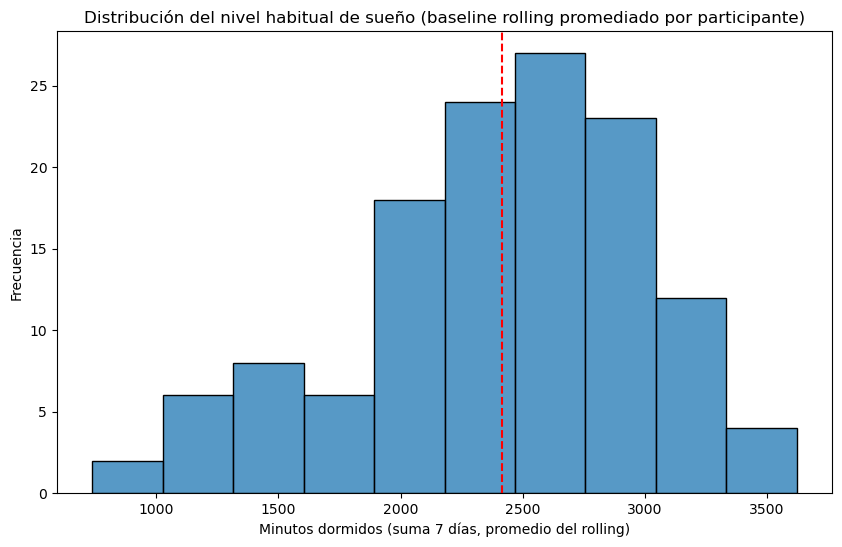

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_resumen, x="mean")
plt.axvline(baseline_sleep_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de sueño (baseline rolling promediado por participante)")
plt.xlabel("Minutos dormidos (suma 7 días, promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de sueño es unimodal y aproximadamente simétrica, con la mayoría de participantes entre 1500 y 3500 minutos en ventana de 7 días (equivalente a 3.6-8.3 horas/noche). El pico se sitúa entre 2500 y 2750 minutos (aproximadamente 6-6.5 horas/noche) y la media del grupo (línea roja) ronda los 2400 minutos. Existe una cola izquierda con un grupo reducido de participantes en torno a 1000-1250 minutos (menos de 3 horas/noche), que ya señala heterogeneidad en el nivel habitual y justifica la lógica intra-sujeto: lo que para un participante son 6 horas habituales, para otro son 3 horas habituales, y ambos son su normalidad reciente.


**Distribución de la variabilidad individual**

Visualizamos la distribución del promedio de la desviación típica del baseline rolling de cada participante (columna `std` de `baseline_sleep_resumen`). Esto permite caracterizar cuán regulares o irregulares son los patrones de sueño entre participantes.


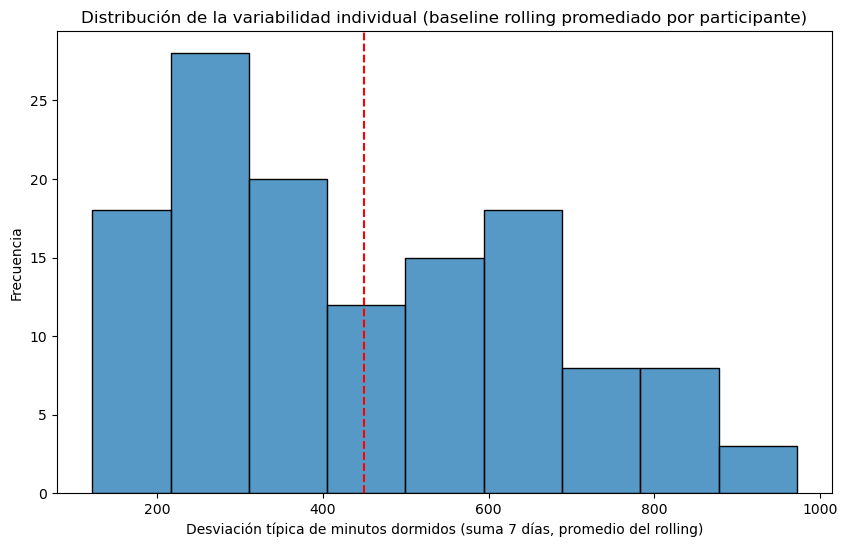

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_resumen, x="std")
plt.axvline(baseline_sleep_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de minutos dormidos (suma 7 días, promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está claramente sesgada a la derecha. La mayoría de participantes presenta std baja-moderada, con un pico marcado en torno a 300-400 minutos. La media del grupo (línea roja) se sitúa cerca de 500, arrastrada hacia arriba por una cola larga que llega hasta 1000 minutos. La asimetría refleja heterogeneidad real entre participantes: la mayoría tiene patrones de sueño relativamente regulares en su histórico reciente, y una minoría presenta std altas que el sistema debe interpretar como variabilidad propia, no como desviación. El z-score intra-sujeto del Bloque 3 normalizará la desviación de cada día por la std de la persona en sus 21 días previos, lo que ajusta automáticamente la sensibilidad a estas diferencias individuales.


**Relación entre nivel y variabilidad**

Visualizamos la relación entre las dos columnas de `baseline_sleep_resumen` mediante un scatter plot. Esto permite identificar si existe asociación entre el nivel habitual de sueño y la regularidad del patrón.


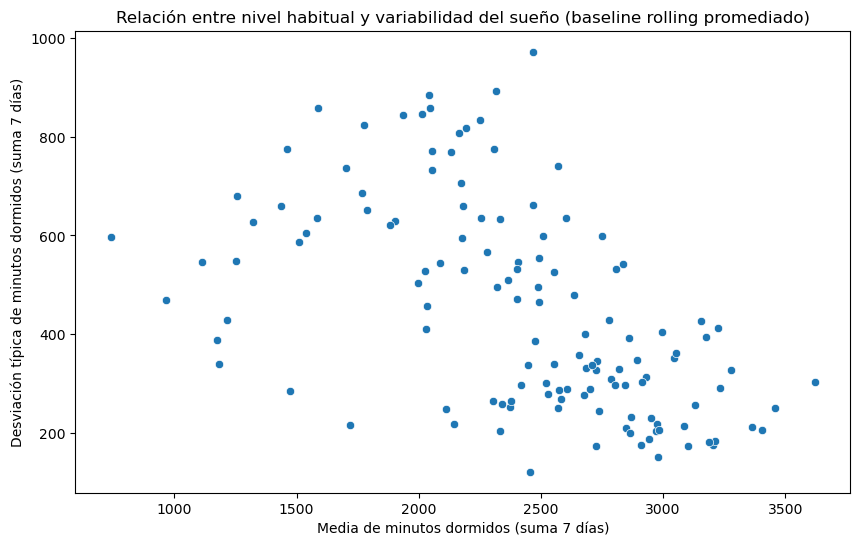

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_sleep_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad del sueño (baseline rolling promediado)")
plt.xlabel("Media de minutos dormidos (suma 7 días)")
plt.ylabel("Desviación típica de minutos dormidos (suma 7 días)")
plt.show()


El scatter muestra una correlación negativa visible entre el nivel habitual de sueño y la variabilidad individual: los participantes con `mean` alta (2500-3500 minutos) tienden a presentar `std` baja (200-500), mientras que los participantes con `mean` baja (menos de 2000 minutos) presentan `std` más dispersa y mayoritariamente alta (500-1000). Este patrón es consistente con la lectura conductual de que las personas con sueño habitualmente largo tienen rutinas más estables, mientras que sueño habitualmente corto suele coexistir con mayor irregularidad.

Esta asociación es informativa pero no condiciona el sistema: el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante en su histórico reciente. Las personas con std alta tendrán z-scores más conservadores; las personas con std baja, z-scores más sensibles. Esa es la lógica del enfoque intra-sujeto.


#### 1.6. Cierre del baseline rolling de sleep

Con esto queda construido el baseline rolling de sleep:

- Feature primaria: `f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 28, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual unimodal entre 1000 y 3500 minutos, distribución de variabilidad individual sesgada a la derecha y correlación negativa entre nivel y variabilidad.
- Algunos participantes quedan con baseline rolling no calculable (NaN en el resumen) por cobertura insuficiente. No son excluidos del proyecto: pueden volver a ser evaluables en días posteriores si su cobertura mejora.

Sobre esta referencia se calculará en el Bloque 3 el z-score intra-sujeto día a día. La misma lógica se aplica a continuación a steps, location y screen.


### `2. Steps`
#### 2.1. Identificación de la feature primaria


In [20]:
df_steps.columns[(df_steps.columns.str.contains("7dhist")) & ~(df_steps.columns.str.contains("norm")) & ~(df_steps.columns.str.contains("dis"))], df_steps.columns.shape


(Index(['f_steps:fitbit_steps_summary_rapids_maxsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_minsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_avgsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_mediansumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_stdsumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_minsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_avgsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_stdsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_countepisodesedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout:7dhist',
        'f_steps:fitbit_st

El dataset de steps contiene 597 columnas. Para encontrar la feature primaria, exploramos qué columnas tienen ventana 7dhist y versión raw. Seleccionamos `sumsteps` (suma intradiaria de pasos) como feature primaria por ser la medida más directa e interpretable de actividad física.


In [21]:
col_steps = 'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist'


#### 2.2. Preparación de la columna `day`


Aplicamos a `df_steps` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [22]:
# creamos una serie con la fecha inicial de cada participante
start_date = df_steps.groupby("pid")["date"].min()
start_date.head()

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
Name: date, dtype: object

In [23]:
start_date.dtype, df_steps["date"].dtype

(dtype('O'), dtype('O'))

`start_date` y `df_steps["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [24]:
df_steps["date"] = pd.to_datetime(df_steps["date"])
start_date = pd.to_datetime(start_date)
df_steps["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

``Materialización de start_date como columna:``
`start_date` es una Series de 155 elementos indexada por pid. Para que cada fila del DataFrame tenga acceso a la fecha de inicio de su participante, necesitamos una columna replicada al tamaño del DataFrame.

Asignamos a cada fila de `df_steps` la fecha de inicio de su participante creando la nueva columna `start_date`.


In [25]:
df_steps["start_date"] = df_steps["pid"].map(start_date)
df_steps["start_date"].head()


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
Name: start_date, dtype: datetime64[ns]

In [26]:
# comprobamos que el dataset tiene la nueva columna 'start_date'
df_steps.head(3)

,Unnamed: 0,pid,date,f_steps:fitbit_steps_summary_rapids_maxsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_minsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_avgsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_mediansumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_stdsumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_sumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_maxsteps:14dhist,...,f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_countepisodeactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_sumdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_maxdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_mindurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationactivebout_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,17287.0,17287.0,17287.0,17287.0,NaN,17287.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,17287.0,14958.0,16122.5,16122.5,1646.851693,32245.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,17287.0,14958.0,16245.0,16490.0,1183.671830,48735.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [27]:
df_steps["day"] = (df_steps["date"] - df_steps["start_date"]).dt.days
df_steps["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 2.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_steps` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 2.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_steps` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es la misma: la feature primaria es una suma deslizante de 7 días, y sin buffer la observación del día d compartiría datos crudos con los últimos valores del baseline, atenuando el z-score posterior.


In [28]:
baseline_steps = (
    df_steps.groupby("pid")[col_steps]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_steps.head(40)

mean           std
pid                                     
INS-W_001 0            NaN           NaN
          1            NaN           NaN
          2            NaN           NaN
          3            NaN           NaN
          4            NaN           NaN
          5            NaN           NaN
          6            NaN           NaN
          7            NaN           NaN
          8            NaN           NaN
          9            NaN           NaN
          10           NaN           NaN
          11           NaN           NaN
          12           NaN           NaN
          13           NaN           NaN
          14           NaN           NaN
          15           NaN           NaN
          16           NaN           NaN
          17           NaN           NaN
          18           NaN           NaN
          19           NaN           NaN
          20           NaN           NaN
          21           NaN           NaN
          22           NaN           NaN
          23           NaN           NaN
          24           NaN           NaN
          25           NaN           NaN
          26           NaN           NaN
          27           NaN           NaN
          28  99366.800000   7356.756780
          29  98122.062500   8677.769802
          30  96736.588235  10160.185536
          31  95621.888889  10932.659221
          32  94908.157895  11070.758582
          33  94161.200000  11281.400709
          34  93534.809524  11364.249534
          35  92835.380952  10885.048835
          36  92387.857143  10289.174657
          37  92599.000000  10587.447034
          38  92925.761905  10959.782101
          39  92959.095238  10983.205529

`baseline_steps` contiene, para cada participante y cada día del registro, su baseline rolling de steps en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de steps

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [29]:
baseline_steps_resumen = baseline_steps.groupby("pid").mean()
baseline_steps_resumen


,mean,std
pid,,
INS-W_001,81623.027268,15765.924066
INS-W_002,35445.410706,18459.262666
INS-W_003,51222.244751,17777.381599
INS-W_004,79796.247761,12108.853822
INS-W_005,89786.998704,12255.154353
...,...,...
INS-W_201,57741.695043,33090.784297
INS-W_202,43656.479361,19382.473565
INS-W_203,60432.518094,30341.483713


**Distribución del nivel habitual de steps**


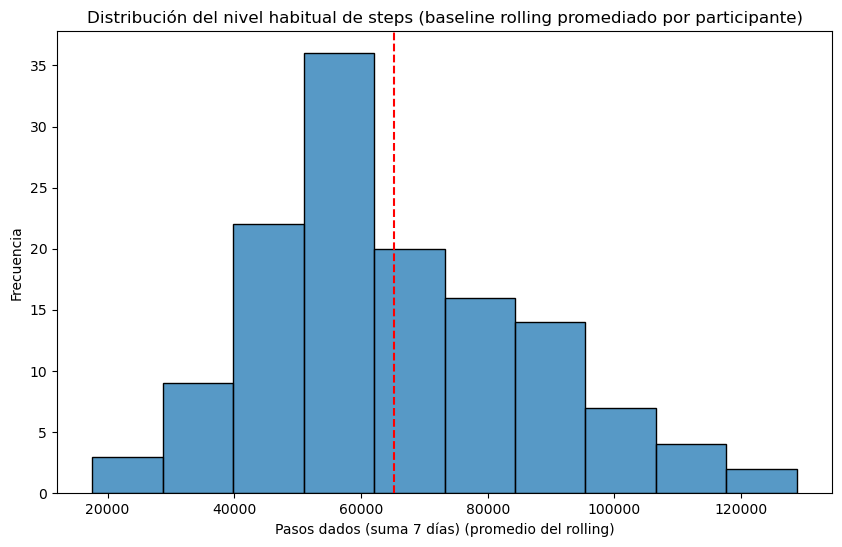

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_resumen, x="mean")
plt.axvline(baseline_steps_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de steps (baseline rolling promediado por participante)")
plt.xlabel("Pasos dados (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de actividad es unimodal con asimetría a la derecha. La mayoría de participantes se sitúa entre 30000 y 90000 pasos en suma de 7 días (equivalente a 4300-12900 pasos/día), con un pico marcado entre 50000 y 60000 pasos (7100-8600 pasos/día). La media del grupo (línea roja) ronda los 65000 pasos, arrastrada hacia arriba por una cola derecha que llega hasta 120000-130000 (más de 17000 pasos/día). Existe también un grupo reducido en la zona baja (15000-25000 pasos en 7 días, menos de 3600 pasos/día).

La heterogeneidad observada es esperable: hay participantes con vida muy activa y participantes mayoritariamente sedentarios, y ambos extremos son normalidad propia de cada persona. El enfoque intra-sujeto evita comparar entre ellos: lo relevante no es si uno camina más que otro, sino si cada uno se aleja de su propio nivel habitual reciente.


**Distribución de la variabilidad individual**


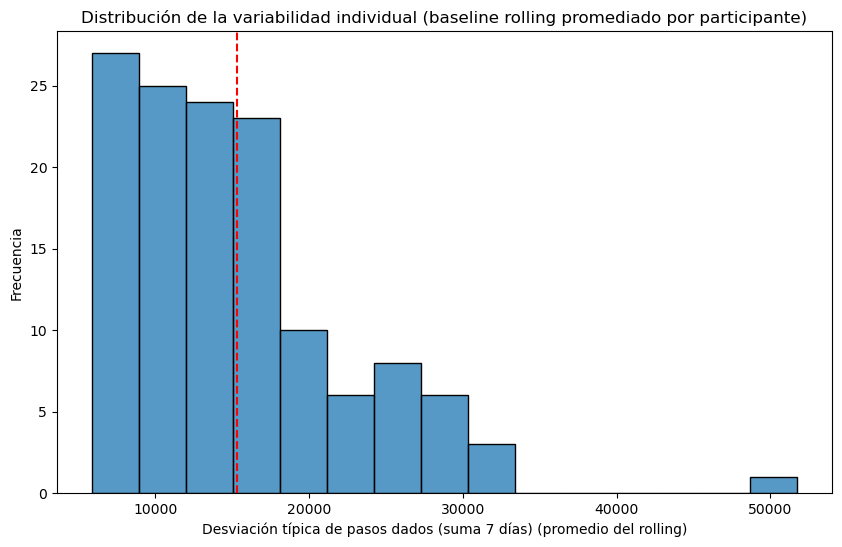

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_resumen, x="std")
plt.axvline(baseline_steps_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de pasos dados (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está claramente sesgada a la derecha. La mayoría de participantes se concentra en std de 8000-12000 pasos, con un pico marcado en esa zona. La media del grupo (línea roja) se sitúa cerca de 16000, arrastrada por una cola larga que llega hasta 30000, más algún caso aislado en torno a 50000.

La asimetría refleja que steps es una señal con mayor variabilidad estructural que sleep. La actividad física depende fuertemente del contexto diario (trabajo, tiempo libre, deporte ocasional, días festivos, clima), y un participante con std alta no es necesariamente irregular en sentido patológico, simplemente tiene una vida con mayor amplitud de actividad. El z-score intra-sujeto del Bloque 3 normaliza la desviación de cada día contra la std propia de la persona en sus 21 días previos, lo que ajusta automáticamente la sensibilidad al perfil de variabilidad de cada participante.


**Relación entre nivel y variabilidad**


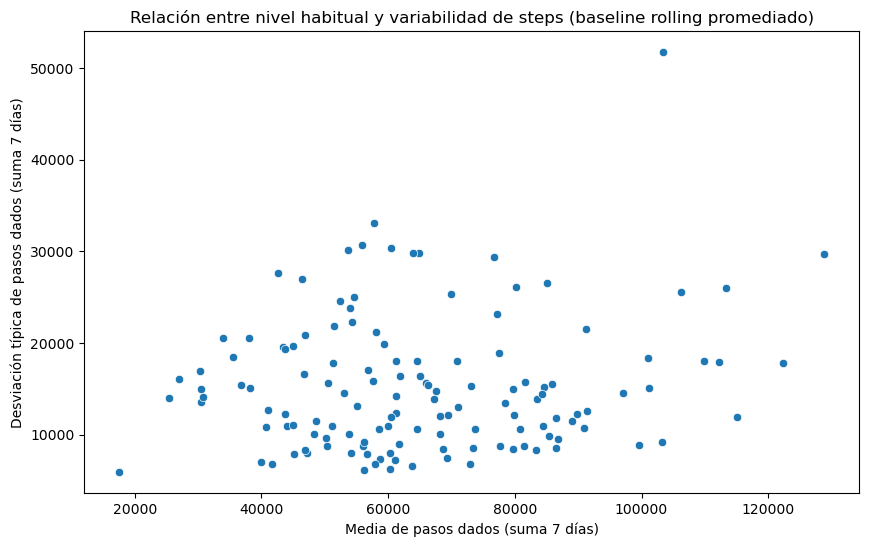

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_steps_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de steps (baseline rolling promediado)")
plt.xlabel("Media de pasos dados (suma 7 días)")
plt.ylabel("Desviación típica de pasos dados (suma 7 días)")
plt.show()


El scatter no muestra correlación lineal clara entre el nivel habitual de actividad y la variabilidad individual. La nube de puntos se concentra en valores moderados de ambas dimensiones (mean entre 40000 y 90000 pasos en 7 días, std entre 8000 y 20000), sin un patrón sistemático que asocie nivel y variabilidad.

La ausencia de correlación contrasta con sleep, donde sí se observaba asociación negativa entre mean alta y std baja. En steps, participantes con nivel habitual similar pueden tener perfiles de variabilidad muy distintos, y participantes con std alta aparecen tanto en niveles bajos como altos de actividad. Esto refuerza la lógica intra-sujeto: la combinación nivel-variabilidad es propia de cada persona y no se deja resumir por una tendencia poblacional.


#### 2.5. Cierre del baseline rolling de steps

Con esto queda construido el baseline rolling de steps:

- Feature primaria: `f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 28, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual unimodal con asimetría derecha entre 15000 y 130000 pasos, distribución de variabilidad sesgada a la derecha y ausencia de correlación lineal entre nivel y variabilidad.
- Como en sleep, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.


### `3. Location`
#### 3.1. Identificación de la feature primaria


In [33]:
df_location.columns[(df_location.columns.str.contains("7dhist")) & ~(df_location.columns.str.contains("norm")) & ~(df_location.columns.str.contains("dis"))], df_location.columns.shape


(Index(['f_loc:phone_locations_barnett_avgflightdur:7dhist',
        'f_loc:phone_locations_barnett_avgflightlen:7dhist',
        'f_loc:phone_locations_barnett_circdnrtn:7dhist',
        'f_loc:phone_locations_barnett_hometime:7dhist',
        'f_loc:phone_locations_barnett_maxdiam:7dhist',
        'f_loc:phone_locations_barnett_probpause:7dhist',
        'f_loc:phone_locations_barnett_rog:7dhist',
        'f_loc:phone_locations_barnett_siglocentropy:7dhist',
        'f_loc:phone_locations_barnett_siglocsvisited:7dhist',
        'f_loc:phone_locations_barnett_stdflightdur:7dhist',
        'f_loc:phone_locations_barnett_stdflightlen:7dhist',
        'f_loc:phone_locations_barnett_wkenddayrtn:7dhist',
        'f_loc:phone_locations_doryab_avglengthstayatclusters:7dhist',
        'f_loc:phone_locations_doryab_avgspeed:7dhist',
        'f_loc:phone_locations_doryab_homelabel:7dhist',
        'f_loc:phone_locations_doryab_locationentropy:7dhist',
        'f_loc:phone_locations_doryab_locat

El dataset de location contiene 1110 columnas. Para encontrar la feature primaria, filtramos las que tienen ventana 7dhist y versión raw. Seleccionamos `rog` (radius of gyration, radio de giro) como feature primaria. Mide la dispersión espacial del usuario alrededor de su centro de masas geográfico, sintetizando en un único valor lo amplio o restringido que es su espacio vital.


In [34]:
col_location = 'f_loc:phone_locations_barnett_rog:7dhist'


#### 3.2. Preparación de la columna `day`


Aplicamos a `df_location` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [35]:
start_date = df_location.groupby("pid")["date"].min()
start_date.dtype, df_location["date"].dtype


(dtype('O'), dtype('O'))

`start_date` y `df_location["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [36]:
df_location["date"] = pd.to_datetime(df_location["date"])
start_date = pd.to_datetime(start_date)
df_location["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

Asignamos a cada fila de `df_location` la fecha de inicio de su participante creando una nueva columna `start_date`.


In [37]:
df_location["start_date"] = df_location["pid"].map(start_date)
df_location["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [38]:
df_location["day"] = (df_location["date"] - df_location["start_date"]).dt.days
df_location["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 3.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_location` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 3.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_location` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es estructural: `rog:7dhist` es el radio de giro calculado sobre una ventana móvil de 7 días, por lo que los valores de días consecutivos comparten 6 días de datos crudos. Sin buffer, los últimos valores del baseline solaparían parcialmente con la observación del día d, atenuando el z-score posterior.


In [39]:
baseline_location = (
    df_location
    .groupby("pid")[col_location]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_location.head(40)


mean         std
pid                                  
INS-W_001 0           NaN         NaN
          1           NaN         NaN
          2           NaN         NaN
          3           NaN         NaN
          4           NaN         NaN
          5           NaN         NaN
          6           NaN         NaN
          7           NaN         NaN
          8           NaN         NaN
          9           NaN         NaN
          10          NaN         NaN
          11          NaN         NaN
          12          NaN         NaN
          13          NaN         NaN
          14          NaN         NaN
          15          NaN         NaN
          16          NaN         NaN
          17          NaN         NaN
          18          NaN         NaN
          19          NaN         NaN
          20          NaN         NaN
          21          NaN         NaN
          22          NaN         NaN
          23          NaN         NaN
          24          NaN         NaN
          25          NaN         NaN
          26          NaN         NaN
          27          NaN         NaN
          28          NaN         NaN
          29          NaN         NaN
          30          NaN         NaN
          31          NaN         NaN
          32          NaN         NaN
          33          NaN         NaN
          34          NaN         NaN
          35  1924.725008  608.033849
          36  1884.295420  609.270857
          37  1843.809146  613.086979
          38  1780.518287  652.586011
          39  1710.060899  704.648684

`baseline_location` contiene, para cada participante y cada día del registro, su baseline rolling de location en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de location

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [40]:
baseline_location_resumen = baseline_location.groupby("pid").mean()
baseline_location_resumen

,mean,std
pid,,
INS-W_001,1718.554503,570.365056
INS-W_002,16366.340236,13577.012790
INS-W_003,2808.076261,3757.370162
INS-W_004,2928.644068,1942.110924
INS-W_005,2690.507547,1912.366961
...,...,...
INS-W_201,2340.299649,880.308045
INS-W_202,27460.253991,36166.922234
INS-W_203,5210.717203,2892.848955


**Distribución del nivel habitual de location**


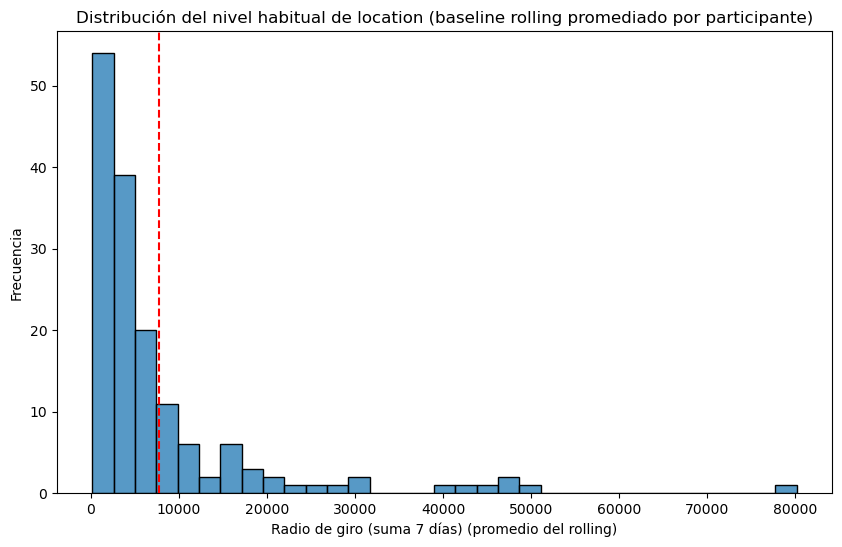

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_resumen, x="mean")
plt.axvline(baseline_location_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de location (baseline rolling promediado por participante)")
plt.xlabel("Radio de giro (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de movilidad espacial presenta asimetría a la derecha extrema. La mayoría de participantes se concentra en valores bajos: el pico más alto está en 0-2500 metros (más de 50 participantes), seguido de un escalón rápido que decae hacia los 10000-15000. La media del grupo (línea roja) ronda los 8000 metros, arrastrada hacia arriba por una cola muy larga con valores dispersos hasta 80000.

Esta forma de distribución refleja heterogeneidad estructural en estilos de vida: la mayoría de participantes opera en un radio espacial reducido (zona doméstica, trabajo o estudio cercanos), y una minoría tiene patrones de movilidad mucho más amplios (desplazamientos largos, varios contextos geográficos en la semana). Con baseline rolling, esta heterogeneidad no se trata como un problema, sino como información: cada participante se compara consigo mismo, y un radio bajo es la normalidad de unos y un radio alto la normalidad de otros.


**Distribución de la variabilidad individual**


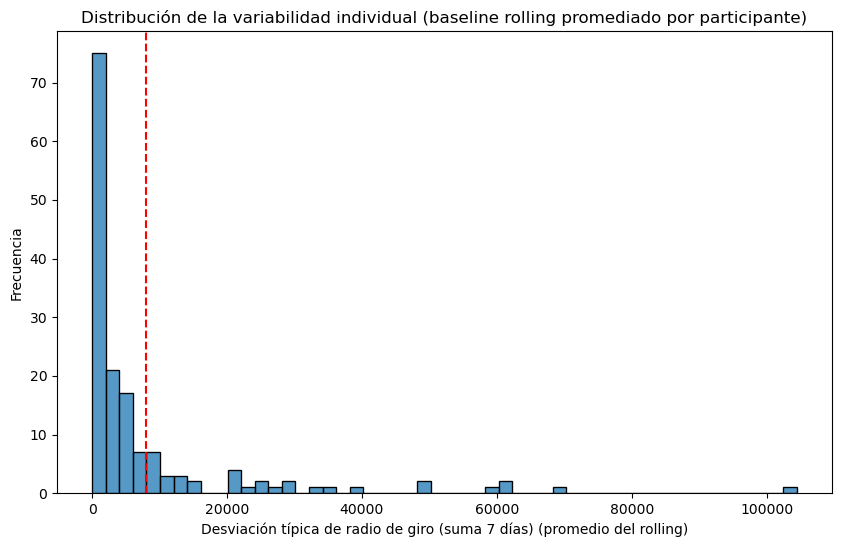

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_resumen, x="std")
plt.axvline(baseline_location_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de radio de giro (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está aún más sesgada a la derecha que la del nivel habitual. El pico es enorme en 0-5000 (cerca de 75 participantes concentrados ahí). La media del grupo (línea roja) se sitúa cerca de 9000, y la cola se extiende hasta más de 100000 con casos aislados.

La interpretación es coherente con el plot anterior: la mayoría de participantes tiene un patrón espacial muy estable semana a semana (rutinas geográficas similares), y una minoría con movilidad amplia presenta también mayor variabilidad espacial. Como en steps, una std alta no se interpreta automáticamente como irregularidad patológica, sino como amplitud de patrón propia. El z-score intra-sujeto del Bloque 3 normaliza contra la std propia de cada persona, lo que ajusta la sensibilidad a estos perfiles tan distintos.


**Relación entre nivel y variabilidad**


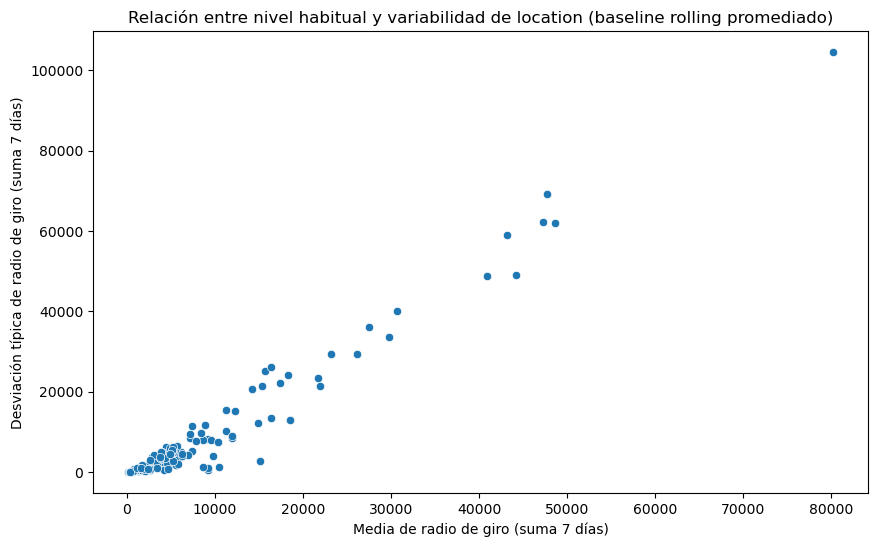

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_location_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de location (baseline rolling promediado)")
plt.xlabel("Media de radio de giro (suma 7 días)")
plt.ylabel("Desviación típica de radio de giro (suma 7 días)")
plt.show()


El scatter muestra una correlación lineal positiva muy clara entre el nivel habitual de movilidad y la variabilidad individual. La nube de puntos se alinea sobre un eje diagonal limpio: participantes con `mean` baja (0-10000) tienen `std` baja (0-5000), y a medida que aumenta `mean`, aumenta `std` proporcionalmente, hasta los participantes con mayor radio de giro (más de 50000) que presentan también la mayor variabilidad espacial (más de 50000).

Esta asociación es muy distinta a las observadas en sleep (correlación negativa) y steps (sin correlación clara). En location, la asociación positiva es esperable: una persona con un patrón espacial amplio tiene más oportunidades de variar geográficamente semana a semana, y el radio de giro está acotado por debajo en personas con vida más doméstica. La asociación es informativa pero no condiciona el sistema: el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante en su histórico reciente, así que la sensibilidad se ajusta automáticamente al perfil espacial de cada persona.


#### 3.5. Cierre del baseline rolling de location

Con esto queda construido el baseline rolling de location:

- Feature primaria: `f_loc:phone_locations_barnett_rog:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 28, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual con asimetría derecha extrema (concentración en 0-15000 metros y cola hasta 80000), distribución de variabilidad muy sesgada a la derecha y correlación lineal positiva clara entre nivel y variabilidad.
- Como en sleep y steps, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.


### `4. Screen`
#### 4.1. Identificación de la feature primaria


In [44]:
df_screen.columns[(df_screen.columns.str.contains("7dhist")) & ~(df_screen.columns.str.contains("norm")) & ~(df_screen.columns.str.contains("dis"))], df_screen.columns.shape

(Index(['f_screen:phone_screen_rapids_countepisodeunlock:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00unlock:7dhist',
        'f_screen:phone_screen_rapids_countepisodeunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00

El dataset de screen contiene 1137 columnas. Para encontrar la feature primaria, filtramos las que tienen ventana 7dhist y versión raw. Seleccionamos `sumdurationunlock` (suma de duración de uso desbloqueado) como feature primaria por ser la medida más directa de tiempo total de interacción con el dispositivo.


In [45]:
col_screen = 'f_screen:phone_screen_rapids_sumdurationunlock:7dhist'


#### 4.2. Preparación de la columna `day`


Aplicamos a `df_screen` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [46]:
start_date = df_screen.groupby("pid")["date"].min()
start_date.dtype, df_screen["date"].dtype


(dtype('O'), dtype('O'))

`start_date` y `df_screen["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [47]:
df_screen["date"] = pd.to_datetime(df_screen["date"])
start_date = pd.to_datetime(start_date)
df_screen["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

Asignamos a cada fila de `df_screen` la fecha de inicio de su participante creando una nueva columna `start_date`.


In [48]:
df_screen["start_date"] = df_screen["pid"].map(start_date)
df_screen["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [49]:
df_screen["day"] = (df_screen["date"] - df_screen["start_date"]).dt.days
df_screen["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 4.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_screen` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 4.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_screen` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es la misma: la feature primaria es una suma deslizante de 7 días, y sin buffer la observación del día d compartiría datos crudos con los últimos valores del baseline, atenuando el z-score posterior.


In [50]:
baseline_screen = (
    df_screen
    .groupby("pid")[col_screen]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_screen.head(80)

mean         std
pid                                 
INS-W_001 0          NaN         NaN
          1          NaN         NaN
          2          NaN         NaN
          3          NaN         NaN
          4          NaN         NaN
...                  ...         ...
          75  347.207426  175.509386
          76  340.592052  177.362305
          77  333.280322  179.098828
          78  325.156178  180.652809
          79  321.493326  185.522403

[80 rows x 2 columns]

`baseline_screen` contiene, para cada participante y cada día del registro, su baseline rolling de screen en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de screen

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [51]:
baseline_screen_resumen = baseline_screen.groupby("pid").mean()
baseline_screen_resumen

,mean,std
pid,,
INS-W_001,960.844599,377.668884
INS-W_002,1329.192759,323.338269
INS-W_003,3377.564831,415.883399
INS-W_004,1788.637988,383.208390
INS-W_005,2557.013354,438.930769
...,...,...
INS-W_201,2310.091396,353.543745
INS-W_202,1866.029210,482.316809
INS-W_203,1835.357276,186.438927


**Distribución del nivel habitual de screen**


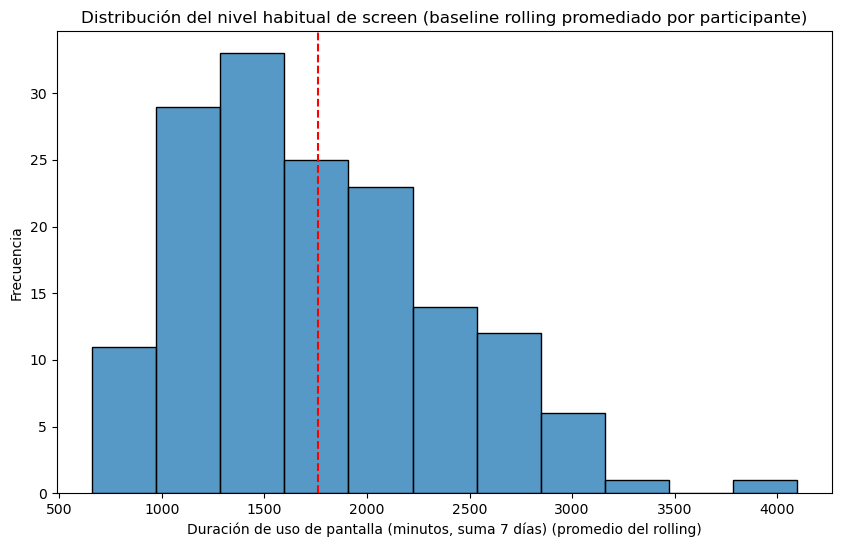

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_resumen, x="mean")
plt.axvline(baseline_screen_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de screen (baseline rolling promediado por participante)")
plt.xlabel("Duración de uso de pantalla (minutos, suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()

La distribución del nivel habitual de uso de pantalla presenta asimetría a la derecha. La mayoría de participantes se concentra entre 1000 y 2500 minutos en suma de 7 días, con un pico marcado en 1000-1500 (más de 30 participantes) y una segunda zona alta en 1500-2000 con altura similar. La media del grupo (línea roja) ronda los 1750 minutos. La cola decae progresivamente y se extiende hasta 3500-4000 minutos con casos aislados.

Esta forma intermedia (asimétrica pero sin la concentración extrema de location) es coherente con que el uso de pantalla está más uniformemente distribuido entre la cohorte que la movilidad espacial. Hay diferencias notables en uso habitual entre participantes, pero todos hacen algún uso del dispositivo, lo que reduce la cola izquierda. Como en las dimensiones anteriores, el sistema no compara entre participantes, sino que toma el nivel habitual reciente de cada uno como referencia propia.


**Distribución de la variabilidad individual**


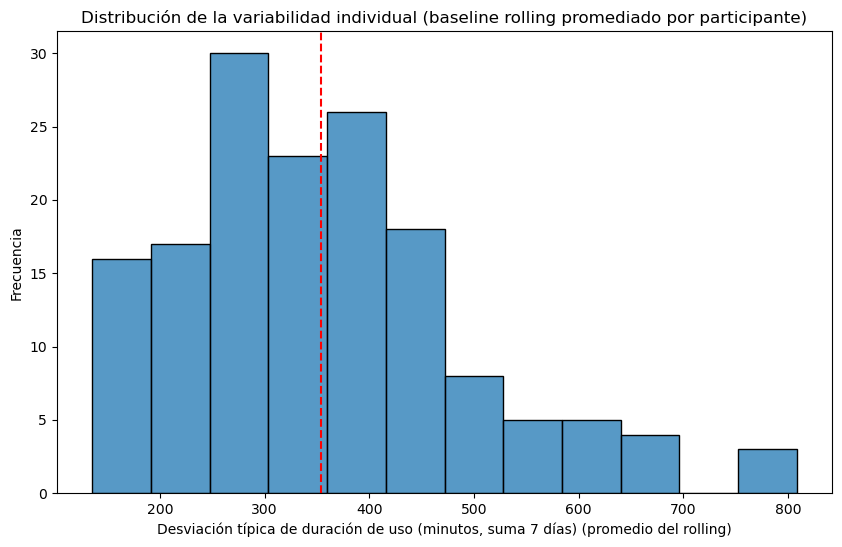

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_resumen, x="std")
plt.axvline(baseline_screen_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de duración de uso (minutos, suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual presenta asimetría a la derecha clara. El pico se sitúa en 250-300 minutos, con la mayoría de participantes concentrados entre 150 y 500. La media del grupo (línea roja) ronda los 350 minutos, y la cola se extiende hasta 800 con frecuencia decreciente.

La interpretación es coherente con que el uso de pantalla, aunque variable, lo es de forma menos extrema que steps o location. La mayoría de participantes mantiene un patrón de uso relativamente regular semana a semana, con una minoría más variable. El z-score intra-sujeto del Bloque 3 normaliza contra la std propia de cada persona, lo que ajusta automáticamente la sensibilidad al perfil de regularidad de cada participante.


**Relación entre nivel y variabilidad**


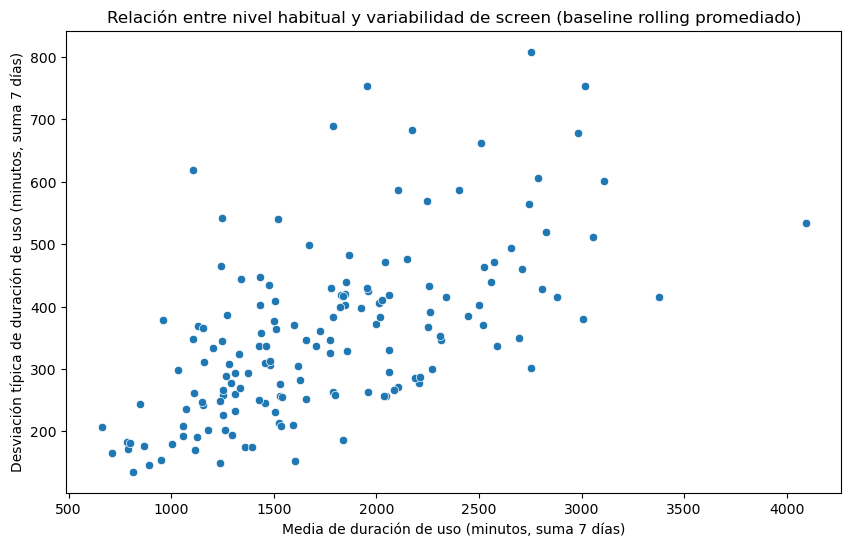

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_screen_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de screen (baseline rolling promediado)")
plt.xlabel("Media de duración de uso (minutos, suma 7 días)")
plt.ylabel("Desviación típica de duración de uso (minutos, suma 7 días)")
plt.show()


El scatter muestra correlación positiva moderada entre el nivel habitual de uso y la variabilidad individual. La tendencia es visible (mean alta tiende a std alta) pero con dispersión amplia: para un mismo nivel medio de uso, los participantes presentan std muy distintas. El patrón es más limpio que en sleep o steps, pero menos marcado que en location.

Esta posición intermedia tiene una lectura conductual razonable: un participante que usa más el móvil en términos absolutos tiene también más oportunidades de variar semana a semana, pero el techo de variabilidad está más acotado que en movilidad espacial. La asociación es informativa pero no condiciona el sistema, porque el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante.


#### 4.5. Cierre del baseline rolling de screen

Con esto queda construido el baseline rolling de screen:

- Feature primaria: `f_screen:phone_screen_rapids_sumdurationunlock:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 28, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual con asimetría derecha entre 500 y 4000 minutos, distribución de variabilidad sesgada a la derecha y correlación positiva moderada entre nivel y variabilidad.
- Como en sleep, steps y location, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.

### **Cierre del Bloque 2**

Con sleep, steps, location y screen, el Bloque 2 queda completado. El sistema dispone ahora de cuatro baselines rolling individuales, uno por dimensión, calculados sobre los 21 días que terminan 7 días antes de cada día de evaluación. Cada baseline contiene, para cada par persona-día, la media y la desviación típica que servirán de referencia individual en el cálculo del z-score intra-sujeto del Bloque 3.

Los participantes con baseline no calculable en una dimensión un día concreto se omiten de esa dimensión ese día, sin ser excluidos del proyecto. La regla de convergencia 2/3 entre dimensiones se aplicará en el Bloque 3 sobre los días en que el participante tenga al menos dos dimensiones evaluables.


## Bloque 3: Z-score intra-sujeto

### 3.1. Qué calcula este bloque y por qué es la segunda pieza técnica del sistema

El Bloque 2 produjo cuatro baselines, uno por dimensión, que contienen para cada par persona-día la media y la desviación típica del comportamiento habitual reciente de esa persona. El Bloque 3 usa esos baselines para responder a una pregunta concreta: para cada día evaluable, **¿cuánto se aleja la observación de hoy del patrón habitual reciente de esta persona?**

La medida es el z-score intra-sujeto: `z = (observación − mean) / std`. Es la fórmula convencional del z-score, pero su semántica aquí es la del marco N-of-1. La media y la desviación típica no provienen de la población; provienen del propio historial reciente de la persona. El resultado no compara a la persona con un grupo de referencia, la compara consigo misma a lo largo del tiempo.

El output del bloque son cuatro `Series`, una por dimensión (`z_sleep`, `z_steps`, `z_location`, `z_screen`), indexadas por `(pid, idx)` igual que los baselines. Cada Series tiene valor numérico en los pares persona-día evaluables y `NaN` en los no evaluables. Los pares con NaN en mean o std (por baseline no calculable) quedan automáticamente excluidos por aritmética: cualquier operación con NaN produce NaN. No se aplica imputación.

La decisión de mantener el z-score como Series separada por dimensión, y no como columna añadida al DataFrame de cada dimensión, responde a tres razones: el z-score no es una propiedad de la observación cruda sino una relación con un baseline concreto; su dominio natural son los pares evaluables, no todos los pares; y los bloques posteriores operan sobre las cuatro dimensiones simultáneamente, lo que se resuelve trivialmente con cuatro Series del mismo índice.

#### 3.2. Construcción del z-score para sleep

Aplicamos la fórmula del z-score sobre la dimensión sleep como dimensión piloto. La operación combina dos objetos ya construidos: la columna `col_sleep` de `df_sleep`, que contiene la observación cruda 7dhist de cada par persona-día, y el DataFrame `baseline_sleep`, que contiene la media y la desviación típica del baseline rolling de esa misma persona para ese mismo día.

In [55]:
z_sleep = pd.Series(
    (df_sleep[col_sleep].values - baseline_sleep["mean"].values) / baseline_sleep["std"].values,
    index=baseline_sleep.index
)
z_sleep.dropna().head()

pid          
INS-W_001  28   -0.588216
           29   -0.478832
           30    0.416003
           31    0.664682
           32    1.654369
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 28, que coincide con la primera posición donde el baseline rolling cumple la regla de cobertura tras la limpieza de los días 0-6 (al menos 15 valores no-NaN en la ventana [d-28, d-8]). Los valores iniciales oscilan entre −0.59 y +1.65, mostrando una tendencia ascendente desde valores ligeramente por debajo del patrón habitual hacia valores moderadamente por encima, sin desviaciones grandes en el tramo inicial.


#### 3.3. Construcción del z-score para steps

Replicamos la fórmula del z-score sobre la dimensión steps. La operación es estructuralmente idéntica a la de sleep: combina la columna `col_steps` de `df_steps` con la media y la desviación típica del baseline rolling correspondiente, almacenadas en `baseline_steps`.

In [56]:
z_steps = pd.Series(
    (df_steps[col_steps].values - baseline_steps["mean"].values) / baseline_steps["std"].values,
    index=baseline_steps.index
)
z_steps.dropna().head()

pid          
INS-W_001  28   -0.851843
           29    0.370595
           30    1.182795
           31    1.121695
           32    0.517294
dtype: float64

La estructura del resultado replica la observada en sleep. INS-W_001 empieza a tener z-scores numéricos en el registro 28 (mismo punto de arranque que en sleep, lo que es coherente: ambas dimensiones tienen cobertura inicial completa en este participante tras la limpieza). Los valores iniciales oscilan entre −0.85 y +1.18, con un giro claro: parten de un día por debajo del patrón habitual y suben rápidamente a varios días por encima, sin estabilizarse aún en torno al centro.


#### 3.4. Construcción del z-score para location

Replicamos la fórmula del z-score sobre la dimensión location. Misma operación que en sleep y steps, aplicada ahora a la observación 7dhist de location y a su baseline rolling correspondiente.

In [57]:
z_location = pd.Series(
    (df_location[col_location].values - baseline_location["mean"].values) / baseline_location["std"].values,
    index=baseline_location.index
)
z_location.dropna().head()

pid          
INS-W_001  35   -1.258978
           36   -1.226573
           37   -1.128970
           38   -0.136753
           39    0.278221
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 35, más tarde que sleep y steps. Esto refleja una cobertura inicial menor en la dimensión location para este participante: el baseline rolling necesita más días para acumular los 15 valores mínimos exigidos. Los valores iniciales son moderadamente negativos (entre -1.0 y -1.3), seguidos de un acercamiento al centro (-0.14, +0.28) en los días posteriores, lo que sugiere una semana inicial de movilidad reducida y recuperación gradual hacia el patrón habitual.

#### 3.5. Construcción del z-score para screen

Replicamos la fórmula del z-score sobre la dimensión screen, completando así las cuatro Series del Bloque 3. La operación es idéntica a las tres anteriores: combina la observación 7dhist con la media y la desviación típica del baseline rolling de la dimensión.

In [58]:
z_screen = pd.Series(
    (df_screen[col_screen].values - baseline_screen["mean"].values) / baseline_screen["std"].values,
    index=baseline_screen.index
)
z_screen.dropna().head()

pid          
INS-W_001  41   -0.715838
           42   -1.197431
           43   -1.273110
           44   -1.690295
           45   -1.451637
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 41, el arranque más tardío de las cuatro dimensiones para este participante. La cobertura inicial de screen es menor, lo que retrasa el primer día evaluable. Los valores iniciales muestran una desviación consistentemente negativa entre -0.7 y -1.7, lo que indica un periodo de uso de pantalla notablemente por debajo del patrón personal reciente. Con esto quedan calculadas las cuatro Series del Bloque 3 (`z_sleep`, `z_steps`, `z_location`, `z_screen`), una por dimensión, indexadas por `(pid, idx)`.

### 3.6. Diagnóstico empírico de normalidad y justificación de la decisión de no transformar

La fórmula del z-score asume implícitamente que la distribución intra-sujeto de cada feature es aproximadamente normal. Bajo ese supuesto, los umbrales clásicos tipo `|z| > 3` corresponden al percentil 99.73% y la tasa de falsas alarmas es predecible. Si la distribución no es normal, esos umbrales producen una tasa de falsas alarmas distinta de la teórica.

Antes de continuar al paso de inspección visual, conviene verificar empíricamente si las features primarias se comportan como aproximadamente normales dentro de cada participante o no, y decidir si hay que transformar las variables antes del cálculo del z-score. Esta verificación tiene dos partes: medir la asimetría intra-sujeto en cada dimensión, y probar si la transformación logarítmica reduce esa asimetría.

In [59]:
from scipy import stats
import numpy as np

dimensiones = {
    "sleep":    (df_sleep,    col_sleep),
    "steps":    (df_steps,    col_steps),
    "location": (df_location, col_location),
    "screen":   (df_screen,   col_screen),
}

print("="*75)
print("ASIMETRÍA INTRA-SUJETO POR DIMENSIÓN")
print("Para cada participante con al menos 20 valores no nulos en la dimensión,")
print("calculamos la skewness de su serie temporal. Después miramos la")
print("distribución de esas skewness entre participantes.")
print("="*75)
for nombre, (df, col) in dimensiones.items():
    skew_por_persona = df.groupby("pid")[col].apply(
        lambda s: stats.skew(s.dropna()) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    print(f"\n  {nombre}:")
    print(f"    participantes evaluados:    {len(skew_por_persona)}")
    print(f"    skewness mediana:           {skew_por_persona.median():+.3f}")
    n_simetrico    = (skew_por_persona.abs() < 0.5).sum()
    n_asim_moderado = ((skew_por_persona.abs() >= 0.5) & (skew_por_persona.abs() < 1.0)).sum()
    n_asim_fuerte  = (skew_por_persona.abs() >= 1.0).sum()
    total = len(skew_por_persona)
    print(f"    simétricos    |skew| < 0.5:        {n_simetrico:>3}/{total}  ({100*n_simetrico/total:.0f}%)")
    print(f"    asim moderada 0.5 <= |skew| < 1.0: {n_asim_moderado:>3}/{total}  ({100*n_asim_moderado/total:.0f}%)")
    print(f"    asim fuerte   |skew| >= 1.0:       {n_asim_fuerte:>3}/{total}  ({100*n_asim_fuerte/total:.0f}%)")

print()
print("="*75)
print("EFECTO DE LA TRANSFORMACIÓN LOGARÍTMICA")
print("Comparamos la asimetría mediana antes y después de aplicar log(x+1) por")
print("participante. Si log reduce |skew| sistemáticamente, la transformación")
print("tiene sentido. Si no, la transformación no aporta.")
print("="*75)
for nombre, (df, col) in dimensiones.items():
    if (df[col].dropna() < 0).any():
        print(f"\n  {nombre}: contiene valores negativos, log no aplica")
        continue
    skew_original = df.groupby("pid")[col].apply(
        lambda s: stats.skew(s.dropna()) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    skew_logged = df.groupby("pid")[col].apply(
        lambda s: stats.skew(np.log1p(s.dropna())) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    print(f"\n  {nombre}:")
    print(f"    |skew| mediana SIN transformar:  {skew_original.abs().median():.3f}")
    print(f"    |skew| mediana CON log(x+1):     {skew_logged.abs().median():.3f}")
    mejora = skew_original.abs().median() - skew_logged.abs().median()
    veredicto = "(log ayuda)" if mejora > 0.2 else "(log no aporta)" if mejora < 0.05 else "(efecto pequeño)"
    print(f"    mejora absoluta:                 {mejora:+.3f}  {veredicto}")

ASIMETRÍA INTRA-SUJETO POR DIMENSIÓN
Para cada participante con al menos 20 valores no nulos en la dimensión,
calculamos la skewness de su serie temporal. Después miramos la
distribución de esas skewness entre participantes.

  sleep:
    participantes evaluados:    130
    skewness mediana:           -1.430
    simétricos    |skew| < 0.5:         32/130  (25%)
    asim moderada 0.5 <= |skew| < 1.0:  23/130  (18%)
    asim fuerte   |skew| >= 1.0:        75/130  (58%)

  steps:
    participantes evaluados:    133
    skewness mediana:           -0.765
    simétricos    |skew| < 0.5:         46/133  (35%)
    asim moderada 0.5 <= |skew| < 1.0:  31/133  (23%)
    asim fuerte   |skew| >= 1.0:        56/133  (42%)

  location:
    participantes evaluados:    155
    skewness mediana:           +1.809
    simétricos    |skew| < 0.5:         28/155  (18%)
    asim moderada 0.5 <= |skew| < 1.0:  23/155  (15%)
    asim fuerte   |skew| >= 1.0:       104/155  (67%)

  screen:
    participantes ev

El diagnóstico muestra dos resultados claros.

**Asimetría intra-sujeto.** Las cuatro dimensiones presentan asimetría fuerte en una proporción significativa de participantes: 58% en sleep, 42% en steps, 67% en location y 49% en screen tienen |skew| >= 1 dentro de su propia serie temporal. La mediana de la skewness es negativa en sleep, steps y screen (cola izquierda), y positiva en location (cola derecha). Es decir, la no-normalidad no es un caso aislado, es el comportamiento típico de cada participante en este dominio.

**Transformación logarítmica.** La prueba muestra que la transformación logarítmica solo reduce la asimetría en location, donde la cola es a la derecha. En sleep, steps y screen la empeora, porque la cola está a la izquierda y la transformación logarítmica solo corrige asimetrías hacia la derecha. Una transformación uniforme no funciona para todas las dimensiones, y aplicar transformaciones distintas por dimensión rompería la coherencia del sistema.

**Decisión adoptada.** No transformar las variables. Mantener el z-score directo sobre la observación cruda. La justificación es metodológica: la asimetría intra-sujeto es señal informativa en este dominio. Los días que se alejan drásticamente del patrón personal son justamente lo que el sistema quiere detectar; aplastarlos con una transformación destruiría parte de la información que define el deterioro conductual. Una persona que durante una semana entera duerme dos horas por noche, cuando habitualmente duerme siete, es exactamente el tipo de caso que tiene que producir un z-score grande, no un valor moderado por efecto de una transformación correctora.

**Consecuencia estadística y mitigación estructural.** Aplicar umbrales tipo `|z| > 3` a distribuciones no normales produce una tasa de falsas alarmas superior a la predicha por la teoría 3σ (Montgomery 6.4, Borror et al. 1999). Esta consecuencia no se aborda en el cálculo del z-score sino en las reglas operativas posteriores: la regla de persistencia 7 días filtra desviaciones puntuales que no representan deterioro real, y la regla de convergencia 2/3 entre dimensiones reduce la probabilidad de que una asimetría dimensional individual produzca alertas espurias. La viabilidad efectiva de esta mitigación se evaluará empíricamente en el Bloque 7.

**Plan de contingencia para el Bloque 7.** Si la tasa de falsas alarmas del sistema completo (z-score + persistencia 7d + convergencia 2/3) resulta inaceptable cuando se mida sobre la cohorte INS-W_1, se aplicará el siguiente plan en orden de menor a mayor coste:

1. Subir el umbral de z-score (de 2.5 a 3, por ejemplo). Reversible, no toca arquitectura.
2. Endurecer la regla de persistencia (de 7 a 10 días, por ejemplo). También reversible.
3. Aplicar transformaciones específicas por dimensión (log para location; reflexión + log o raíz cuadrada de variable reflejada para sleep, steps y screen). Cambio estructural.
4. Sustituir el z-score con umbral fijo por umbrales empíricos por percentil intra-sujeto. Cambio profundo, más robusto a no-normalidad pero más alejado del marco SPC clásico.

Las opciones 1 y 2 son baratas y reversibles. Las opciones 3 y 4 solo se considerarían si las dos primeras resultan insuficientes.


### 3.7. Inspección visual conjunta de las cuatro distribuciones

Con las cuatro Series del z-score calculadas, antes de cerrar el bloque conviene inspeccionar visualmente la forma de sus distribuciones. La pregunta no es si el z-score se distribuye como una normal estándar (ya sabemos que no, por el diagnóstico de normalidad de las features primarias realizado antes), sino dejar documentadas las propiedades reales de cada distribución: dónde está el centro, qué simetría tiene, dónde están las colas, qué proporción de valores cae fuera de los rangos habituales del z-score teórico.

Se usan dos herramientas complementarias por dimensión:

- **Histograma:** muestra la forma global de la distribución y permite ver visualmente el centro, la dispersión y la asimetría.
- **QQ-plot (gráfico de probabilidad normal):** compara la distribución empírica con la distribución normal teórica que tendría la misma media y desviación típica. Si los puntos caen sobre la línea diagonal, los datos son aproximadamente normales. Si se desvían, la forma de la desviación informa del tipo de no-normalidad: colas pesadas, asimetría, o ambas.

El objetivo de esta inspección no es validar el z-score (la decisión de mantenerlo está tomada y documentada), sino dejar registro visual de las propiedades observadas para que un revisor del notebook pueda entender de un vistazo qué tipo de objeto está sobre la mesa al entrar al Bloque 4.

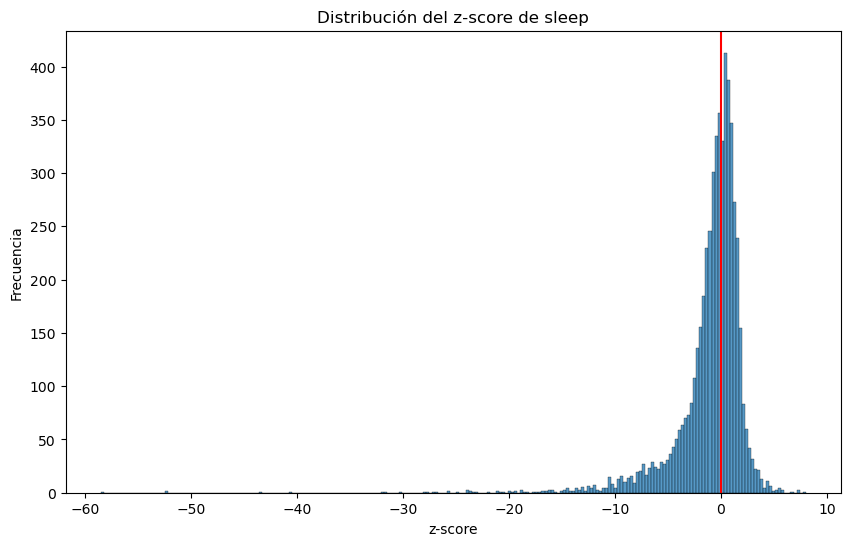

In [60]:
# Histograma z-score sleep

plt.figure(figsize=(10, 6))
sns.histplot(z_sleep.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribución del z-score de sleep")
plt.xlabel("z-score")
plt.ylabel("Frecuencia")
plt.show()

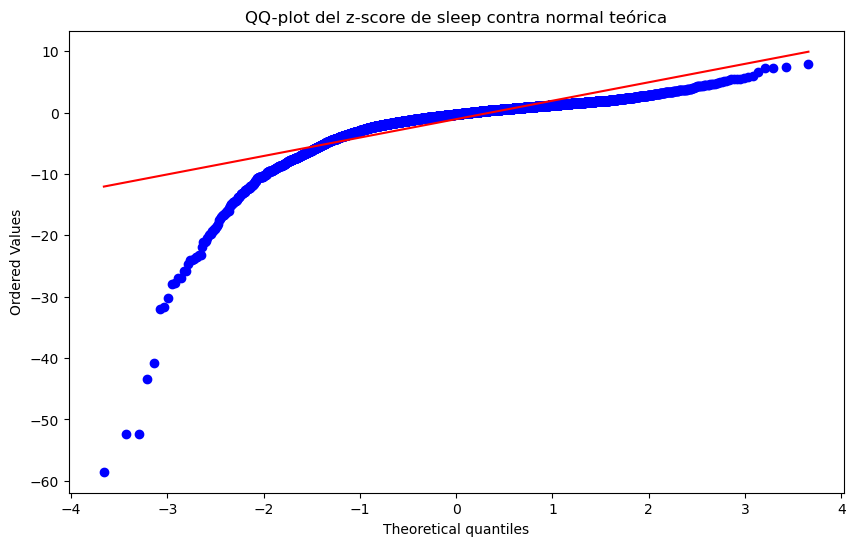

In [61]:
# QQ-plot del z-score de sleep

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_sleep.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot del z-score de sleep contra normal teórica")
plt.show()

La distribución de `z_sleep` presenta un pico estrecho en torno a 0 y una cola izquierda muy pesada que se extiende hasta valores cercanos a -60. La cola derecha es corta y se queda alrededor de +8. En el QQ-plot, la parte central de los datos (entre los cuantiles teóricos -2 y +2) sigue razonablemente la diagonal: en ese rango los z-scores se comportan como una normal. 

A partir de ahí, los puntos del lado izquierdo se hunden muy por debajo de la línea, lo que indica observaciones reales mucho más extremas en la cola negativa de lo que predice la normal teórica. La cola derecha, en cambio, queda ligeramente por debajo de la diagonal: las observaciones reales en esa cola son menos extremas que la normal. 

La distribución es asimétrica negativa con cola izquierda pesada, coherente con lo esperado: corresponden a casos de personas que durante una semana entera redujeron drásticamente su sueño respecto a su patrón habitual.

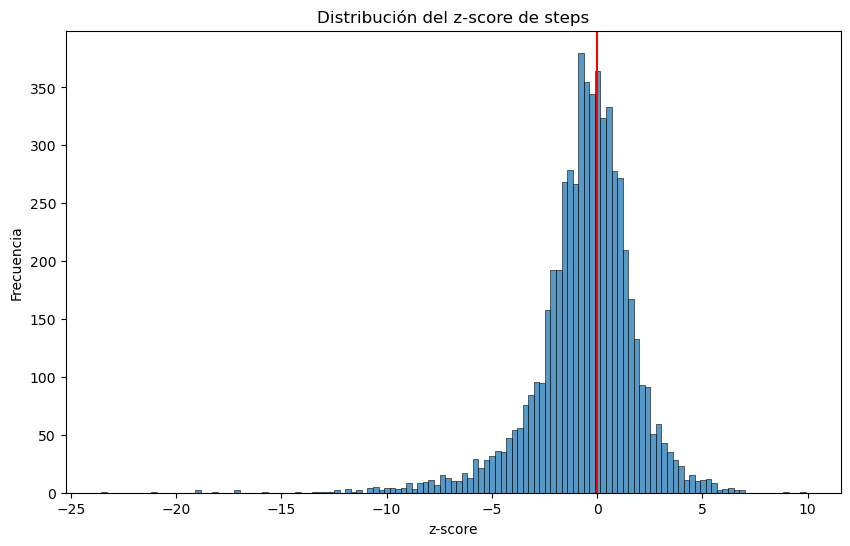

In [62]:
# Histograma z-score steps

plt.figure(figsize=(10,6))
sns.histplot(z_steps.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribución del z-score de steps")
plt.xlabel("z-score")
plt.ylabel("Frecuencia")
plt.show()

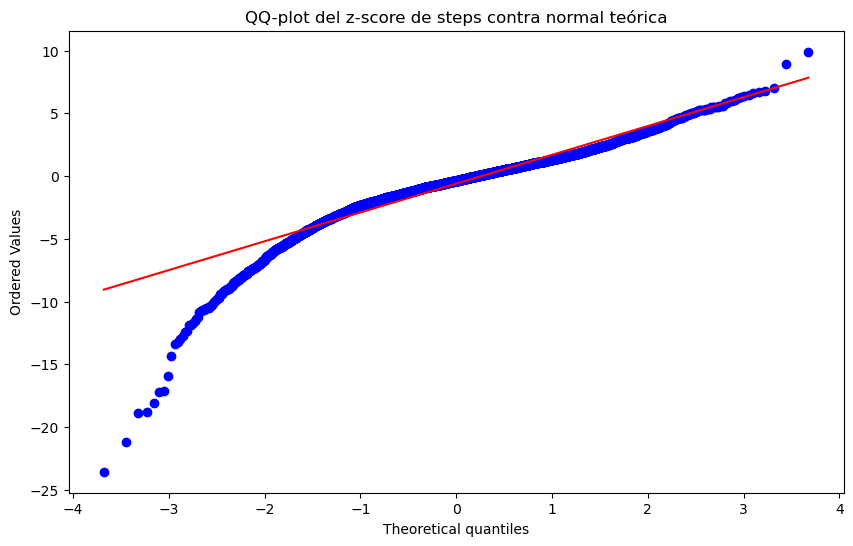

In [63]:
# QQ-plot del z-score de steps

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_steps.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot del z-score de steps contra normal teórica")
plt.show()

La distribución de `z_steps` muestra un pico estrecho centrado ligeramente a la izquierda de 0 y una cola izquierda larga que se extiende hasta -23 aproximadamente. La cola derecha es más corta y simétrica de lo habitual, quedándose en torno a +10. En el QQ-plot, la parte central (entre los cuantiles teóricos -2 y +2) sigue la diagonal con bastante fidelidad. 

Los puntos del lado izquierdo se separan claramente hacia abajo a partir del cuantil -2, indicando una cola izquierda significativamente más pesada que la normal teórica. La cola derecha se mantiene cerca de la diagonal con desviación leve. La distribución es asimétrica negativa pero menos extrema que la de sleep, lo que es coherente con que las caídas drásticas de actividad física a lo largo de una semana sean menos frecuentes en magnitud que las privaciones de sueño extremas.

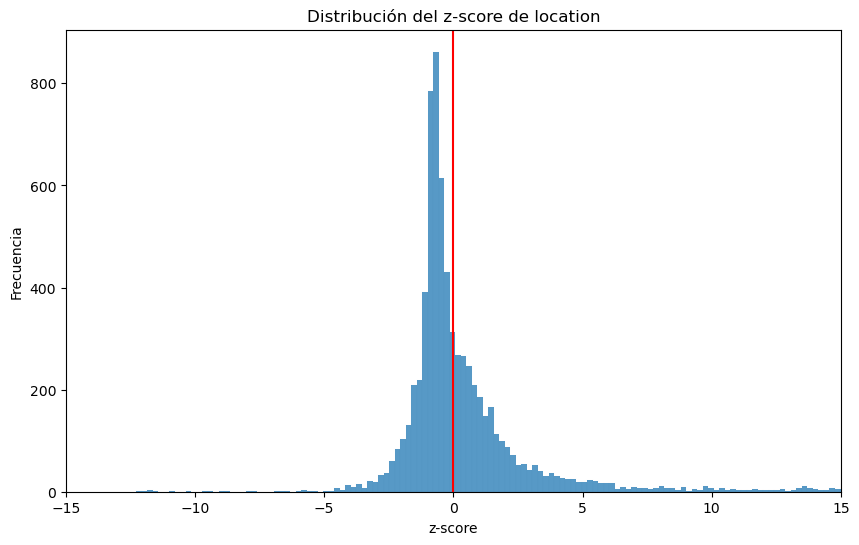

In [64]:
# Histograma z-score location

plt.figure(figsize=(10,6))
sns.histplot(z_location.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribución del z-score de location")
plt.xlabel("z-score")
plt.ylabel("Frecuencia")
plt.xlim(-15, 15)
plt.show()

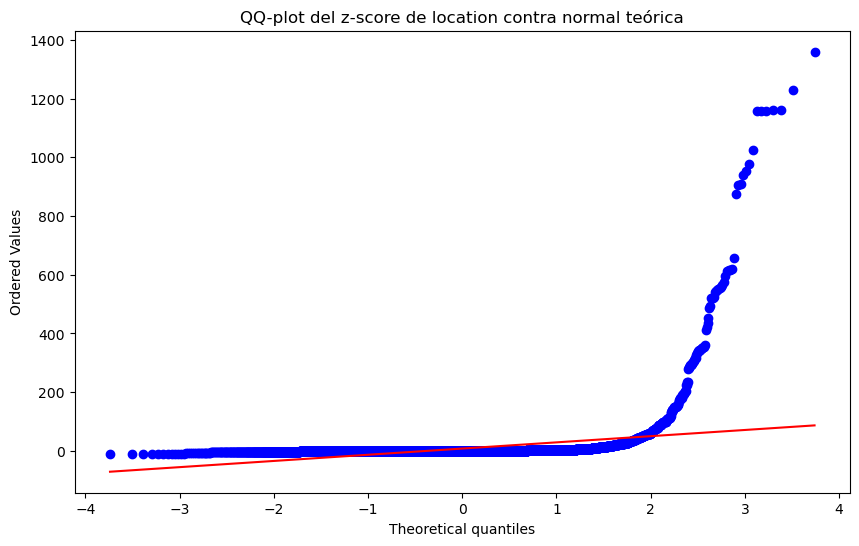

In [65]:
# QQ-plot del z-score de location

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_location.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot del z-score de location contra normal teórica")
plt.show()

La distribución de `z_location` presenta un pico estrecho centrado ligeramente a la izquierda de 0 y una asimetría visible hacia la derecha: la cola derecha es notablemente más larga que la izquierda. El histograma se ha recortado al rango [-15, +15] mediante `plt.xlim` para hacer visible la forma central de la distribución, ya que los valores extremos llegan hasta z=+1360 y harían ilegible el gráfico con escala automática. 

En el QQ-plot (que sí muestra todo el rango sin recorte) se aprecia con claridad esta naturaleza: la parte central de los datos sigue la diagonal hasta el cuantil teórico +2, pero a partir de ahí los puntos se disparan verticalmente alcanzando valores reales superiores a 1000. La cola izquierda apenas se desvía de la diagonal. 

La distribución es por tanto asimétrica positiva con cola derecha extremadamente pesada, coherente con la naturaleza de la dimensión: días aislados de movilidad muy elevada (viajes, mudanzas) sobre un patrón habitual de movilidad reducida producen z-scores muy grandes en el lado positivo.

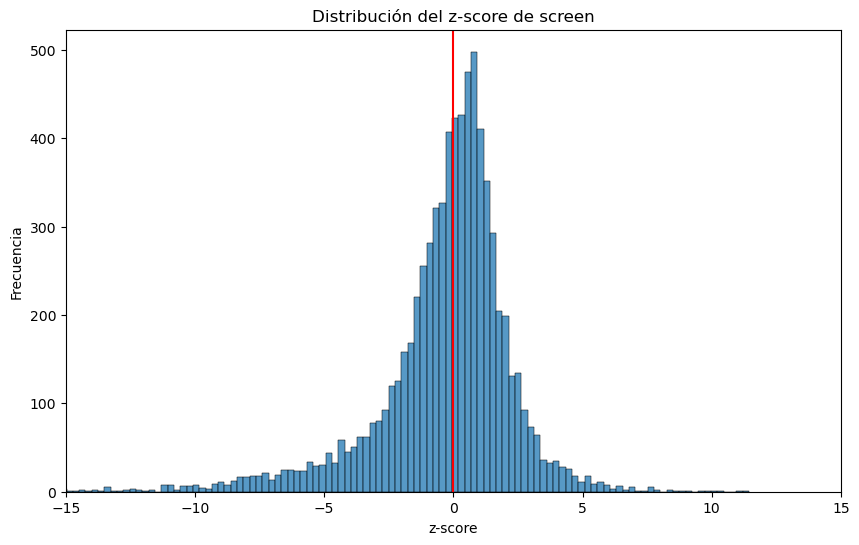

In [66]:
# Histograma z-score screen

plt.figure(figsize=(10,6))
sns.histplot(z_screen.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribución del z-score de screen")
plt.xlabel("z-score")
plt.ylabel("Frecuencia")
plt.xlim(-15, 15)
plt.show()

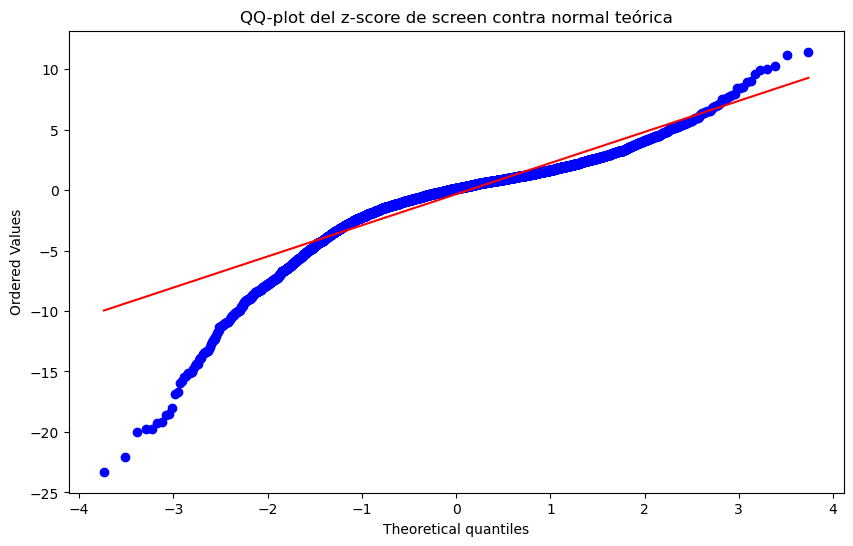

In [67]:
# QQ-plot del z-score de location

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_screen.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot del z-score de screen contra normal teórica")
plt.show()

La distribución de `z_screen` muestra un pico estrecho centrado ligeramente a la derecha de 0 y dos colas asimétricas: la izquierda se extiende hasta valores cercanos a -23, claramente más pesada que la derecha, que se queda en torno a +11. En el QQ-plot, la parte central sigue la diagonal con buena fidelidad entre los cuantiles teóricos -2 y +2. 

A partir del cuantil -2 los puntos del lado izquierdo se separan hacia abajo de forma marcada, llegando hasta valores reales próximos a -23. La cola derecha se desvía ligeramente por encima de la diagonal pero con magnitudes mucho más contenidas. 

La distribución es asimétrica negativa con cola izquierda pesada, similar en forma a sleep y steps aunque con magnitudes intermedias. Corresponde a casos de personas que durante una semana redujeron drásticamente su uso de pantalla respecto a su patrón habitual.

#### Conclusiones de la inspección visual conjunta

La inspección de las cuatro dimensiones permite identificar tres patrones comunes y una asimetría diferencial entre dimensiones.

**Patrones comunes a las cuatro Series:**

- **La zona central de cada distribución sigue razonablemente la normal teórica.** Entre los cuantiles teóricos -2 y +2, los QQ-plots de las cuatro dimensiones se mantienen cerca de la diagonal. Eso significa que para valores moderados del z-score (los que ocurren la mayor parte del tiempo), la aproximación normal funciona razonablemente bien.
- **Las colas son consistentemente más pesadas que la normal.** En las cuatro dimensiones, los QQ-plots se separan de la diagonal en al menos uno de los extremos, con magnitudes que superan claramente lo predicho por la normal teórica.
- **El pico central es estrecho.** Los histogramas muestran que la mayor parte de la masa se concentra cerca de 0, lo que es consistente con un sistema donde la mayoría de los días una persona está cerca de su patrón habitual, con desviaciones grandes ocurriendo solo de forma puntual.

**Asimetría diferencial entre dimensiones:**

- **Sleep, steps y screen** tienen asimetría negativa: cola izquierda pesada. Las desviaciones grandes ocurren predominantemente por defecto respecto al patrón habitual (semanas de menos sueño, menos actividad, menos uso de pantalla).
- **Location** tiene asimetría positiva: cola derecha pesada. Las desviaciones grandes ocurren predominantemente por exceso (semanas de movilidad muy superior al patrón habitual, asociadas a viajes o mudanzas).

Esta diferencia es coherente con la naturaleza de cada variable: el sueño y la actividad tienen un techo natural (no se puede dormir o moverse arbitrariamente más), mientras que la movilidad tiene un techo mucho más alto (un viaje puede multiplicar el radio de giro habitual por varios órdenes de magnitud).

**Conexión con la decisión de diseño.**

Los gráficos confirman visualmente lo que la sección 3.6 demostró empíricamente: las cuatro distribuciones del z-score son no-normales, con asimetría diferencial entre dimensiones (negativa en sleep, steps y screen; positiva en location) y colas pesadas en todas. Esta es exactamente la forma esperada bajo la decisión de no transformar las variables: la asimetría intra-sujeto es la señal que el sistema quiere capturar, y los QQ-plots la hacen visible como separación clara de la diagonal en al menos uno de los extremos.

La consecuencia operativa (tasa de falsas alarmas superior a la teórica si se aplican umbrales clásicos directamente sobre el z individual) se mitiga estructuralmente con las reglas de persistencia 7 días y convergencia 2/3, y se evaluará empíricamente en el Bloque 7, como se detalla en el plan de contingencia de la sección 3.6.

### 3.8. Cierre del Bloque 3 — regla de credibilidad

**Decisión.** El Bloque 3 produce cuatro `Series` con MultiIndex `(pid, idx)`, una por dimensión conductual (`z_sleep`, `z_steps`, `z_location`, `z_screen`), que materializan el z-score intra-sujeto `(observación − mean) / std` sobre los pares persona-día evaluables. La media y la desviación típica son las del baseline rolling construido en el Bloque 2. Los z-scores se mantienen como Series separadas por dimensión y no como columnas añadidas al DataFrame, por tres razones: el z-score no es propiedad de la observación cruda sino una relación con un baseline concreto; su dominio natural son los pares evaluables, no todos los pares; y los bloques posteriores operan sobre las cuatro dimensiones simultáneamente, lo que se resuelve trivialmente con cuatro Series del mismo índice.

**Renuncia.** El sistema renuncia a comparar entre personas. Una persona con `z_sleep = -3` y otra con `z_sleep = -3` no son comparables entre sí: cada uno se compara contra su propio patrón habitual reciente, no contra una población. El z-score numérico habla de la desviación relativa de cada persona respecto a sí misma, no de severidad absoluta. Por la misma razón, el sistema renuncia a normalidad estadística: la inspección visual del paso 5 confirma que las distribuciones no son normales y la decisión es no transformar las variables.

**Uso real.** Los z-scores se usan en los bloques posteriores como la unidad sobre la que se aplican las reglas operativas del sistema: el Bloque 5 construye las features temporales (lags, pendientes, acumulación, persistencia, convergencia) sobre estas Series; el Bloque 6 alimenta el modelo supervisado con esas features; el Bloque 7 evalúa la tasa de falsas alarmas del sistema completo sobre INS-W_1; el Bloque 8 analiza trayectorias individuales utilizando estas mismas Series como base.

**Trade-off.** La elección del z-score como pieza central del sistema acepta tres compromisos:

- El z-score combina centro y dispersión en una sola fórmula, lo que hace al sistema más compacto pero le quita la capacidad de detectar por separado cambios de centro y cambios de dispersión. Esa pérdida se compensa parcialmente en el Bloque 7 con métodos acumulativos (CUSUM, EWMA) que detectan derivas estructurales independientemente del baseline rolling.

- El z-score depende del baseline rolling, que adapta la referencia día a día. Esto permite seguir cambios contextuales de la vida de la persona (mudanzas, cambios de trabajo) sin disparar falsas alertas, pero también significa que un deterioro muy gradual puede ser absorbido por el propio baseline. Esta absorción está mitigada por la regla de persistencia 7 días y por los métodos del Bloque 7.

- La no-normalidad observada (verificada empíricamente en la sección 3.6 y visualizada en 3.7) implica que los umbrales clásicos tipo `|z| > 3` producirían más falsas alarmas que la teoría predice. La regla de persistencia 7 días + convergencia 2/3 entre dimensiones está diseñada para mitigar esta consecuencia, y el plan de contingencia del Bloque 7 (sección 3.6) define las opciones de respaldo si la mitigación no es suficiente. La viabilidad efectiva de la mitigación se evaluará empíricamente en el Bloque 7.

## Bloque 4: Series temporales

Hasta el Bloque 3 hemos producido cuatro `Series` del z-score (`z_sleep`, `z_steps`, `z_location`, `z_screen`), cada una con un valor numérico por par persona-día evaluable. Hemos caracterizado su distribución (histogramas, QQ-plots, asimetría) y hemos documentado que esa distribución no es normal, con asimetría diferencial entre dimensiones y colas pesadas en todas. La inspección del Bloque 3 fue una foto estática del z-score: agregamos todos los valores sin distinguir cuándo ocurrieron y miramos cómo se reparten en magnitud.

El Bloque 4 abre la dimensión que el Bloque 3 dejó cerrada: el tiempo. Las cuatro `Series` son secuencias ordenadas día a día, no nubes de valores. Si una persona tuvo z-score -2 el día 30 y z-score +1 el día 60, en el histograma esos dos valores aparecen sin relación, pero en la realidad temporal son dos puntos de una trayectoria que conecta uno con otro a lo largo de 30 días intermedios.

Esa trayectoria contiene información que la distribución no captura: si hay tendencias sostenidas, si los días se parecen entre sí, si la señal cambia de régimen, si hay ciclos o estacionalidades. Toda esa información es necesaria para los bloques posteriores, donde se construirán features que dependen de la dinámica temporal (Bloque 5), se aplicará validación temporal (Bloque 6) y se evaluará la tasa de alertas del sistema completo (Bloque 7).

El Bloque 4 presenta tres tareas en este orden:

1. **Inspección visual de trayectorias temporales** de los z-scores en participantes representativos. Establece cualitativamente cómo se mueve la señal en el tiempo antes de medir nada cuantitativamente.

2. **Análisis de autocorrelación** de las cuatro dimensiones. Mide cuánta dependencia temporal existe entre días consecutivos y a distintos lags, ya que los z-scores no son independientes por construcción (el baseline rolling crea correlación inducida).

3. **Caracterización con ventanas rolling** sobre los z-scores. Complementa la inspección visual con métricas cuantitativas de variabilidad local, estabilidad y tendencias suaves.

El Bloque 4 es un bloque de diagnóstico temporal. Su producto son hallazgos sobre la naturaleza temporal de las cuatro `Series`, no nuevas variables para el modelo. Las features para el modelo se construirán en el Bloque 5, una vez se conozca el comportamiento temporal que diagnostique este bloque.

### 4.1. Inspección visual de trayectorias temporales

El primer paso del Bloque 4 es mirar las cuatro `Series` del z-score como lo que son: secuencias ordenadas día a día. La pregunta que se responde en este paso no es "cómo se distribuyen los valores", sino "cómo se mueve la señal a lo largo del tiempo para una persona concreta".

Antes de medir nada cuantitativamente, conviene establecer cualitativamente qué tipo de trayectorias produce el sistema. Algunas preguntas que la inspección visual debe ayudar a responder:

- ¿Las trayectorias parecen estables alrededor de cero, oscilantes pero sin tendencia, o muestran derivas visibles?
- ¿Hay tramos donde la señal cambia de régimen?
- ¿Aparecen ciclos visibles a ojo (semanales, por ejemplo)?
- ¿Las trayectorias de personas distintas en la misma dimensión se parecen entre sí, o hay perfiles claramente diferenciados?

La inspección se organiza por dimensión, no por participante. Para cada una de las cuatro dimensiones (sleep, steps, location, screen) se eligen tres participantes representativos con perfiles distintos (uno con trayectoria estable, otro con cambios visibles, otro con cobertura intermedia) y se muestran sus trayectorias en una misma figura para facilitar la comparación. Los tres participantes son los mismos en las cuatro dimensiones, lo que permite además observar cómo se comporta cada persona en sus distintas dimensiones a lo largo del tiempo.

En cada panel, el eje X es el día relativo desde el inicio del registro de esa persona, el eje Y es el valor del z-score en esa dimensión ese día. Una línea horizontal en `z = 0` sirve como referencia del patrón habitual de la persona.

El rango temporal del eje X requiere una observación previa que se desarrolla en la sección 4.2: el calendario nominal del estudio son 92 días, pero el calendario efectivamente analizable es más corto. Antes de generar las figuras, conviene fijar ese calendario efectivo, lo que se hace tras la construcción de `df_z` y la selección de los tres participantes.

Antes de cualquier análisis del Bloque 4, unimos las cuatro `Series` del z-score en un único `DataFrame` con MultiIndex `(pid, idx)` y una columna por dimensión. Este objeto, `df_z`, será la base sobre la que operan todos los pasos del bloque (selección de participantes para inspección visual, cálculo de autocorrelación, caracterización con ventanas rolling). Mantener las cuatro Series unidas facilita las operaciones por participante (`groupby("pid")`) y la comparación entre dimensiones.

In [68]:
df_z = pd.concat(
    [z_sleep, z_steps, z_location, z_screen],
    axis=1,
    keys=["sleep", "steps", "location", "screen"]
)
df_z.head(50)

sleep     steps  location    screen
pid                                                 
INS-W_001 0        NaN       NaN       NaN       NaN
          1        NaN       NaN       NaN       NaN
          2        NaN       NaN       NaN       NaN
          3        NaN       NaN       NaN       NaN
          4        NaN       NaN       NaN       NaN
          5        NaN       NaN       NaN       NaN
          6        NaN       NaN       NaN       NaN
          7        NaN       NaN       NaN       NaN
          8        NaN       NaN       NaN       NaN
          9        NaN       NaN       NaN       NaN
          10       NaN       NaN       NaN       NaN
          11       NaN       NaN       NaN       NaN
          12       NaN       NaN       NaN       NaN
          13       NaN       NaN       NaN       NaN
          14       NaN       NaN       NaN       NaN
          15       NaN       NaN       NaN       NaN
          16       NaN       NaN       NaN       NaN
          17       NaN       NaN       NaN       NaN
          18       NaN       NaN       NaN       NaN
          19       NaN       NaN       NaN       NaN
          20       NaN       NaN       NaN       NaN
          21       NaN       NaN       NaN       NaN
          22       NaN       NaN       NaN       NaN
          23       NaN       NaN       NaN       NaN
          24       NaN       NaN       NaN       NaN
          25       NaN       NaN       NaN       NaN
          26       NaN       NaN       NaN       NaN
          27       NaN       NaN       NaN       NaN
          28 -0.588216 -0.851843       NaN       NaN
          29 -0.478832  0.370595       NaN       NaN
          30  0.416003  1.182795       NaN       NaN
          31  0.664682  1.121695       NaN       NaN
          32  1.654369  0.517294       NaN       NaN
          33  1.205828  0.775507       NaN       NaN
          34  0.908583  1.083414       NaN       NaN
          35  0.591528  0.674652 -1.258978       NaN
          36  0.950152  0.623096 -1.226573       NaN
          37  0.443699  0.068950 -1.128970       NaN
          38  0.082864 -0.322065 -0.136753       NaN
          39  0.951625 -0.562868  0.278221       NaN
          40  1.250411 -1.065494  0.577543       NaN
          41 -0.310188 -1.811774  0.527676 -0.715838
          42  0.086734 -2.093709  0.460339 -1.197431
          43 -0.236889 -2.095282  1.132667 -1.273110
          44 -0.545647 -1.484477  1.358987 -1.690295
          45 -0.284680 -0.522340  1.098269 -1.451637
          46 -1.219031  0.545170  0.890512 -2.209826
          47 -1.060420  0.600762  1.017804 -2.631294
          48 -0.127478  1.045755  1.549981 -2.725413
          49 -0.184314  1.298814  2.745816 -2.582742

Para elegir tres participantes representativos calculamos dos métricas por participante a partir de `df_z`: cobertura (número total de pares persona-día evaluables sumando las cuatro dimensiones) y variabilidad (desviación típica promedio de los z-scores de las cuatro dimensiones). El primer perfil se busca como alta cobertura y baja variabilidad (trayectoria estable), el segundo como alta cobertura y alta variabilidad (trayectoria con cambios visibles), el tercero como cobertura intermedia.

In [69]:
# Métricas por participante
metricas = pd.DataFrame({
    "cobertura":    df_z.groupby("pid").apply(lambda g: g.notna().sum().sum()),
    "variabilidad": df_z.groupby("pid").apply(lambda g: g.std().mean()),
})

p50_cob = metricas["cobertura"].median()
p75_cob = metricas["cobertura"].quantile(0.75)
p25_var = metricas["variabilidad"].quantile(0.25)
p75_var = metricas["variabilidad"].quantile(0.75)

# Perfil 1: alta cobertura + baja variabilidad
estables = metricas[(metricas["cobertura"] >= p75_cob) & (metricas["variabilidad"] <= p25_var)]
pid_estable = estables.sort_values("variabilidad").index[0]

# Perfil 2: alta cobertura + alta variabilidad
cambios = metricas[(metricas["cobertura"] >= p75_cob) & (metricas["variabilidad"] >= p75_var)]
pid_cambios = cambios.sort_values("variabilidad", ascending=False).index[0]

# Perfil 3: cobertura intermedia
intermedios = metricas[(metricas["cobertura"] >= p50_cob * 0.9) & (metricas["cobertura"] <= p50_cob * 1.1)]
pid_intermedio = intermedios.sort_values("cobertura").index[len(intermedios) // 2]

participantes_seleccionados = {
    "estable":              pid_estable,
    "con cambios":          pid_cambios,
    "cobertura intermedia": pid_intermedio,
}

print("Participantes seleccionados para la inspección visual:")
print()
for perfil, pid in participantes_seleccionados.items():
    cob = metricas.loc[pid, "cobertura"]
    var = metricas.loc[pid, "variabilidad"]
    print(f"  {perfil:<25} {pid}  (cobertura={cob:.0f}/{4*92}, variabilidad={var:.3f})")

Participantes seleccionados para la inspección visual:

  estable                   INS-W_126  (cobertura=213/368, variabilidad=1.920)
  con cambios               INS-W_157  (cobertura=224/368, variabilidad=63.220)
  cobertura intermedia      INS-W_036  (cobertura=197/368, variabilidad=6.324)


### 4.2. Truncamiento por participante y dimensión


Hasta este punto del notebook, las features que estructuran el sistema son las del tipo :7dhist: agregados deslizantes de siete días sobre cada una de las cuatro dimensiones del proyecto, escogidas en el Bloque 1 frente a la alternativa de ventana más larga (:14dhist) por su menor warmup y mejor cobertura efectiva. Los z-scores construidos en el Bloque 3 son desviaciones del valor :7dhist del día d respecto al baseline rolling de los veintiún días previos a la ventana, con buffer estructural de siete. Toda la información mostrada hasta aquí, incluida la construcción de df_z y la selección de los tres participantes de la sección anterior, proviene exclusivamente de columnas :7dhist.
Introducción de una segunda familia de columnas: :allday. Para argumentar el truncamiento que sigue hace falta apoyarse en un tipo de columna del dataset GLOBEM que hasta este punto no se había utilizado: las columnas con sufijo :allday. Cada feature primaria del dataset existe también en versión diaria con ese sufijo. Junto a f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist (el agregado deslizante de siete días de minutos de sueño) está la correspondiente f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:allday, que recoge los minutos de sueño del día d concreto. La paridad se mantiene en las cuatro dimensiones.

La relación entre los dos sufijos es directa por construcción: el valor :7dhist del día d se calcula como agregado sobre los siete valores :allday de los días que terminan en d. Por tanto, el comportamiento de :allday determina el comportamiento de :7dhist y, por extensión, el del z-score. En sleep, steps y screen el agregado es suma de los siete :allday; en location es media móvil. Esta diferencia, no explicitada en bloques anteriores, tiene consecuencias para cómo cada dimensión reacciona a los huecos de cobertura: en las dimensiones de suma, una :allday faltante reduce el :7dhist y sesga el z hacia abajo; en location, una :allday faltante no sesga direccionalmente pero pierde representatividad.

**El problema que motiva el truncamiento** 

Al producir las primeras versiones de las cuatro figuras de inspección visual de la tarea A se observaron z-scores extremos negativos en los últimos días del calendario del estudio, sincronizados en buena parte de la cohorte. La inspección detallada reveló que no era señal conductual, sino artefacto: cuando :allday[d] se convierte en NaN en uno o más días de la ventana [d-6, d], el agregado :7dhist[d] se calcula con menos sumandos de los que toca y queda artificialmente bajo. El z-score posterior, calculado respecto a un baseline construido con datos íntegros, hereda el sesgo. La degradación de :allday se distribuye con un patrón mixto: una caída poblacional sostenida hacia el final del calendario más NaN aislados a lo largo del registro de muchos participantes.

**Opciones de truncamiento valoradas**

**1. Truncamiento administrativo único (un día de corte común para todos)**. Fijar un día absoluto y restringir todo el análisis a [día 28, día de corte] para los 155 participantes. Es la opción más simple operativamente. Descartada por razones metodológicas. El proyecto es N-of-1: cada persona se analiza contra sí misma y no hay justificación para imponer un calendario común. Esta opción descartaba datos válidos de participantes con buena cobertura hasta el final del estudio y, simultáneamente, aceptaba datos ya contaminados de participantes cuya degradación había empezado antes del día de corte fijado.


**2. Filtro día a día con NaN intermedio**. Para cada día, comprobar si la ventana :allday[d-6:d+1] está íntegra y, si no, poner ese día concreto a NaN en df_z. Descartada. Los NaN aislados en :allday a lo largo del registro producen huecos dispersos en cada trayectoria, lo que rompe la continuidad temporal exigida por las tareas posteriores del Bloque 4 (autocorrelación, ventanas rolling) y degrada la legibilidad de las figuras de la tarea A.

**3. Truncamiento por (participante, dimensión)**. Adoptada. Para cada par (pid, dim) se identifica el último día d donde la ventana :allday[d-6:d+1] está íntegra. A partir de ese día, todos los z-scores de esa (pid, dim) se ponen a NaN. La trayectoria desde el día 28 hasta el corte se mantiene contigua: los NaN aislados de :allday dentro del rango producen días puntuales con :7dhist sub-óptimo pero la serie temporal se preserva sin huecos. Es la opción metodológicamente más alineada con el marco intra-sujeto del proyecto: cada persona y cada dimensión usan su propio rango efectivo, sin imposición de uniformidad entre dimensiones de un mismo participante ni entre participantes.

**Cómo se aplica**

Sobre los cuatro dataframes originales (df_sleep, df_steps, df_location, df_screen) se calcula, para cada pid, el último día con ventana :allday íntegra de siete días. Ese día se convierte en la cota superior de esa (pid, dim) en df_z; los z-scores de los días posteriores se sustituyen por NaN. La celda de código verifica el resultado imprimiendo los pares persona-día conservados por dimensión y el día concreto de corte de los tres participantes seleccionados.

**Limitaciones del criterio**

El criterio se apoya en la validez de :allday (no nulo vs nulo), no en la magnitud de sus valores. Cuando una persona tiene :allday registrado pero con valores muy bajos por baja actividad real (apenas usó el móvil, apenas durmió, apenas se movió), el día se conserva y produce un z-score muy negativo. Eso es correcto: son justamente las desviaciones que el sistema tiene que detectar. Filtrar por magnitud del z-score sería esconder la señal que el proyecto busca.

Existe un caso límite que el criterio no puede distinguir: una :allday baja por captura parcial del dispositivo (el wearable estuvo apagado durante la mayor parte del día y registró solo un fragmento) es, con los datos a la vista, indistinguible de una :allday baja por baja actividad real. Separarlas exigiría una métrica de calidad de captura por día que el dataset no proporciona directamente. La limitación queda documentada y se asume; en la interpretación de las gráficas se comentarán los días con caídas marcadas, indicando dónde la naturaleza del valor (señal real o artefacto de captura parcial) no puede determinarse con la información disponible.

**Periodo efectivo resultante**

El rango temporal analizado en el Bloque 4 va desde el día 28 (primer día con z-score numérico tras la limpieza de los días 0-6 del Bloque 2 y el buffer del baseline rolling) hasta el día de corte específico por (pid, dim), que varía entre participantes y entre dimensiones de un mismo participante en función de cuándo se rompe la integridad de su :allday.

In [70]:
# Truncamiento por (participante, dimensión): para cada par (pid, dim) se identifica
# el ÚLTIMO día d donde la ventana :allday[d-6:d+1] está íntegra (sin NaN). A partir
# de ese día se trunca; todo lo posterior queda a NaN, pero la trayectoria desde el
# día 28 hasta ese corte se mantiene contigua, sin huecos intermedios.

allday_cols = {
    "sleep":    (df_sleep,    "f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:allday"),
    "steps":    (df_steps,    "f_steps:fitbit_steps_intraday_rapids_sumsteps:allday"),
    "location": (df_location, "f_loc:phone_locations_barnett_rog:allday"),
    "screen":   (df_screen,   "f_screen:phone_screen_rapids_sumdurationunlock:allday"),
}

# 1. Identificar el último día con ventana :allday íntegra por participante y dimensión
ultimo_dia_valido = {}
for dim, (df, col) in allday_cols.items():
    df_sorted = df.sort_values(["pid", "day"]).copy()
    df_sorted["v"] = df_sorted.groupby("pid")[col].transform(
        lambda s: s.notna().rolling(window=7, min_periods=7).sum() == 7
    )
    valido_only = df_sorted[df_sorted["v"]]
    ultimo_dia_valido[dim] = valido_only.groupby("pid")["day"].max()

# 2. Aplicar el truncamiento: NaN para todos los días posteriores al corte
day_relative = df_z.groupby(level="pid").cumcount()
pids_z = df_z.index.get_level_values("pid")
for dim in ["sleep", "steps", "location", "screen"]:
    last_day = pd.Series(pids_z, index=df_z.index).map(ultimo_dia_valido[dim]).fillna(-1)
    mask_invalido = day_relative.values > last_day.values
    df_z.loc[mask_invalido, dim] = np.nan

# 3. Verificación
print("Pares persona-día conservados por dimensión tras el truncamiento por participante:")
for dim in ["sleep", "steps", "location", "screen"]:
    n = df_z[dim].notna().sum()
    print(f"  {dim:<10}: {n}")

print("\nDía de corte por participante y dimensión:")
for pid in participantes_seleccionados.values():
    cuts = {dim: ultimo_dia_valido[dim].get(pid, None) for dim in ["sleep","steps","location","screen"]}
    print(f"  {pid}: {cuts}")

Pares persona-día conservados por dimensión tras el truncamiento por participante:
  sleep     : 4386
  steps     : 5060
  location  : 6579
  screen    : 6489

Día de corte por participante y dimensión:
  INS-W_126: {'sleep': 69, 'steps': 77, 'location': 72, 'screen': 72}
  INS-W_157: {'sleep': 76, 'steps': 77, 'location': 77, 'screen': 78}
  INS-W_036: {'sleep': 70, 'steps': 71, 'location': 70, 'screen': 70}


El output confirma el comportamiento esperado del criterio. Los pares persona-día conservados varían entre dimensiones: location es la dimensión con mayor cobertura efectiva tras el truncamiento, sleep la menor. Los tres participantes seleccionados muestran heterogeneidad en sus días de corte por dimensión, que es la propiedad clave de este truncamiento: cada (pid, dim) cierra en su propio día efectivo. INS-W_126 corta entre el día 69 (sleep) y el 77 (steps); INS-W_157 entre el 76 (sleep) y el 78 (screen); INS-W_036 entre el 70 y el 71 (steps). Las trayectorias que se dibujan a continuación reflejarán esas cotas: cada línea termina en su día efectivo, sin necesidad de fijar la cota superior manualmente porque la determina el truncamiento.

**Figuras de inspección visual.** 

Con el truncamiento aplicado, se generan a continuación las cuatro figuras de trayectoria del z-score intra-sujeto, una por dimensión. El eje X cubre el calendario nominal completo (días 28 a 91) y cada trayectoria se interrumpe naturalmente en su día de corte específico (pid, dim). Los tres participantes seleccionados se distinguen por color: INS-W_126 (azul, perfil estable), INS-W_157 (rojo, perfil con cambios) e INS-W_036 (verde, cobertura intermedia).

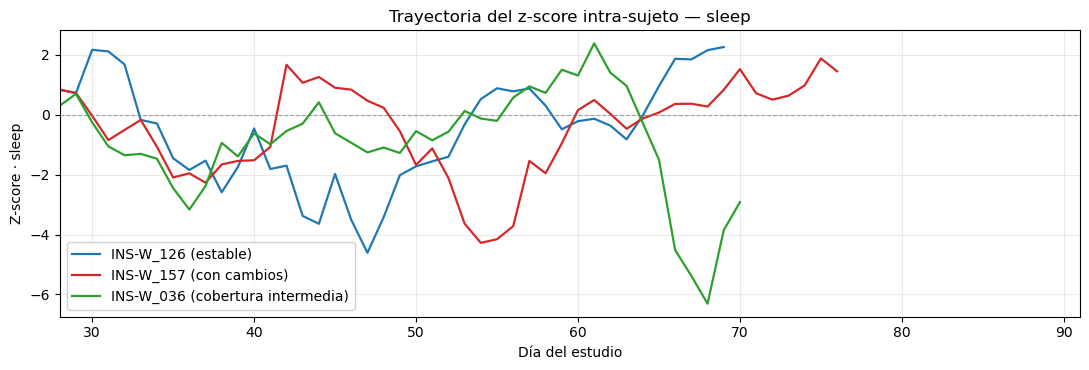

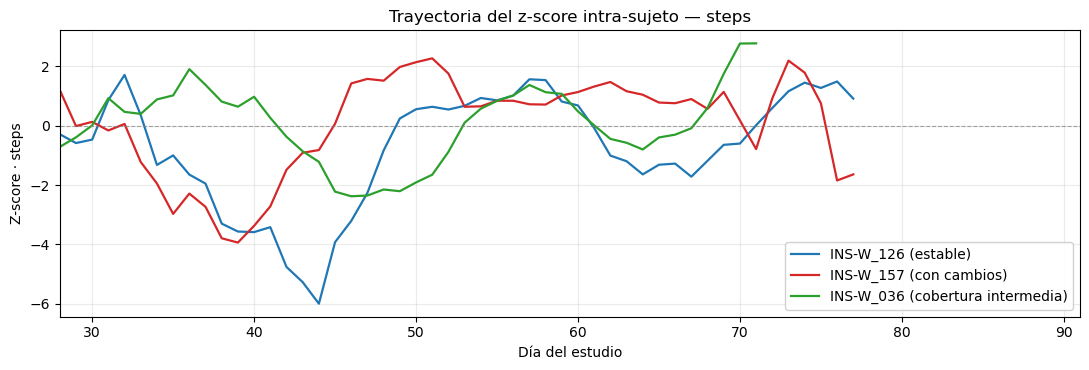

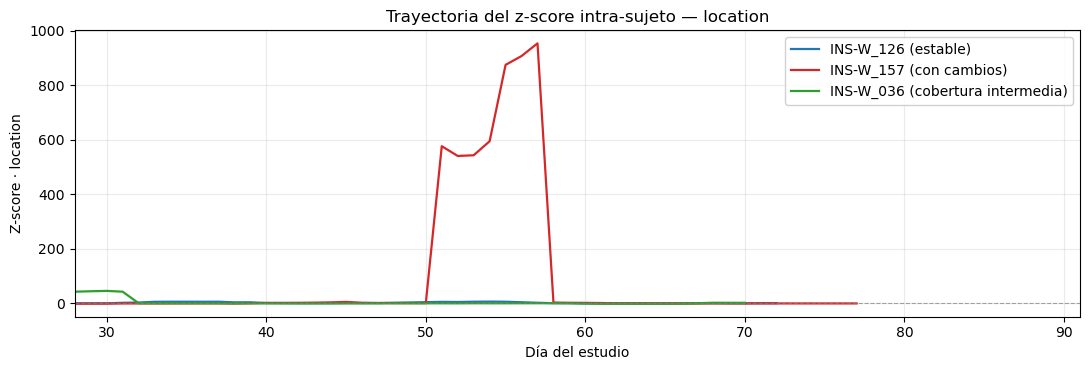

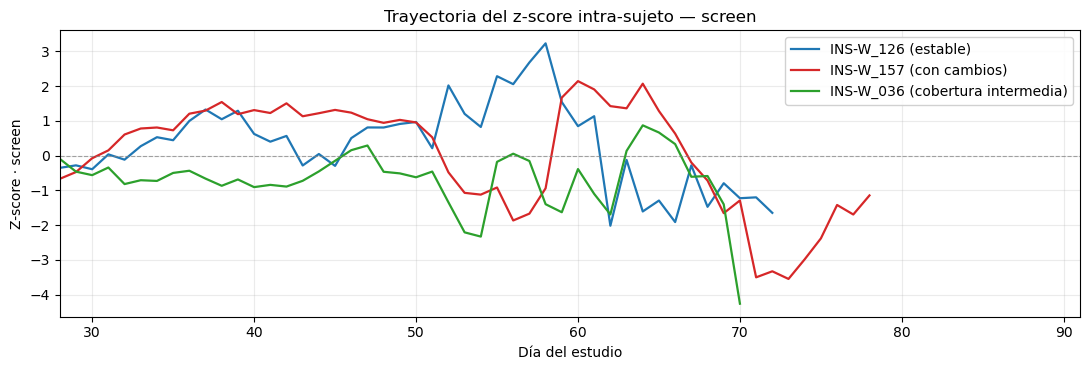

In [71]:
# Colores asociados al perfil, no al pid concreto.
# Los pids vienen del diccionario participantes_seleccionados de la celda anterior.
colores_por_perfil = {
    "estable":              "#1f77b4",
    "con cambios":          "#d62728",
    "cobertura intermedia": "#2ca02c",
}

for dim in ["sleep", "steps", "location", "screen"]:
    fig, ax = plt.subplots(figsize=(11, 3.8))
    for perfil, pid in participantes_seleccionados.items():
        sub = df_z.loc[pid].copy().reset_index(drop=True)
        sub["day"] = sub.index
        sub_eval = sub[sub["day"] >= 28]
        ax.plot(sub_eval["day"], sub_eval[dim],
                label=f"{pid} ({perfil})",
                color=colores_por_perfil[perfil], linewidth=1.6)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlim(28, 91)
    ax.set_xlabel("Día del estudio")
    ax.set_ylabel(f"Z-score · {dim}")
    ax.set_title(f"Trayectoria del z-score intra-sujeto — {dim}")
    ax.legend(loc="best", framealpha=0.9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**``Sleep``.** Las tres trayectorias presentan dinámicas distintas en el rango analizado. INS-W_126 (azul, perfil estable) oscila alrededor de cero a lo largo de toda su ventana, con un mínimo aislado en torno al día 47 a z≈-4.5 seguido de una recuperación gradual; cierra su rango el día 69 con valores en torno a +2.3. La trayectoria no muestra ninguna deriva sostenida en una dirección, lo que es coherente con su clasificación como perfil estable. INS-W_157 (rojo, perfil con cambios) muestra mayor variabilidad: oscila entre z≈-4.3 (mínimo hacia los días 55-56) y z≈+1.7, con varias inversiones de signo a lo largo del rango. No hay una dirección clara, pero la amplitud del recorrido es mayor que la del perfil estable, consistente con su clasificación. Cierra en torno al día 76 en valores cercanos a +1.5.

INS-W_036 (verde, cobertura intermedia) se mantiene mayoritariamente en una banda entre z≈-3.2 y z≈+0.5 a lo largo de la mayor parte del rango, pero presenta un descenso pronunciado al final, alcanzando z≈-6.3 en el día 68, con recuperación parcial hasta el día 70 (último día con `:allday` íntegra). Este descenso entra en la zona de discusión documentada en la sección 4.2: el criterio de truncamiento no distingue entre baja actividad real registrada (señal conductual) y registro parcial del wearable (artefacto de captura). Lo que sí podemos afirmar, por el ancho de la oscilación previa de este participante, es que su baseline std en sleep es estrecha, lo que amplifica el impacto en z-score de cualquier reducción puntual del agregado `:7dhist`: caídas modestas en la suma producen z muy negativos por la baja variabilidad propia. Si la caída refleja menos minutos de sueño reales o captura parcial del wearable no es separable con los datos disponibles; en cualquiera de los dos casos, el dato queda dentro del rango analizado y se conserva.

**``Steps``.** Las trayectorias se diferencian más entre sí en steps que en sleep. INS-W_126 (azul) presenta una caída pronunciada hasta z≈-6.0 hacia el día 44, seguida de una recuperación gradual; entre los días 60 y 70 oscila en valores cercanos a -1, y termina el rango (día 77) en valores ligeramente positivos. El mínimo en torno al día 44 es la observación más marcada del perfil estable entre las cuatro dimensiones para este participante, y coincide con un baseline relativamente estrecho en steps. INS-W_157 (rojo) recorre un rango entre z≈-3.9 (mínimo en los días 39-40) y z≈+2.3 (pico en torno al día 51-52), con varios cambios de dirección a lo largo del recorrido. Mantiene valores positivos entre los días 50 y 75 antes de cerrar el rango en el día 77 con valores ligeramente negativos.

INS-W_036 (verde) es la trayectoria con menor amplitud de las tres en steps: oscila entre z≈-2.4 y z≈+2.8 sin episodios extremos, y termina el rango (día 71) con una subida pronunciada hasta +2.8. La trayectoria de INS-W_036 en steps contrasta con la que muestra el mismo participante en sleep, donde aparecía el descenso final discutido arriba: esta es la utilidad de la inspección por dimensión, ya que permite ver que un mismo participante puede tener perfiles distintos en distintas dimensiones del comportamiento. Específicamente, la subida final en steps no acompaña al descenso final en sleep, lo que descarta la hipótesis de que la dinámica final de este participante sea uniformemente extrema en toda su conducta: parece más bien circunscrita a sleep (y, como se verá, a screen).

**``Location``.** La figura está completamente dominada por INS-W_157 (rojo), cuyo z-score alcanza un pico de aproximadamente +950 entre los días 50 y 58, formando una meseta de cuatro órdenes de magnitud por encima del resto de valores de la figura. El efecto visual es que las trayectorias de INS-W_126 e INS-W_036 quedan aplastadas en una banda casi imperceptible cerca de cero. El pico de INS-W_157 corresponde a la cola derecha extrema de location documentada como propiedad estructural de la dimensión en el Bloque 3: durante varios días puntuales el participante registra un radio de giro geográfico muy superior a su patrón habitual, lo que sobre un baseline construido en condiciones de movilidad estable produce z-scores numéricamente enormes. El comportamiento es coherente con un evento concreto y acotado en el tiempo, no con un deterioro conductual: viajes, mudanza temporal, cambio puntual de patrón de desplazamiento son las hipótesis más plausibles.

Aunque las trayectorias de INS-W_126 e INS-W_036 quedan aplanadas por la escala, el ejercicio confirma dos cosas que ya se anticipaban. Primera, que la métrica de variabilidad utilizada para seleccionar a INS-W_157 como participante "con cambios" está dominada por la cola de location, como se documentó en la sección de selección de participantes; este patrón se vería neutralizado si la variabilidad se calculara sin location, o con location winsorizada, o con location en escala logarítmica. Segunda, que la dimensión location tiene una escala estructuralmente distinta de las otras tres, por lo que cualquier operación posterior que combine las cuatro dimensiones tendrá que tratar location aparte; esto queda como decisión técnica pendiente para bloques posteriores, registrada como decisión abierta en la consolidación.

Los cortes en location se sitúan en los días 72 (INS-W_126), 77 (INS-W_157) y 70 (INS-W_036). Conviene recordar que en location el agregado `:7dhist` es media móvil, no suma, lo que tiene como consecuencia que los huecos en `:allday` para esta dimensión no introducen el mismo tipo de sesgo a la baja que producen en sleep, steps y screen: una media móvil con observaciones faltantes no se sesga direccionalmente, solo pierde representatividad. Esto es coherente con la ausencia de "caídas espurias" al final del rango en location, en contraste con las que aparecen en sleep y screen.

**``Screen``.** INS-W_126 (azul) oscila a lo largo de la mayor parte del rango entre z≈-1 y z≈+1, con un pico positivo destacado en torno al día 58 alcanzando z≈+3.2 y un cierre del rango (día 72) en valores ligeramente negativos. La oscilación es frecuente pero la amplitud habitual es modesta, consistente con un perfil estable también en esta dimensión. INS-W_157 (rojo) muestra un patrón más complejo: arranca con valores ligeramente negativos hacia el día 28, sube progresivamente a una meseta positiva entre los días 35 y 50 (con valores entre +0.7 y +1.5), desciende a un mínimo de z≈-1.8 en torno al día 53, recupera hasta un máximo de z≈+2.1 hacia el día 61, y vuelve a descender hasta z≈-3.5 en torno al día 70 antes de recuperarse hasta valores cercanos a -1 al cierre del rango (día 78). La oscilación en screen es la más amplia y direccional de INS-W_157 entre las cuatro dimensiones, lo que es coherente con su clasificación como participante con cambios.

INS-W_036 (verde) se mantiene en una banda entre z≈-2.3 y z≈+0.9 durante la mayor parte del rango, pero al cierre (día 70) cae bruscamente hasta z≈-4.3. El patrón es paralelo al observado en sleep para el mismo participante: descenso terminal pronunciado en un perfil con baseline estrecha. Como se discutió en sleep, este descenso entra en la zona de ambigüedad del criterio de truncamiento: el día 70 tiene `:allday` válida (por eso pasa el criterio) pero el valor concreto puede reflejar baja actividad real o captura parcial del dispositivo, y los datos disponibles no permiten distinguir las dos lecturas. La coincidencia entre el descenso en sleep y el descenso en screen al final del rango de INS-W_036, combinada con la subida simultánea en steps, sugiere dos lecturas posibles: una caída específica del uso del wearable y del móvil (que afectaría a captura de sleep y screen pero no necesariamente a steps si los pasos los registra el móvil en el bolsillo), o una transformación conductual real en la que el participante duerme menos y usa menos el móvil pero se mueve más. Ambas hipótesis quedan registradas; el examen no es concluyente al respecto.

### Cierre de la inspección visual de trayectorias

La inspección visual de las cuatro dimensiones para los tres participantes seleccionados deja varias observaciones que sirven de base para las dos tareas restantes del Bloque 4.

Primera, las trayectorias del z-score intra-sujeto no son ruido alrededor de cero: muestran estructura temporal visible (tendencias graduales, oscilaciones, episodios marcados). Esto justifica el análisis temporal cuantitativo que sigue.

Segunda, la magnitud de las oscilaciones varía dramáticamente entre dimensiones, con location en una escala estructuralmente distinta del resto. Esto confirma que la dimensión location requiere tratamiento separado en cualquier operación posterior que combine las cuatro dimensiones, decisión que queda registrada como pendiente para bloques posteriores.

Tercera, los descensos terminales observados en sleep y screen para INS-W_036 ilustran la limitación documentada del criterio de truncamiento por (pid, dim): el criterio cierra en el último día con `:allday` íntegra, pero no distingue entre baja actividad real y captura parcial del dispositivo. Esta ambigüedad permanece sin resolver con la información disponible y se asume como coste metodológico.

Cuarta, ninguno de los tres participantes muestra una trayectoria sostenidamente extrema en las cuatro dimensiones simultáneamente. Los perfiles individuales son heterogéneos a lo largo del tiempo y entre dimensiones, lo que es coherente con la lógica del proyecto: el sistema final no busca detectar magnitud en una sola dimensión, sino convergencia 2/3 entre activación, sueño y uso pasivo. La inspección visual confirma que esa convergencia es la unidad de análisis correcta, no la magnitud aislada.

El siguiente paso del Bloque 4 es el análisis de autocorrelación de las cuatro Series. Ese análisis cuantifica lo que la inspección visual sugiere cualitativamente: si las trayectorias presentan dependencia temporal real, qué fracción de ella es estructural (inducida por construcción del baseline rolling sobre ventanas solapadas) y qué fracción es señal conductual auténtica.

### 4.3. Análisis de autocorrelación

El análisis cuantifica la dependencia temporal de las series del z-score construidas en bloques anteriores y la descompone en dos componentes: una componente estructural inducida por la propia construcción del baseline rolling, y una componente conductual que recoge la señal temporal real del comportamiento. La separación entre las dos componentes es el resultado central de esta sección.

**Por qué este análisis es necesario.** Los valores del z-score de días vecinos no son independientes por construcción. El baseline del día d se calcula sobre la ventana [d-28, d-8] y el baseline del día d+1 sobre [d-27, d-7]; ambos comparten 20 de sus 21 días. Como los baselines son casi idénticos, los z-scores derivados heredan correlación estructural entre días próximos. Esa correlación aparecería en la serie del z-score incluso si la conducta subyacente fuera ruido puro, sin información temporal de ningún tipo. Antes de construir features temporales en el Bloque 5 hace falta saber cuánta de la autocorrelación observada es señal conductual real y cuánta es artefacto del propio cálculo.

**Técnicas estadísticas utilizadas.** El análisis se apoya en dos funciones complementarias:

- **ACF (función de autocorrelación):** para cada lag k, mide la correlación lineal entre el valor del día d y el valor del día d-k. Devuelve un número entre -1 y +1 para cada lag; un decaimiento lento indica memoria persistente, una caída rápida indica memoria corta, valores cercanos a cero indican ausencia de estructura temporal.
- **PACF (autocorrelación parcial):** mide la correlación directa entre el día d y el día d-k descontando la influencia de los lags intermedios. Permite identificar lags con dependencia directa frente a correlaciones que se propagan por contagio entre lags.

ACF y PACF se interpretan en conjunto. La forma del decaimiento de cada una identifica el tipo de dependencia temporal de la serie.

**Diseño de la implementación.** Se fijan tres decisiones de diseño:

1. **Conjunto de participantes.** Se calculan ACF y PACF individualmente para los tres participantes seleccionados en la sección 4.1 (INS-W_126, INS-W_157, INS-W_036) por continuidad con la inspección visual previa, y de forma agregada sobre todos los participantes con cobertura suficiente (al menos 42 observaciones evaluables tras el truncamiento aplicado en 4.2), promediando ACF y PACF individuales lag a lag. El número de participantes incluidos en la agregación se sitúa entre 70 y 106 según la dimensión.

2. **Rango de lags.** El techo conceptual del análisis se sitúa en lag 28: más allá de ese horizonte los baselines de días distantes no comparten ningún día entre sí y la inducción estructural desaparece. La implementación práctica se queda en lag 21 para ACF y lag 20 para PACF por una restricción muestral propia de la PACF, cuyo cálculo requiere `nlags < N/2`. Con observaciones evaluables en el rango 42-51 por participante, ese límite muestral fija el rango efectivo en 20-21 lags.

3. **Separación estructural vs conductual.** Para distinguir las dos componentes se aplica un procedimiento de simulación de ruido. Se generan 1000 series sintéticas de 92 días con ruido gaussiano independiente día a día y sin estructura conductual alguna. Esas series se procesan por el mismo pipeline aplicado a los datos reales (cálculo de :7dhist, baseline rolling con buffer, z-score), y sobre el resultado se calculan ACF y PACF. La salida promediada sobre las 1000 simulaciones es la línea base estructural: la autocorrelación que el propio cálculo introduce por construcción, en ausencia de cualquier señal real. La comparación punto a punto entre las curvas observadas y esta línea base estructural deja al descubierto la autocorrelación conductual neta.

**Estructura de la sección.** El análisis se desarrolla en tres pasos sucesivos. Primero, cálculo de ACF y PACF observadas sobre los tres participantes seleccionados, con interpretación cualitativa de la huella temporal. Segundo, construcción de la línea base estructural por simulación de ruido y comparación con las curvas observadas individuales. Tercero, agregación poblacional de las curvas observadas sobre todos los participantes con cobertura suficiente y comparación con la línea base estructural a escala de cohorte. La conclusión metodológica y las consecuencias para el diseño de features temporales del Bloque 5 cierran la sección.

La función ACF y la función PACF se calculan sobre las series del z-score de los tres participantes seleccionados en la sección 4.1 (INS-W_126, INS-W_157, INS-W_036), en las cuatro dimensiones. La salida son cuatro figuras, una por dimensión, con ACF en el panel superior y PACF en el inferior, los tres participantes superpuestos en cada panel.

El techo de lag 28 fijado en el diseño metodológico no es alcanzable en la implementación por una restricción muestral propia de la PACF, cuyo cálculo requiere `nlags < N/2`. Tras el truncamiento aplicado en la sección 4.2 y la eliminación de NaN, los tres participantes disponen de entre 42 y 51 observaciones evaluables, lo que limita la PACF a un máximo de 20 lags. La ACF se calcula hasta lag 21 para mantener ambos paneles en un rango comparable. La justificación conceptual del techo de 28 sigue siendo válida (más allá de ese horizonte los baselines de días distantes no comparten días entre sí y la inducción estructural desaparece); el límite efectivo lo fija el tamaño muestral, no la lógica del análisis.

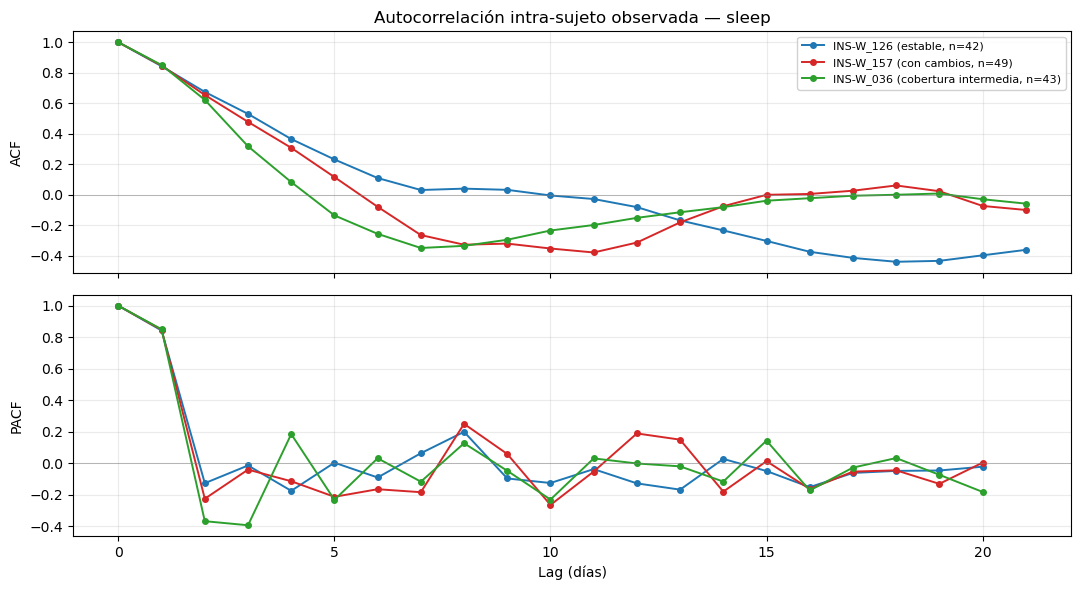

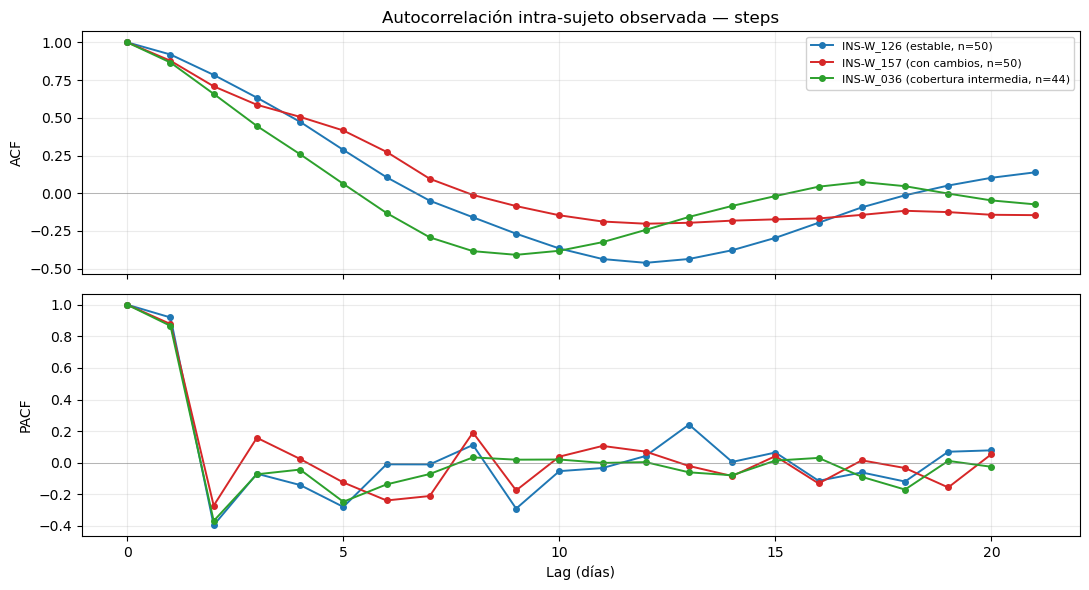

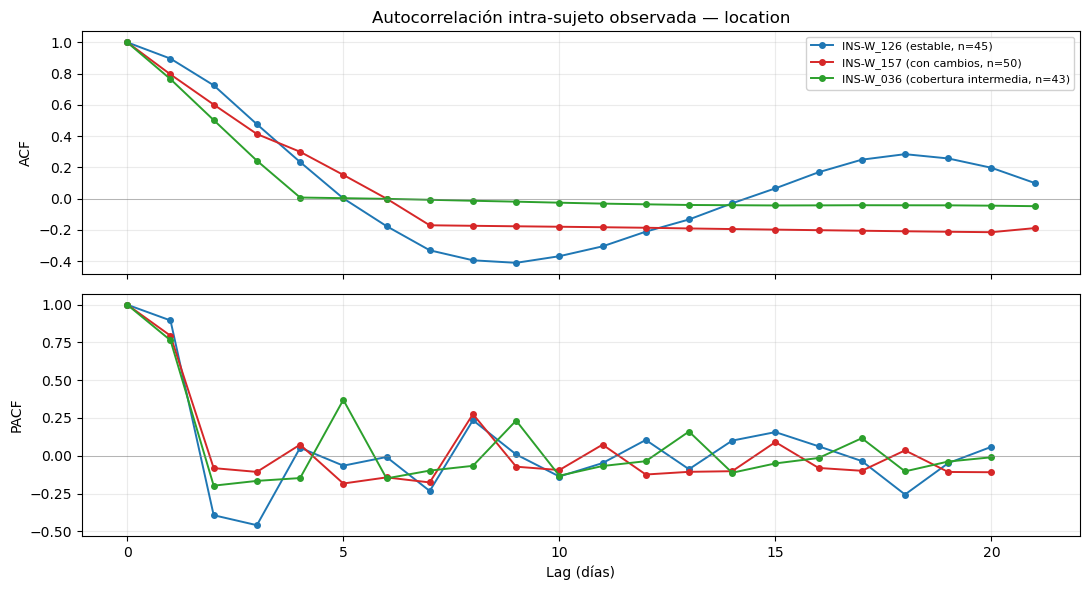

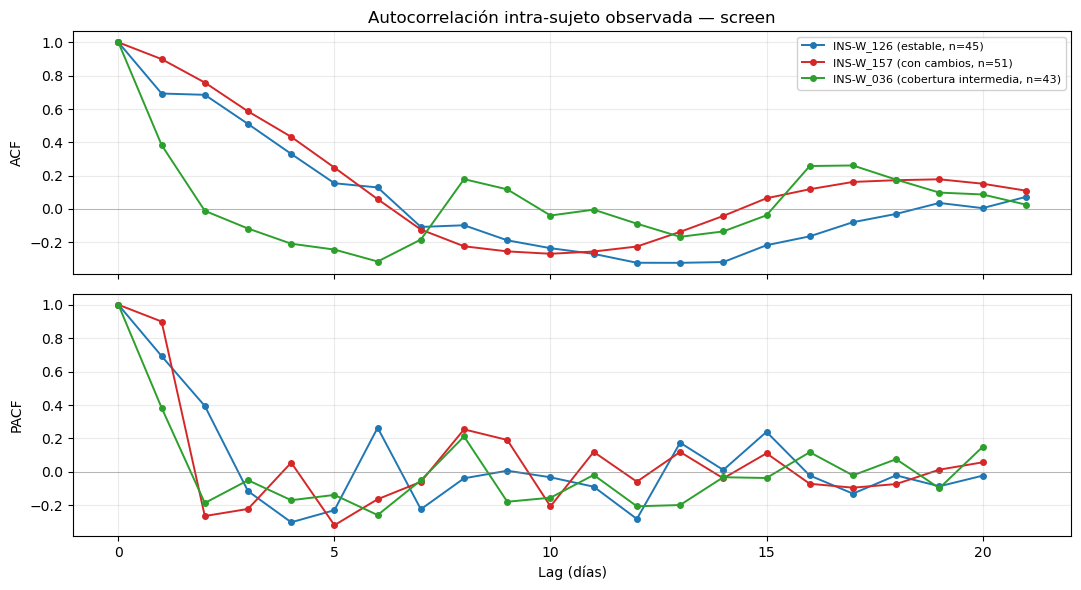

In [72]:
N_LAGS_ACF = 21
N_LAGS_PACF = 20

colores_por_perfil = {
    "estable":              "#1f77b4",
    "con cambios":          "#d62728",
    "cobertura intermedia": "#2ca02c",
}

# Calcular ACF y PACF observadas para cada (pid, dim) de los tres seleccionados
resultados_acf_pacf = {}
for dim in ["sleep", "steps", "location", "screen"]:
    resultados_acf_pacf[dim] = {}
    for perfil, pid in participantes_seleccionados.items():
        serie = df_z.loc[pid, dim].dropna()
        if len(serie) < 2 * N_LAGS_PACF + 2:
            print(f"Omitido: {pid} {dim} solo tiene {len(serie)} obs evaluables.")
            continue
        acf_vals = acf(serie, nlags=N_LAGS_ACF, fft=False)
        pacf_vals = pacf(serie, nlags=N_LAGS_PACF, method="ywm")
        resultados_acf_pacf[dim][pid] = {
            "acf": acf_vals,
            "pacf": pacf_vals,
            "perfil": perfil,
            "n_obs": len(serie),
        }

# Una figura por dimensión: ACF arriba, PACF abajo, tres participantes superpuestos
for dim in ["sleep", "steps", "location", "screen"]:
    fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    for pid, data in resultados_acf_pacf[dim].items():
        color = colores_por_perfil[data["perfil"]]
        ax_acf.plot(np.arange(N_LAGS_ACF + 1), data["acf"], "o-",
                    label=f"{pid} ({data['perfil']}, n={data['n_obs']})",
                    color=color, linewidth=1.4, markersize=4)
        ax_pacf.plot(np.arange(N_LAGS_PACF + 1), data["pacf"], "o-",
                     color=color, linewidth=1.4, markersize=4)
    ax_acf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_pacf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_acf.set_ylabel("ACF")
    ax_pacf.set_ylabel("PACF")
    ax_pacf.set_xlabel("Lag (días)")
    ax_acf.set_title(f"Autocorrelación intra-sujeto observada — {dim}")
    ax_acf.legend(loc="best", fontsize=8, framealpha=0.9)
    ax_acf.grid(True, alpha=0.25)
    ax_pacf.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**``Interpretación de la autocorrelación observada``**

**Hallazgo central: uniformidad estructural en las cuatro dimensiones.** 

Las cuatro figuras muestran exactamente el mismo patrón cualitativo. La ACF parte de 1.0 en lag 0, cae aproximadamente en 0.85 en lag 1, sigue descendiendo durante varios días, cruza cero, entra en territorio negativo, y termina oscilando alrededor de cero a lags altos. La PACF parte también de 1.0, cae a 0.85 en lag 1, y de lag 2 en adelante salta directamente a la franja de ruido alrededor de cero. 

La consistencia de este patrón entre dimensiones (sleep, steps, location, screen) y entre los tres participantes seleccionados es el resultado metodológico principal: confirma que la dependencia temporal de las series del z-score se canaliza casi por completo a través de un único eslabón, la conexión entre día d y día d-1. La aparente memoria a varios días que muestra la ACF es consecuencia indirecta de esa cadena (día 2 hereda de día 1, día 3 hereda de día 2, y así sucesivamente), no de conexiones directas entre días distantes. 

El valor de aproximadamente 0.85 en lag 1 es la magnitud central que cuantifica esa dependencia estructural y será el parámetro de referencia frente al cual la simulación de ruido del siguiente paso permitirá separar componente estructural y componente conductual.

**Comportamiento del dip negativo en lags medios.** 

El cruce de la ACF a territorio negativo en lags 5-10 y la oscilación posterior alrededor de cero reflejan el comportamiento de compensación inherente al z-score con baseline rolling: rachas sostenidas por encima del baseline arrastran al propio baseline hacia arriba al avanzar la ventana, lo que fuerza a los días posteriores a salir relativamente más bajos. Es un artefacto esperado de la construcción del z-score, predicho por la metodología.

**Matices secundarios entre dimensiones.** 

Sobre el patrón común, las cuatro dimensiones presentan pequeñas diferencias en la profundidad del dip negativo y la velocidad de recuperación posterior. El dip es algo más profundo en steps y más amortiguado en screen; la recuperación al rango cero es más lenta en steps y screen que en sleep; location presenta mayor variabilidad entre participantes que las otras tres dimensiones. 

Estas diferencias son consistentes con escalas temporales conductuales ligeramente distintas en cada dimensión y se anotan como información complementaria para el diseño de features en el Bloque 5, sin alterar la conclusión principal sobre la estructura común de la autocorrelación.

``Línea base estructural por simulación de ruido``

Una vez analizadas ACF y PACF observadas, queda por determinar cuánto de esa autocorrelación es señal conductual real y cuánto es efecto colateral del propio cálculo del z-score (los baselines de días vecinos comparten 20 de sus 21 días, lo que liga mecánicamente sus z-scores). Para separarlo, se procesa ruido aleatorio sin señal por el mismo pipeline: la autocorrelación que resulta es el efecto puro del cálculo, y la diferencia respecto a la observada es la conexión conductual real.

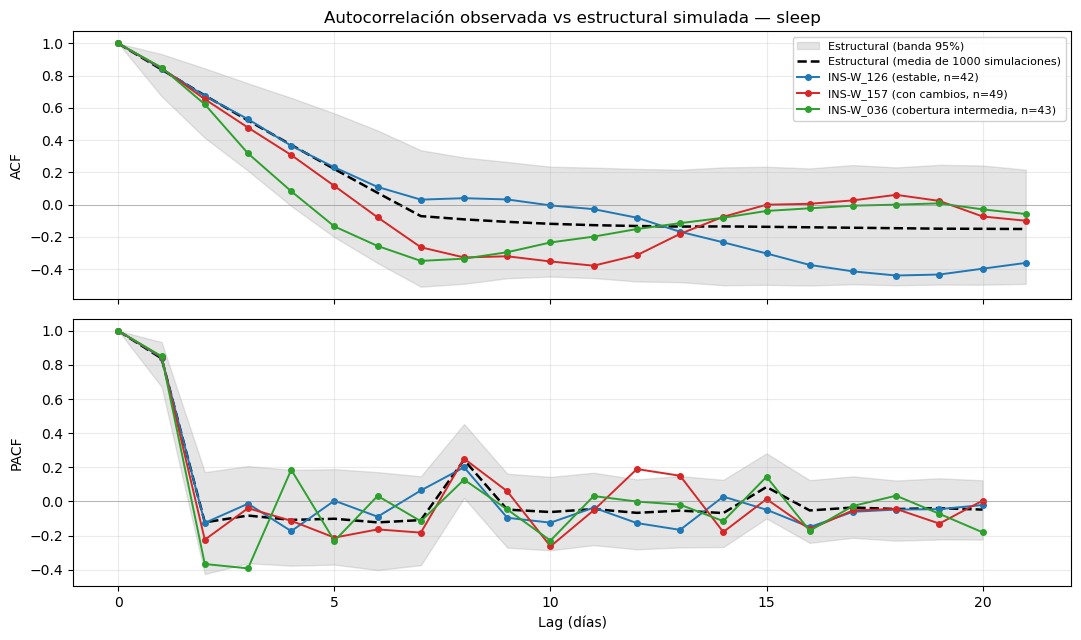

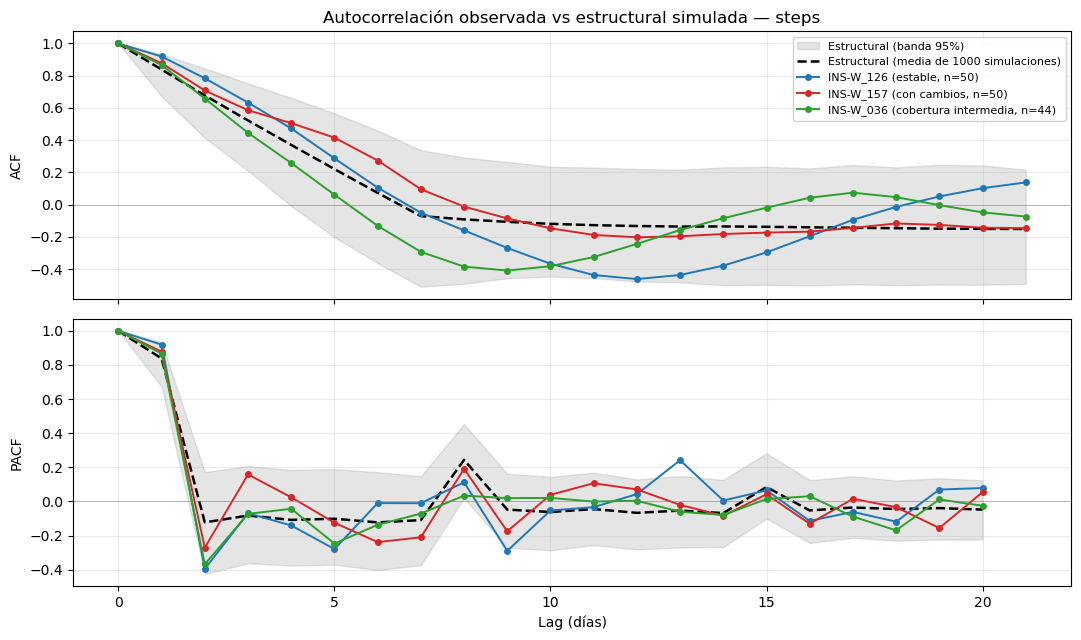

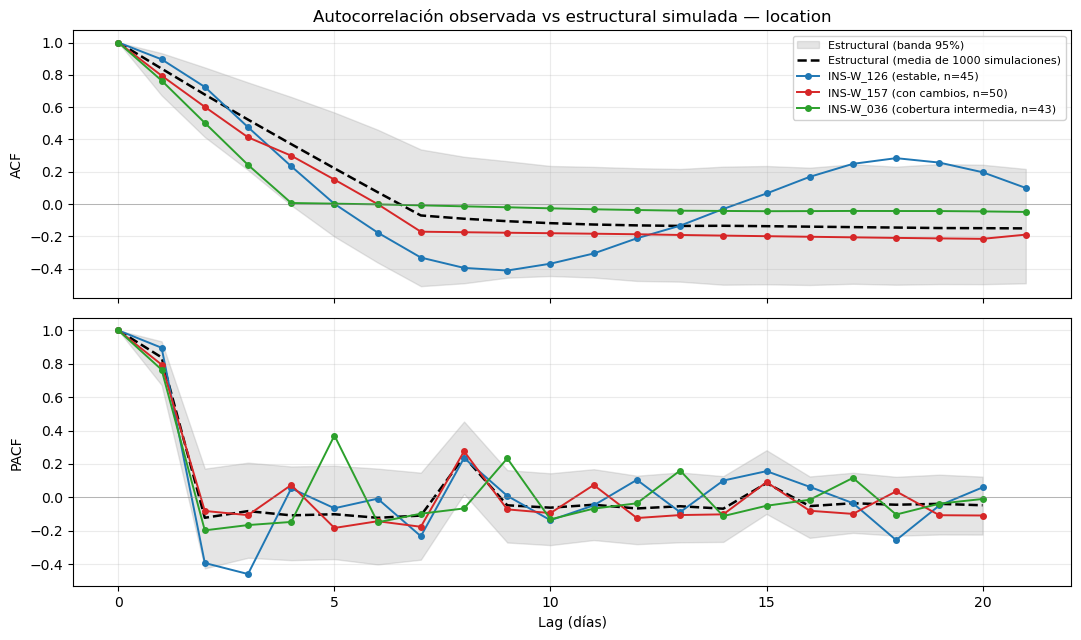

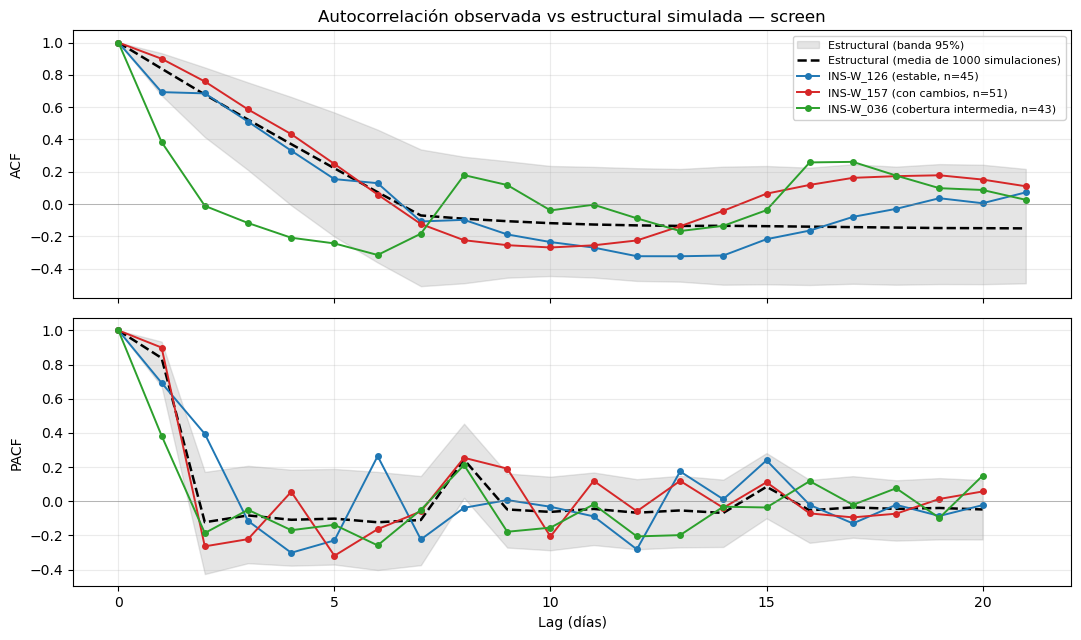

In [73]:
# Parámetros del pipeline (replican los aplicados sobre datos reales en el Bloque 2)
N_SIM = 1000
N_DAYS_RAW = 92
W_7D = 7         # ventana :7dhist
W_BASELINE = 21  # ventana del baseline rolling
BUFFER = 7       # buffer entre fin de baseline y día evaluado

def aplicar_pipeline_zscore(raw):
    """Aplica raw -> :7dhist -> baseline rolling -> z-score."""
    n = len(raw)
    sevendhist = np.full(n, np.nan)
    for d in range(W_7D - 1, n):
        sevendhist[d] = raw[d - W_7D + 1 : d + 1].sum()
    z = np.full(n, np.nan)
    primer_d_valido = W_BASELINE + BUFFER + W_7D - 1
    for d in range(primer_d_valido, n):
        ventana = sevendhist[d - W_BASELINE - BUFFER + 1 : d - BUFFER + 1]
        b_mean = ventana.mean()
        b_std = ventana.std(ddof=1)
        if b_std > 0:
            z[d] = (sevendhist[d] - b_mean) / b_std
    return z

# Generación de N_SIM series y cálculo de ACF/PACF estructurales
np.random.seed(42)
acf_struct_lista = []
pacf_struct_lista = []

for _ in range(N_SIM):
    raw = np.random.randn(N_DAYS_RAW)
    z = aplicar_pipeline_zscore(raw)
    z_valid = z[~np.isnan(z)]
    if len(z_valid) < 2 * N_LAGS_PACF + 2:
        continue
    acf_struct_lista.append(acf(z_valid, nlags=N_LAGS_ACF, fft=False))
    pacf_struct_lista.append(pacf(z_valid, nlags=N_LAGS_PACF, method="ywm"))

acf_struct_arr = np.array(acf_struct_lista)
pacf_struct_arr = np.array(pacf_struct_lista)
acf_struct_mean = acf_struct_arr.mean(axis=0)
pacf_struct_mean = pacf_struct_arr.mean(axis=0)
acf_struct_p2_5 = np.percentile(acf_struct_arr, 2.5, axis=0)
acf_struct_p97_5 = np.percentile(acf_struct_arr, 97.5, axis=0)
pacf_struct_p2_5 = np.percentile(pacf_struct_arr, 2.5, axis=0)
pacf_struct_p97_5 = np.percentile(pacf_struct_arr, 97.5, axis=0)

# Visualización: curva estructural superpuesta a las observadas, una figura por dimensión
for dim in ["sleep", "steps", "location", "screen"]:
    fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    
    lags_acf = np.arange(N_LAGS_ACF + 1)
    lags_pacf = np.arange(N_LAGS_PACF + 1)
    
    ax_acf.fill_between(lags_acf, acf_struct_p2_5, acf_struct_p97_5,
                         alpha=0.20, color="gray", label="Estructural (banda 95%)")
    ax_acf.plot(lags_acf, acf_struct_mean, "k--", linewidth=1.8,
                label="Estructural (media de 1000 simulaciones)")
    ax_pacf.fill_between(lags_pacf, pacf_struct_p2_5, pacf_struct_p97_5,
                          alpha=0.20, color="gray")
    ax_pacf.plot(lags_pacf, pacf_struct_mean, "k--", linewidth=1.8)
    
    for pid, data in resultados_acf_pacf[dim].items():
        color = colores_por_perfil[data["perfil"]]
        ax_acf.plot(lags_acf, data["acf"], "o-",
                    label=f"{pid} ({data['perfil']}, n={data['n_obs']})",
                    color=color, linewidth=1.4, markersize=4)
        ax_pacf.plot(lags_pacf, data["pacf"], "o-", color=color,
                     linewidth=1.4, markersize=4)
    
    ax_acf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_pacf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_acf.set_ylabel("ACF")
    ax_pacf.set_ylabel("PACF")
    ax_pacf.set_xlabel("Lag (días)")
    ax_acf.set_title(f"Autocorrelación observada vs estructural simulada — {dim}")
    ax_acf.legend(loc="best", fontsize=8, framealpha=0.9)
    ax_acf.grid(True, alpha=0.25)
    ax_pacf.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Hallazgo central: la línea base estructural reproduce el patrón observado.** 

En las cuatro dimensiones, la curva estructural (línea negra discontinua) sigue cualitativamente las curvas observadas con muy poca distancia entre ambas. El valor que cuantifica la dependencia día a día, aproximadamente 0.85 en lag 1, coincide entre observada y estructural en todas las dimensiones. Las tres curvas observadas se mantienen mayoritariamente dentro de la banda del 95% estructural a lo largo del rango de lags. Esto implica que la mayor parte de la autocorrelación visible en las series del z-score es subproducto mecánico del propio cálculo, no señal conductual real. El componente conductual neto, definido como la diferencia punto a punto entre observada y estructural, es pequeño (del orden de ±0.1 en la mayoría de lags) y no presenta un patrón sistemático compartido entre dimensiones.

**Desviaciones individuales informativas.** 

Sobre el patrón común se identifican tres puntos donde algún participante sale claramente de la banda estructural:

- *Location, INS-W_126:* PACF en lag 2 próxima a -0.45, claramente por debajo de la banda estructural, y ACF entre lags 7 y 10 también por debajo con valores cercanos a -0.40. Apunta a una conexión inversa directa entre días y a un patrón de compensación más fuerte de lo que el cálculo introduce por sí solo en sus desplazamientos.
- *Screen, INS-W_126:* PACF en lag 6 próxima a 0.25, por encima del rango estructural. Sugiere un componente semanal en su patrón de uso del móvil.
- *Sleep, INS-W_036:* PACF en lag 2 próxima a -0.40, por debajo de la banda estructural. Conexión inversa directa entre día d y día d-2 en su patrón de sueño.

Estas desviaciones son señal conductual neta y quedan registradas como entradas para análisis individualizados en bloques posteriores.

**Consecuencias para el diseño de features.** 

Cualquier feature construido sobre lags cortos del z-score (lag-1, lag-2) heredará mayoritariamente la dependencia estructural y aportará poca información discriminativa por encima del baseline. Las features que capten señal conductual neta deberán construirse sobre comparaciones a horizontes donde la dependencia estructural ya se haya disipado (lag 7 en adelante) o sobre cambios temporales más amplios (deltas semanales, persistencia de desviaciones por encima de umbrales). La regla operativa central del proyecto, convergencia 2/3 sobre el z-score con persistencia de siete días, sigue siendo válida porque opera sobre el valor del z-score y por construcción integra un horizonte temporal mayor al lag de la dependencia estructural.

La validación a escala poblacional del resultado obtenido sobre tres participantes individuales requiere extender el cálculo de ACF y PACF observadas a todos los participantes con al menos 42 observaciones evaluables (umbral mínimo impuesto por la restricción muestral de la PACF). Los valores se promedian lag a lag a través de los participantes incluidos, obteniendo una curva media por dimensión con banda del 95%. La superposición de esta curva con la línea base estructural simulada confirmaría, o no, que el patrón observado en los casos individuales se mantiene como propiedad de la cohorte.

Umbral de inclusión: ≥ 42 observaciones evaluables por (pid, dim)
Total de participantes en df_z: 155

Dimensión   N incluidos    % incluidos
--------------------------------------
sleep                70          45.2%
steps                90          58.1%
location            106          68.4%
screen              102          65.8%



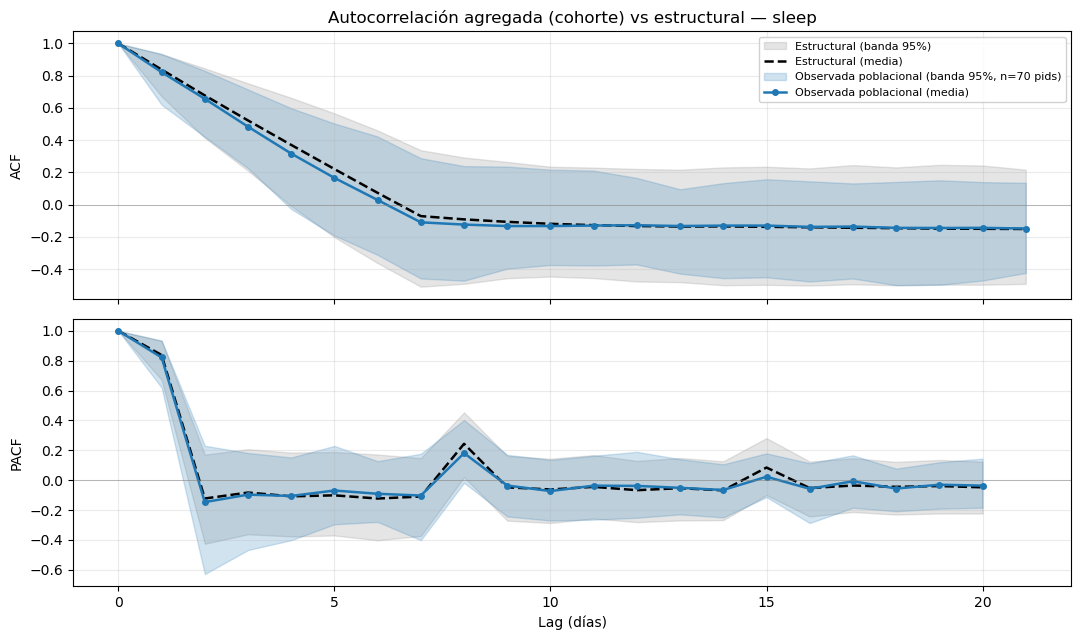

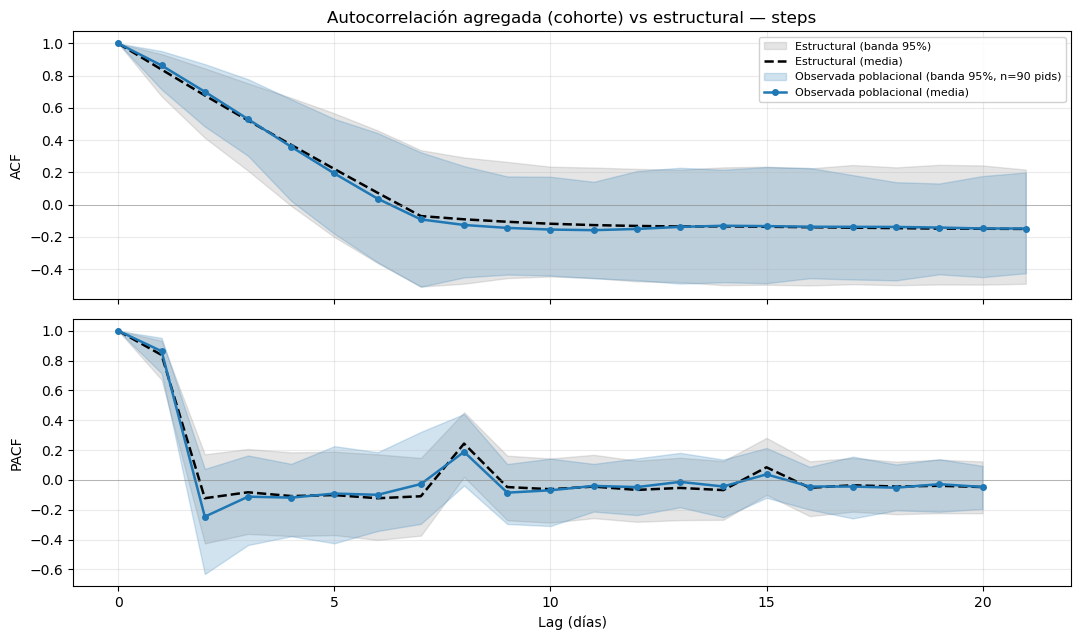

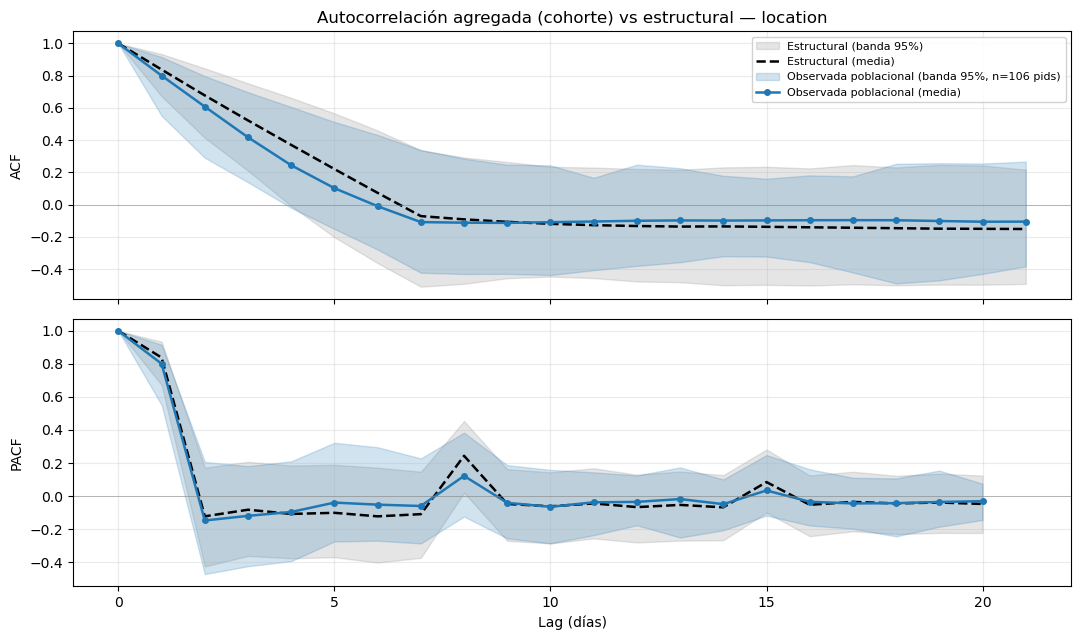

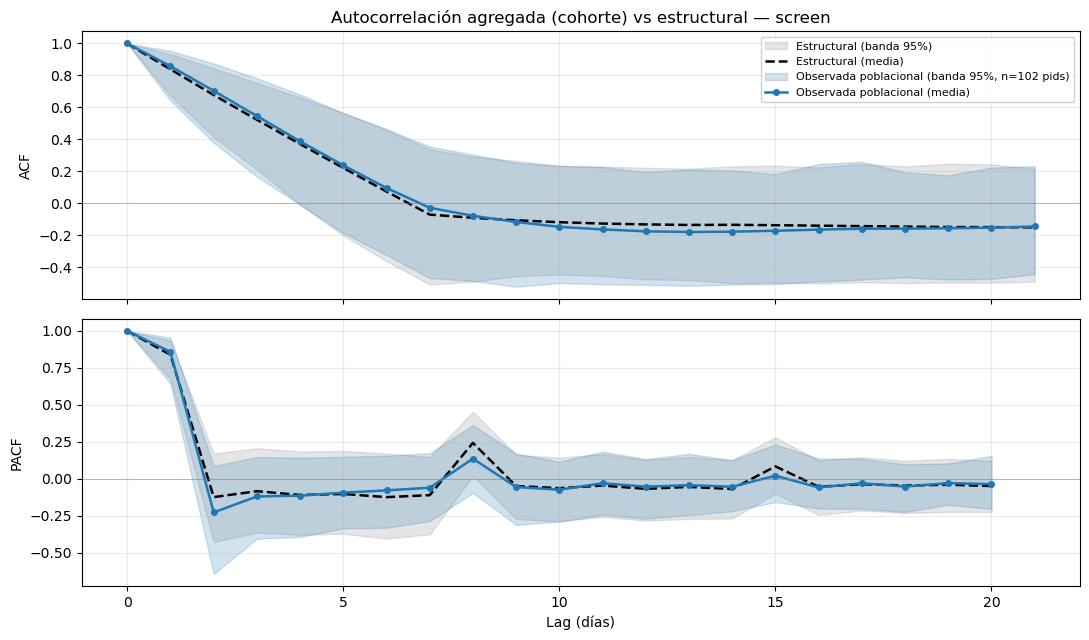

In [74]:
# Agregación poblacional: ACF y PACF observadas sobre todos los pids con cobertura suficiente
MIN_OBS_AGREGADO = 2 * N_LAGS_PACF + 2  # 42 obs mínimas para PACF

agregado_por_dim = {}
for dim in ["sleep", "steps", "location", "screen"]:
    acf_individuales = []
    pacf_individuales = []
    for pid in df_z.index.get_level_values("pid").unique():
        serie = df_z.loc[pid, dim].dropna()
        if len(serie) < MIN_OBS_AGREGADO:
            continue
        acf_individuales.append(acf(serie, nlags=N_LAGS_ACF, fft=False))
        pacf_individuales.append(pacf(serie, nlags=N_LAGS_PACF, method="ywm"))
    
    acf_arr = np.array(acf_individuales)
    pacf_arr = np.array(pacf_individuales)
    
    agregado_por_dim[dim] = {
        "n_pids": len(acf_individuales),
        "acf_mean": acf_arr.mean(axis=0),
        "acf_p2_5": np.percentile(acf_arr, 2.5, axis=0),
        "acf_p97_5": np.percentile(acf_arr, 97.5, axis=0),
        "pacf_mean": pacf_arr.mean(axis=0),
        "pacf_p2_5": np.percentile(pacf_arr, 2.5, axis=0),
        "pacf_p97_5": np.percentile(pacf_arr, 97.5, axis=0),
    }
    
# Tabla de transparencia: N de participantes que superan el umbral por dimensión
total_pids = df_z.index.get_level_values("pid").nunique()
print(f"Umbral de inclusión: ≥ {MIN_OBS_AGREGADO} observaciones evaluables por (pid, dim)")
print(f"Total de participantes en df_z: {total_pids}\n")
print(f"{'Dimensión':<10} {'N incluidos':>12} {'% incluidos':>14}")
print("-" * 38)
for dim in ["sleep", "steps", "location", "screen"]:
    n = agregado_por_dim[dim]["n_pids"]
    pct = 100 * n / total_pids
    print(f"{dim:<10} {n:>12} {pct:>13.1f}%")
print()

# Visualización: agregado observado vs estructural por dimensión
for dim in ["sleep", "steps", "location", "screen"]:
    agg = agregado_por_dim[dim]
    fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    
    lags_acf = np.arange(N_LAGS_ACF + 1)
    lags_pacf = np.arange(N_LAGS_PACF + 1)
    
    ax_acf.fill_between(lags_acf, acf_struct_p2_5, acf_struct_p97_5,
                         alpha=0.20, color="gray", label="Estructural (banda 95%)")
    ax_acf.plot(lags_acf, acf_struct_mean, "k--", linewidth=1.8,
                label="Estructural (media)")
    ax_pacf.fill_between(lags_pacf, pacf_struct_p2_5, pacf_struct_p97_5,
                          alpha=0.20, color="gray")
    ax_pacf.plot(lags_pacf, pacf_struct_mean, "k--", linewidth=1.8)
    
    ax_acf.fill_between(lags_acf, agg["acf_p2_5"], agg["acf_p97_5"],
                         alpha=0.20, color="C0",
                         label=f"Observada poblacional (banda 95%, n={agg['n_pids']} pids)")
    ax_acf.plot(lags_acf, agg["acf_mean"], "-", color="C0", linewidth=1.8,
                marker="o", markersize=4, label="Observada poblacional (media)")
    ax_pacf.fill_between(lags_pacf, agg["pacf_p2_5"], agg["pacf_p97_5"],
                          alpha=0.20, color="C0")
    ax_pacf.plot(lags_pacf, agg["pacf_mean"], "-", color="C0", linewidth=1.8,
                 marker="o", markersize=4)
    
    ax_acf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_pacf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_acf.set_ylabel("ACF")
    ax_pacf.set_ylabel("PACF")
    ax_pacf.set_xlabel("Lag (días)")
    ax_acf.set_title(f"Autocorrelación agregada (cohorte) vs estructural — {dim}")
    ax_acf.legend(loc="best", fontsize=8, framealpha=0.9)
    ax_acf.grid(True, alpha=0.25)
    ax_pacf.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Confirmación poblacional del resultado individual.** 

Si observamos la salida del caodigo anterior vemos que antes de las gráficas, se muestra una tabla con el número de participantes que superan el umbral en cada dimensión. Ese umbral es 42 porque la función PACF exige que el número de lags sea menor que la mitad de las observaciones disponibles, lo que con 20 lags se traduce en 2·20+2 = 42 observaciones mínimas por persona. El N varía entre dimensiones porque el truncamiento de la sección 4.2 corta por (pid, dim): un mismo participante puede llegar a 51 días evaluables en una dimensión y quedarse en 38 en otra, según cuándo se rompe la integridad de su :allday. El N que aparece en la leyenda de cada figura es ese recuento.

La media poblacional observada y la línea base estructural simulada se solapan casi por completo en las cuatro dimensiones, tanto en ACF como en PACF, con bandas del 95% que se cruzan ampliamente en todo el rango de lags. Esto confirma a escala de cohorte la conclusión obtenida con los tres participantes individuales: el componente conductual neto de la autocorrelación es prácticamente cero a nivel poblacional. La huella temporal que se observa en las series del z-score (ACF decayendo desde 0.85 en lag 1, PACF concentrada en lag 1) es íntegramente subproducto del cálculo con baseline rolling, no señal conductual real. La señal conductual real vive en desviaciones individuales puntuales, no en la dinámica poblacional, lo cual es consistente con el marco N-of-1 del proyecto: la heterogeneidad relevante vive entre individuos, no en la media de la cohorte.

Para el diseño de features del Bloque 5 esto refuerza la conclusión obtenida con el análisis individual: las features temporales construidas sobre lags cortos del z-score heredarán íntegramente la dependencia estructural y no aportarán información discriminativa. Las features con potencial conductual real deben construirse sobre horizontes donde la dependencia estructural ya se ha disipado (lag 7 en adelante), sobre cambios temporales más amplios (deltas semanales, persistencia de desviaciones por encima de umbrales), o sobre los propios valores del z-score, que es lo que la regla operativa central del proyecto, convergencia 2/3 con persistencia de siete días, ya hace por construcción.

**Cierre del análisis de autocorrelación.** 

Las tres lecturas realizadas en esta sección (individual sobre tres participantes seleccionados, comparación con la línea base estructural simulada, agregación poblacional sobre todos los participantes con cobertura suficiente) convergen en una misma conclusión: la dependencia temporal observada en las series del z-score es íntegramente subproducto mecánico del cálculo con baseline rolling. El componente conductual neto a nivel poblacional es prácticamente cero. La señal conductual real, donde existe, aparece como desviaciones individuales puntuales que se apartan claramente de la banda estructural, y queda registrada para análisis individualizados en bloques posteriores.

Esta conclusión orienta el diseño de features temporales del Bloque 5: las features con potencial discriminativo conductual deben construirse sobre horizontes donde la dependencia estructural ya se ha disipado (lag 7 en adelante), sobre cambios temporales más amplios (deltas semanales, persistencia de desviaciones por encima de umbrales), o sobre los propios valores del z-score, que es lo que la regla operativa central del proyecto, convergencia 2/3 con persistencia de siete días, ya hace por construcción.

La caracterización del comportamiento temporal de las series del z-score mediante ventanas rolling, en la sección siguiente, complementa el análisis de autocorrelación con una descripción del nivel medio y la dispersión en escalas temporales de interés operativo.

### 4.4. Caracterización rolling sobre los z-scores

El análisis de la sección 4.3 estableció que los lags cortos del z-score están dominados por la dependencia estructural del baseline rolling, sin señal conductual neta por encima del artefacto. La conclusión operativa fue clara: las features con potencial discriminativo conductual no deben construirse sobre la dependencia entre días, sino sobre los valores del propio z-score sostenidos en el tiempo. Esta sección desarrolla esa herramienta. El cálculo rolling sobre el z-score caracteriza su nivel medio y su variabilidad en ventanas temporales móviles, produciendo el instrumento de lectura que la regla central del proyecto necesita: detección de desviaciones del baseline sostenidas durante varios días.

La regla operativa del proyecto, convergencia 2/3 con persistencia de siete días, opera precisamente sobre ese tipo de lectura. Un solo día con z-score elevado puede ser ruido o un evento puntual sin relevancia clínica; lo que el proyecto detecta como deterioro es un desplazamiento sostenido en el tiempo. El promedio del z-score en una ventana de siete días recoge ese desplazamiento sin verse distorsionado por la fluctuación diaria. Es la herramienta exacta para implementar la persistencia de siete días como rasgo cuantificable.

**Técnica utilizada.** Una ventana rolling de N días desliza a lo largo de la serie temporal y, en cada posición, calcula un estadístico sobre los N días previos. Aplicada al z-score con la operación "media" sobre una ventana de siete días, produce una nueva serie donde cada día contiene el promedio del z-score de la última semana. Esa versión suavizada elimina el ruido del día a día y deja visible la tendencia subyacente. El mismo procedimiento aplicado con la operación "desviación típica" produce una serie que cuantifica la dispersión del z-score en la misma ventana móvil.

**Diseño de la implementación.** Tres decisiones:

1. **Tamaño de ventana.** Siete días, alineado con la regla de persistencia del proyecto. Es el horizonte temporal más corto compatible con la definición operativa de deterioro.

2. **Métricas calculadas.** Dos por dimensión. El rolling mean del z-score, que captura el nivel medio del desplazamiento respecto al baseline en la última semana, e indica si la persona está sostenidamente por encima o por debajo de su patrón habitual. El rolling std del z-score, que captura la variabilidad del desplazamiento en la misma ventana, e indica si el patrón es estable o volátil.

3. **Participantes.** Los tres seleccionados en la sección 4.1 (INS-W_126, INS-W_157, INS-W_036), por continuidad con las secciones previas. La visualización superpone el rolling mean a la serie original del z-score en tono tenue para que el efecto del suavizado quede visible.

**Salida de la sección.** Cuatro figuras, una por dimensión, con dos paneles cada una: rolling mean en el panel superior (con la serie original superpuesta en tono tenue) y rolling std en el panel inferior. La lectura conjunta de las dos métricas permite distinguir desplazamientos sostenidos del baseline (visibles en el rolling mean) de periodos de inestabilidad conductual (visibles en el rolling std).

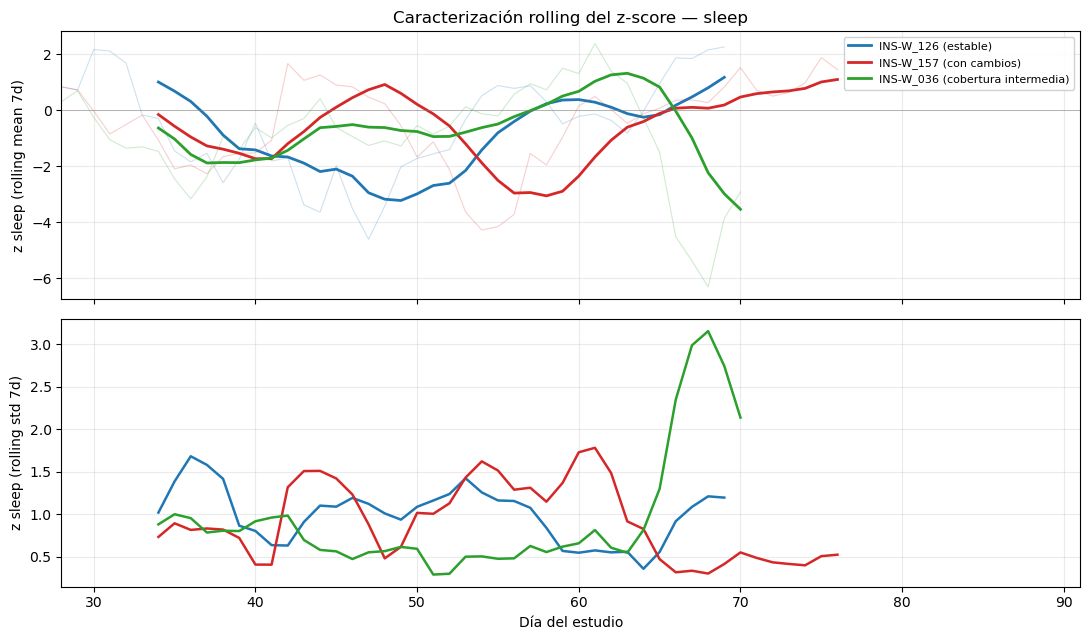

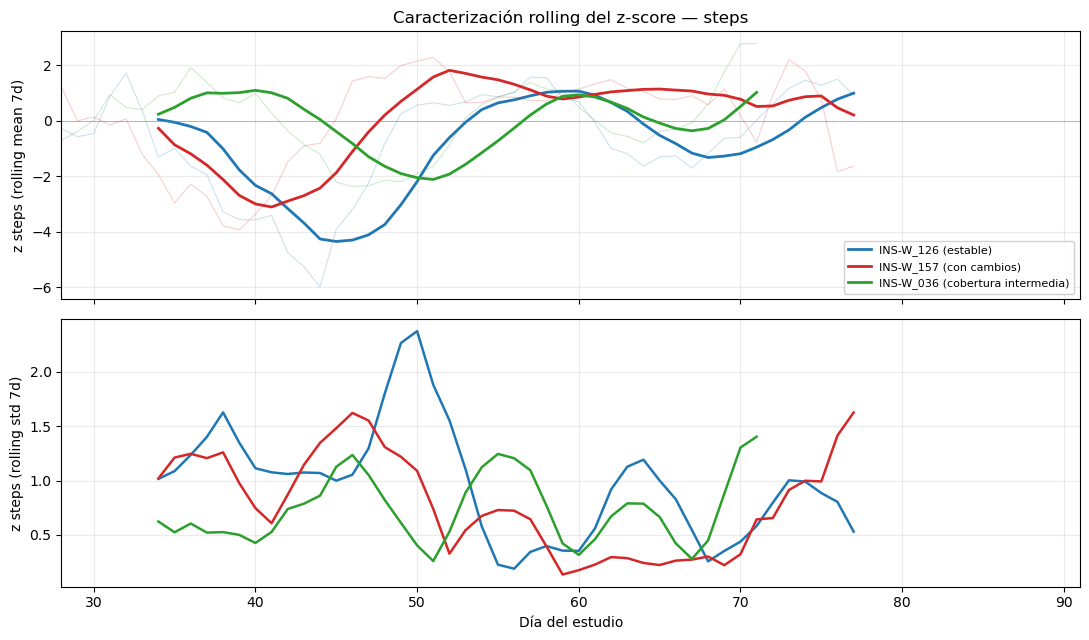

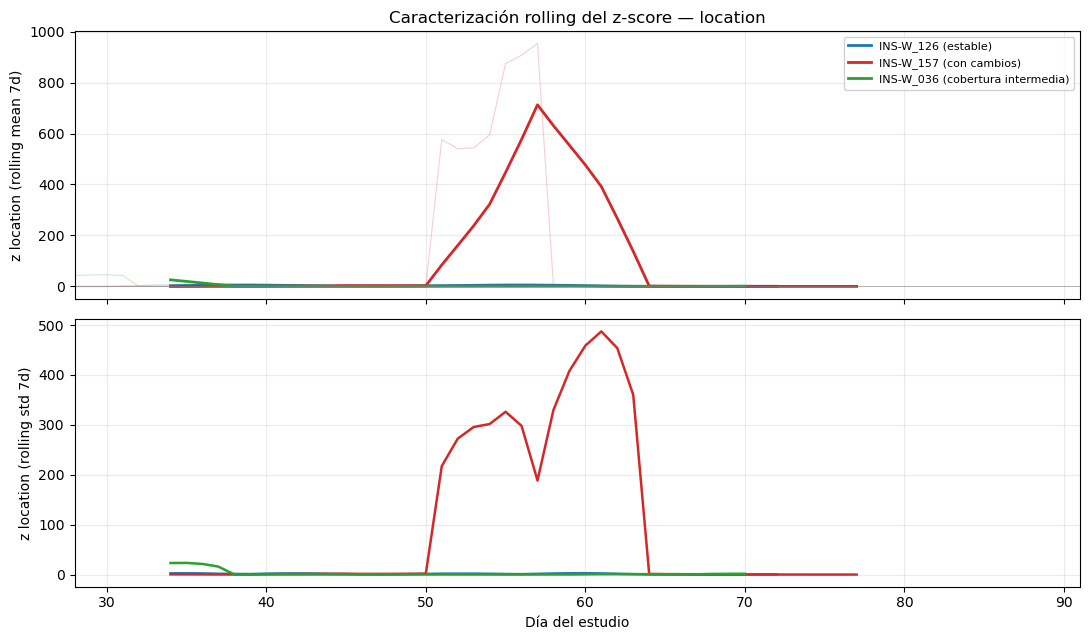

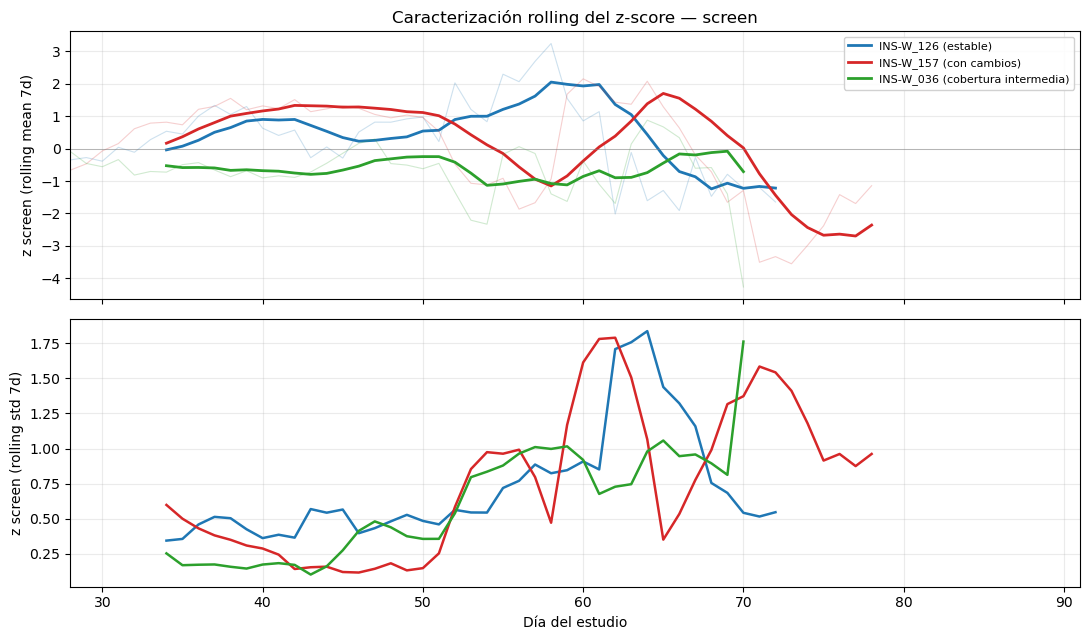

In [75]:
W_ROLL = 7

# Rolling mean y rolling std del z-score por participante, dimensión a dimensión
df_z_roll_mean = df_z.groupby(level="pid").transform(
    lambda s: s.rolling(window=W_ROLL, min_periods=W_ROLL).mean()
)
df_z_roll_std = df_z.groupby(level="pid").transform(
    lambda s: s.rolling(window=W_ROLL, min_periods=W_ROLL).std()
)

# Visualización: una figura por dimensión con rolling mean arriba y rolling std abajo
for dim in ["sleep", "steps", "location", "screen"]:
    fig, (ax_mean, ax_std) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    
    for perfil, pid in participantes_seleccionados.items():
        color = colores_por_perfil[perfil]
        # reset_index(drop=True) para que el eje X sea día dentro del estudio (0..91),
        # consistente con la celda 4.1 de inspección visual
        serie_z = df_z.loc[pid, dim].reset_index(drop=True)
        serie_mean = df_z_roll_mean.loc[pid, dim].reset_index(drop=True)
        serie_std = df_z_roll_std.loc[pid, dim].reset_index(drop=True)
        days = serie_z.index
        
        ax_mean.plot(days, serie_z, color=color, alpha=0.22, linewidth=0.8)
        ax_mean.plot(days, serie_mean, color=color, linewidth=2.0,
                     label=f"{pid} ({perfil})")
        ax_std.plot(days, serie_std, color=color, linewidth=1.8)
    
    ax_mean.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_mean.set_xlim(28, 91)
    ax_mean.set_ylabel(f"z {dim} (rolling mean 7d)")
    ax_std.set_ylabel(f"z {dim} (rolling std 7d)")
    ax_std.set_xlabel("Día del estudio")
    ax_mean.set_title(f"Caracterización rolling del z-score — {dim}")
    ax_mean.legend(loc="best", fontsize=8, framealpha=0.9)
    ax_mean.grid(True, alpha=0.25)
    ax_std.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Hallazgo central: la lectura conjunta de rolling mean y rolling std identifica el patrón conductual que el sistema final está diseñado para captar.**

En las cuatro dimensiones, el rolling mean suaviza el ruido diario del z-score y deja visible el nivel sostenido; el rolling std cuantifica la estabilidad de ese nivel en la misma ventana. Las dos métricas leídas conjuntamente distinguen oscilación habitual alrededor del baseline (mean cercano a cero, std en torno a 1) de desplazamiento sostenido con alteración simultánea de la variabilidad (mean alejado de cero durante varios días, std elevado o anormalmente bajo). Este segundo régimen es el que la regla operativa del proyecto (convergencia 2/3 con persistencia de siete días) está diseñada para detectar, y aparece como configuración recurrente en las figuras.

**Configuraciones individuales informativas.**

Sobre el patrón común se identifican cuatro lecturas conjuntas especialmente claras:

- *Sleep, INS-W_036:* caída del rolling mean a z≈-3.5 en los días 67-68 sincronizada con disparo del rolling std hasta ≈3.0, tras dos meses de sueño estable. Configuración nivel-bajo + variabilidad-alta característica del régimen que la regla 2/3 busca señalar.
- *Screen, INS-W_126 e INS-W_157:* descenso sostenido del rolling mean en la segunda mitad del rango (z≈-1.5 y z≈-2.5 al cierre, respectivamente) acompañado de elevación simultánea del rolling std (≈1.8 en ambos sobre los días 60-65). Réplica de la misma configuración en dos participantes distintos en la misma dimensión.
- *Steps, INS-W_126:* caída pronunciada del rolling mean a z≈-4 sobre los días 45-47, con pico de rolling std (≈2.3) sobre el día 50 seguido de un periodo prolongado de gran estabilidad (std≈0.4) durante la recuperación. Ilustra la utilidad del std para distinguir la semana del cambio del periodo de consolidación posterior.
- *Location, INS-W_157:* meseta sostenida del rolling mean (z≈+700) entre los días 50 y 64 con rolling std elevado (200-480) en la misma ventana. Caracteriza un cambio de régimen acotado en el tiempo, no un pico aislado, en una escala cuatro órdenes de magnitud por encima del resto de las figuras del bloque.

**Cierre del Bloque 4.**

Las lecturas realizadas en esta sección sobre los tres participantes seleccionados (rolling mean del z-score como nivel sostenido en ventana de siete días, rolling std del z-score como dispersión local en la misma ventana) ofrecen una caracterización operativa de la trayectoria intra-sujeto que la inspección del z-score diario no permitía. 

El rolling mean retira el ruido día a día y deja visible el nivel sostenido respecto al baseline. El rolling std cuantifica la estabilidad de ese nivel. Las cuatro dimensiones muestran que la lectura conjunta distingue oscilación habitual alrededor del baseline de desplazamiento sostenido con alteración simultánea de la variabilidad, y que el segundo régimen aparece localizado en el tiempo, no como deriva difusa.

Esta caracterización cierra el diagnóstico sobre las cuatro Series del z-score desde tres ángulos sucesivos. La inspección visual (sección 4.1) mostró que las trayectorias temporales son heterogéneas tanto entre dimensiones como entre participantes, y que ninguno de los tres perfiles exhibe desplazamientos sostenidos simultáneos en todas las dimensiones a la vez, lo que confirma que la convergencia entre dominios conductuales, y no la magnitud aislada en una sola dimensión, es la unidad de análisis correcta para el sistema. 

El análisis de autocorrelación (sección 4.3) produjo el hallazgo metodológico central del bloque: la autocorrelación observada en lags cortos del z-score es íntegramente subproducto del cálculo del baseline rolling, no señal conductual; el componente conductual neto a nivel poblacional es prácticamente cero, lo que implica que las features del próximo bloque 5 deben construirse sobre los valores sostenidos del z-score, que es precisamente lo que la regla de convergencia 2/3 con persistencia de siete días ya hace por construcción. 

La caracterización rolling (sección 4.4) validó que ese régimen de desplazamiento sostenido es distinguible del ruido habitual e identificó dos propiedades de la cohorte que condicionan el diseño operativo del Bloque 5: la escala estructuralmente más larga de la dimensión location y la heterogeneidad de la relación entre steps y location a nivel individual.

Las dos propiedades identificadas se trasladan al Bloque 5 como decisiones técnicas con respaldo empírico. La ventana de siete días utilizada coincide por construcción con la persistencia temporal que define la regla central del proyecto, de modo que los objetos producidos, **rolling mean** (df_z_roll_mean) y **rolling std** (df_z_roll_std) del z-score, son las variables primitivas operativas sobre los que el Bloque 5 construirá el sistema de detección. Con este diagnóstico queda cerrado el Bloque 4.

## Bloque 5: Feature engineering temporal

En el bloque 4 vimos el diagnóstico temporal de las cuatro `Series` del z-score y dejó establecidos los primitivos operativos sobre los que se construye el sistema: el nivel sostenido (rolling mean) y la dispersión local (rolling std) en ventana de siete días. El Bloque 5 traslada ese diagnóstico a la construcción de las variables que materializan, sobre cada participante y cada día evaluable, la definición operativa de deterioro establecida en el Bloque 0: desviación sostenida durante al menos siete días respecto al baseline individual, convergente en al menos dos de los tres pilares conductuales (sueño, activación, uso pasivo).

La pieza central del bloque es la variable de convergencia 2/3 con persistencia de siete días, que codifica directamente la definición operativa del proyecto. Se construye en capas sucesivas, cada una apoyada en la anterior. Sobre los rolling del z-score se calcula primero un indicador diario por dimensión que señala los días en que el participante se aleja del centro de su propio patrón. 

Sobre ese indicador diario se construye un indicador de persistencia que solo se activa cuando la desviación ha durado siete días consecutivos. A partir de los indicadores de persistencia de las cuatro dimensiones (sleep, steps, location, screen) se componen los tres dominios conductuales del marco, con un tratamiento específico del dominio activación, que combina dos dimensiones (steps y location) entre las que la heterogeneidad de la cohorte hace que cada participante aporte señal por una vía distinta. Sobre los tres dominios, se aplica finalmente la regla de convergencia 2/3.

Antes de calcular la primera capa, el bloque aplica dos decisiones técnicas derivadas del diagnóstico del Bloque 4. La primera afecta a la escala de la dimensión location: su rolling mean presenta una cola entre 6 y 7 veces más larga que las de las otras 3 dimensiones, de modo que un umbral único aplicado sin corrección haría que location o domine el sistema de forma sistemática o resulte irrelevante según el valor elegido. La solución que propongo iguala las escalas ajustando la distribución de location antes de construir los indicadores. 

La segunda afecta al dominio activación, que agrupa las dimensiones steps y location: el diagnóstico empírico mostró que ambas dimensiones no se mueven de forma redundante en más de la mitad de la cohorte, por lo que prescindir de una perdería señal real en una proporción significativa de los participantes; la solución adoptada combina las dos con una regla que activa el pilar si cualquiera de ellas supera el criterio de persistencia. 

Ambas decisiones tienen respaldo cuantificado en los datos de la cohorte y se aplican aquí como configuraciones de diseño fundamentadas. Su comportamiento en el sistema completo quedará evaluado en el Bloque 6, donde el modelado supervisado medirá el poder discriminativo de las features construidas, y en el Bloque 7, donde la evaluación de tasas de falsas alarmas y de anticipación de la señal cerrará el ciclo de validación del diseño.

### 5.1. Winsorización al p95 de location

El primer paso es ajustar la escala de location recortando su cola extrema y guardar el resultado en `df_z_roll_mean_w`, que será la base de trabajo para todo lo que sigue.

In [78]:
# Winsorización al p95 del |rolling mean| de location.
# Produce df_z_roll_mean_w: igual que df_z_roll_mean pero con location recortada.

umbral_location = df_z_roll_mean["location"].abs().quantile(0.95)

df_z_roll_mean_w = df_z_roll_mean.copy()
df_z_roll_mean_w["location"] = df_z_roll_mean_w["location"].clip(-umbral_location, umbral_location)

# Verificación: distribución del |rolling mean| tras la winsorización
print(f"Umbral aplicado (p95 del |rolling mean| de location): {umbral_location:.2f}")
print()
print("Distribución del |rolling mean| tras la winsorización:")
print(f"{'Dimensión':<10} {'mediana':>10} {'p90':>10} {'p95':>10} {'p99':>10} {'max':>10}")
print("-" * 60)
for dim in ["sleep", "steps", "location", "screen"]:
    vals = df_z_roll_mean_w[dim].dropna().abs()
    print(f"{dim:<10} {vals.median():>10.2f} {vals.quantile(0.90):>10.2f} {vals.quantile(0.95):>10.2f} {vals.quantile(0.99):>10.2f} {vals.max():>10.2f}")

n_recortados = (df_z_roll_mean["location"].abs() > umbral_location).sum()
n_total = df_z_roll_mean["location"].notna().sum()
print(f"\nValores recortados en location: {n_recortados} de {n_total} ({100*n_recortados/n_total:.1f}%)")

Umbral aplicado (p95 del |rolling mean| de location): 24.07

Distribución del |rolling mean| tras la winsorización:
Dimensión     mediana        p90        p95        p99        max
------------------------------------------------------------
sleep            0.94       3.03       4.41       7.87      41.41
steps            0.97       2.63       3.38       5.34      15.90
location         0.86       9.26      24.07      24.07      24.07
screen           0.94       2.61       3.40       5.26       8.41

Valores recortados en location: 283 de 5644 (5.0%)


In [ ]:
# Paso 1: calcular el umbral desde los datos 
valores_absolutos = []
for v in df_z_roll_mean["location"].values:
    if not np.isnan(v):
        valores_absolutos.append(abs(v))  # guardamos el valor sin signo

valores_absolutos.sort()
n_vals = len(valores_absolutos)
posicion_95 = int(n_vals * 0.95)          # la posición del percentil 95
umbral = valores_absolutos[posicion_95]
print("Umbral de recorte:", round(umbral, 2))


# Paso 2: copia del objeto original 
df_z_roll_mean_w = df_z_roll_mean.copy()


# Paso 3: recortar location valor por valor 
location = df_z_roll_mean_w["location"].values

for i in range(len(location)):
    if np.isnan(location[i]):
        pass                          # sin dato: no tocamos nada
    elif location[i] > umbral:
        location[i] = umbral          # demasiado alto: lo bajamos al umbral
    elif location[i] < -umbral:
        location[i] = -umbral         # demasiado bajo: lo subimos al -umbral

df_z_roll_mean_w["location"] = location


# Verificación
n_recortados = 0
n_total = 0
for v in df_z_roll_mean["location"].values:
    if not np.isnan(v):
        n_total += 1
        if v > umbral or v < -umbral:
            n_recortados += 1

print("Valores recortados:", n_recortados, "de", n_total)
print()

print("Distribución del |rolling mean| tras la winsorización:")
print(f"{'Dimensión':<10} {'mediana':>10} {'p90':>10} {'p95':>10} {'p99':>10} {'max':>10}")
print("-" * 60)

for dim in ["sleep", "steps", "location", "screen"]:
    vals = []
    for v in df_z_roll_mean_w[dim].values:
        if not np.isnan(v):
            vals.append(abs(v))
    vals.sort()
    n = len(vals)

    mediana = vals[n // 2]
    p90     = vals[int(n * 0.90)]
    p95     = vals[int(n * 0.95)]
    p99     = vals[int(n * 0.99)]
    maximo  = vals[-1]

    print(f"{dim:<10} {mediana:>10.2f} {p90:>10.2f} {p95:>10.2f} {p99:>10.2f} {maximo:>10.2f}")
    

Umbral de recorte: 24.07
Valores recortados: 282 de 5644

Distribución del |rolling mean| tras la winsorización:
Dimensión     mediana        p90        p95        p99        max
------------------------------------------------------------
sleep            0.94       3.03       4.41       8.00      41.41
steps            0.97       2.63       3.38       5.35      15.90
location         0.86       9.27      24.07      24.07      24.07
screen           0.94       2.61       3.40       5.26       8.41


Los resultados confirman que la winsorización se ha aplicado correctamente en todos sus aspectos. El umbral calculado (24.07) reproduce exactamente el valor obtenido en el diagnóstico del Bloque 4, lo que confirma que el objeto `df_z_roll_mean` está en el mismo estado que cuando se realizó ese diagnóstico y que el procedimiento es reproducible.

Las tres dimensiones no afectadas (sleep, steps, screen) muestran distribuciones idénticas a las del diagnóstico previo: el recorte fue quirúrgico y no introdujo ninguna alteración fuera de location.

Para location, la parte central de la distribución permanece intacta: la mediana (0.86) y el percentil 90 (9.26) son iguales que antes del recorte. El cambio se concentra en la cola: el percentil 95, el percentil 99 y el máximo quedan todos en 24.07, lo que significa que todos los valores que anteriormente estaban entre el percentil 95 y el máximo anterior (1004.01) han sido sustituidos por el umbral. El máximo de la distribución ha pasado de 1004 a 24, sin que ningún registro haya sido eliminado.

El recuento de valores recortados (283 de 5644, 5.0%) confirma que la operación se ha aplicado exactamente sobre el segmento esperado: por construcción estadística, el percentil 95 deja el 5% de los valores por encima de él, y ese 5% es precisamente lo que ha sido recortado. Los episodios de movilidad extrema no han desaparecido del análisis: siguen siendo los valores más altos de la distribución de location para cada participante afectado, simplemente han dejado de estar a una escala incomparable con el resto de las dimensiones.

### 5.2. Indicadores diarios por dimensión (piso 1).

### 5.3. Indicadores de persistencia 7d (piso 2)

### 5.4. Composición de pilares (piso 3, con el OR de activación)

### 5.5. Convergencia 2/3 (piso 4)

### 5.6. Validación empírica de la regla 2/3 con BDI-II